Цель: Провести полный цикл разведывательного анализа временного ряда, определить его природу, преобразовать в облако точек методами равномерного и неравномерного вложения, и выявить скрытые паттерны с помощью TDA и кластеризации.

### Задания

1. Разведывательный анализ (EDA) и предобработка

- Проверьте данные на пропуски. Обоснуйте метод их заполнения (LOCF, интерполяция и т.д.), учитывая риск упреждения (look-ahead bias).
    
- Постройте графики временного ряда, опишите визуально наблюдаемые особенности.
    

2. Определение природы порождающего процесса

- Вычислите показатель Ляпунова.
    
- Вычислите показатель Хёрста (R/S-анализ).
    
- Опираясь на полученные значения, сделайте обоснованный вывод о природе порождающих процессов.
    

3. Вложение временного ряда  
На основе выводов из п.2 преобразуйте одномерный временной ряд в многомерное облако точек.

- Равномерное вложение (Uniform Embedding):
    

- Определите оптимальные временную задержку и размерность вложения.
    

- Неравномерное вложение (Non-uniform Embedding):
    

- Определите оптимальные различные (неравномерные) шаги задержки (размерность определяется одновременно).
    

- Анализ: Визуализируйте полученные облака точек (в 2D или 3D проекциях, например, через PCA/UMAP). Сравните структуру аттракторов, полученных равномерным и неравномерным методами.
    

4. Топологический анализ (TDA) и выявление скрытых режимов  
Поскольку данные неразмеченные, задача сводится к поиску скрытых режимов (например, смена режимы работы оборудования).

- Примените метод персистентных гомологий (постройте симплициальные комплексы) к полученным на шаге 3 облакам точек.
    
- Постройте диаграммы персистентности.
    
- Векторизуйте диаграммы.
    

- Ландшафты персистентности (Persistence Landscapes).
    
- Образы персистентности (Persistence Images).
    
- Кривые Бетти (Betti Curves).
    
- Кривые Эйлера.
    
- Характеристики диаграмм персистентности и/или их векторизаций.
    

- Примените алгоритмы кластеризации к полученным топологическим признакам.
    
- Интерпретация: Сопоставьте найденные кластеры с исходным временным рядом (раскрасьте график временного ряда цветами кластеров). Объясните, какие режимы смогла найти топология.

## Загрузка данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet('./Lab5_Разрушение подшипника КНД КС-5 ГПА 14.parquet')

In [3]:
df

,row,TS,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,...,Lab5_AVOM_AVOMN1,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_6,Lab5_U_Kran_GPA_A_APK,Lab5_Kran_1,Lab5_Kran_4,Lab5_q
0,1,2021-01-04 17:00:00+00:00,9258,11923,4948,15.43,706.0,-3.7,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
1,2,2021-01-04 17:00:00+00:00,9258,11923,4948,15.43,706.0,-3.7,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
2,3,2021-01-04 17:00:59.999999+00:00,9256,11927,4943,15.41,706.6,-3.5,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
3,4,2021-01-04 17:00:59.999999+00:00,9256,11927,4943,15.41,706.6,-3.5,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
4,5,2021-01-04 17:01:59.999999+00:00,9256,11924,4960,15.45,706.1,-3.7,41.0,79.44,...,1,0.89,0.26,0,1,0,0,1,0,48.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2575,2576,2021-01-05 14:26:59.999999+00:00,0,0,0,0.14,280.7,-1.3,40.7,81.20,...,1,0.00,0.00,1,0,0,0,0,0,0.0
2576,2577,2021-01-05 14:28:00+00:00,0,0,0,0.13,310.9,-0.9,40.5,79.64,...,1,0.00,0.00,1,0,0,0,0,0,0.0
2577,2578,2021-01-05 14:28:00+00:00,0,0,0,0.13,310.9,-0.9,40.5,79.64,...,1,0.00,0.00,1,0,0,0,0,0,0.0
2578,2579,2021-01-05 14:28:01+00:00,0,0,0,0.13,310.9,-0.9,40.5,79.64,...,1,0.00,0.00,1,0,0,0,0,0,0.0


In [4]:
df.isna().sum().sum()

0

In [5]:
print(df.describe())

               row   Lab5_G1_N1    Lab5_G1_N2  Lab5_G1_N3   Lab5_G1_P2  \
count  2580.000000  2580.000000   2580.000000  2580.00000  2580.000000   
mean   1290.500000  9194.368992  11856.313178  4924.43876    15.300822   
std     744.926171   632.133361    788.408208   336.67001     1.054558   
min       1.000000     0.000000      0.000000     0.00000     0.130000   
25%     645.750000  9235.000000  11905.000000  4948.00000    15.380000   
50%    1290.500000  9244.000000  11913.000000  4952.00000    15.390000   
75%    1935.250000  9255.000000  11924.000000  4955.00000    15.410000   
max    2580.000000  9272.000000  11952.000000  4963.00000    15.460000   

       Lab5_G1_T4ср  Lab5_G1_T1  Lab5_G1_T607  Lab5_G1_T600  Lab5_G1_T638  \
count   2580.000000  2580.00000   2580.000000   2580.000000   2580.000000   
mean     703.393721    -3.68186     41.091318     79.314829     86.565891   
std       30.400840     0.59716      0.148046      0.527497      1.973936   
min      225.000000    -4

In [ ]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print(f"Колонки с одним уникальным значением: {constant_cols}")

# Удаляем
df_cleaned = df.drop(columns=constant_cols)

Колонки с одним уникальным значением: ['Lab5_G2_Fнш', 'Lab5_G2_Fма', 'Lab5_G2_Fмн', 'Lab5_G2_Fств', 'Lab5_G3_Коксование', 'Lab5_G3_Маслосистема', 'Lab5_Lmp_Txt_AO', 'Lab5_Lmp_Txt_BEAO', 'Lab5_Lmp_Txt_BK1', 'Lab5_Lmp_Txt_BK2', 'Lab5_TC_VKPGV', 'Lab5_TC_VPOS', 'Lab5_Tpg', 'Lab5_Kran_11', 'Lab5_Kran_10', 'Lab5_Kran_PZS', 'Lab5_VOD1', 'Lab5_VOD2', 'Lab5_AVOM_AVOMD1', 'Lab5_AVOM_AVOMN1', 'Lab5_Kran_6', 'Lab5_U_Kran_GPA_A_APK', 'Lab5_Kran_4']


In [4]:
df_cleaned.describe()

,row,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,Lab5_G1_T638,...,Lab5_Kran_12,Lab5_Kran_9,Lab5_U_Kran_GPA_A_OGK,Lab5_Kran_SK,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_1,Lab5_q
count,2580.000000,2580.000000,2580.000000,2580.00000,2580.000000,2580.000000,2580.00000,2580.000000,2580.000000,2580.000000,...,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000
mean,1290.500000,9194.368992,11856.313178,4924.43876,15.300822,703.393721,-3.68186,41.091318,79.314829,86.565891,...,0.995349,0.004651,0.995349,0.995349,0.885171,0.258589,0.004651,0.995349,0.995349,48.634651
std,744.926171,632.133361,788.408208,336.67001,1.054558,30.400840,0.59716,0.148046,0.527497,1.973936,...,0.068054,0.068054,0.068054,0.068054,0.065395,0.019104,0.068054,0.068054,0.068054,3.593070
min,1.000000,0.000000,0.000000,0.00000,0.130000,225.000000,-4.40000,40.500000,74.460000,66.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,645.750000,9235.000000,11905.000000,4948.00000,15.380000,704.100000,-4.20000,40.900000,79.230000,86.600000,...,1.000000,0.000000,1.000000,1.000000,0.890000,0.260000,0.000000,1.000000,1.000000,48.900000
50%,1290.500000,9244.000000,11913.000000,4952.00000,15.390000,705.300000,-3.90000,41.200000,79.330000,86.800000,...,1.000000,0.000000,1.000000,1.000000,0.890000,0.260000,0.000000,1.000000,1.000000,48.900000
75%,1935.250000,9255.000000,11924.000000,4955.00000,15.410000,707.700000,-3.40000,41.200000,79.540000,87.000000,...,1.000000,0.000000,1.000000,1.000000,0.890000,0.260000,0.000000,1.000000,1.000000,48.900000
max,2580.000000,9272.000000,11952.000000,4963.00000,15.460000,712.200000,-0.90000,41.500000,83.810000,88.600000,...,1.000000,1.000000,1.000000,1.000000,0.890000,0.260000,1.000000,1.000000,1.000000,48.900000


In [8]:
# df = df_cleaned

## Визуальный анализ и распределение значений по признакам

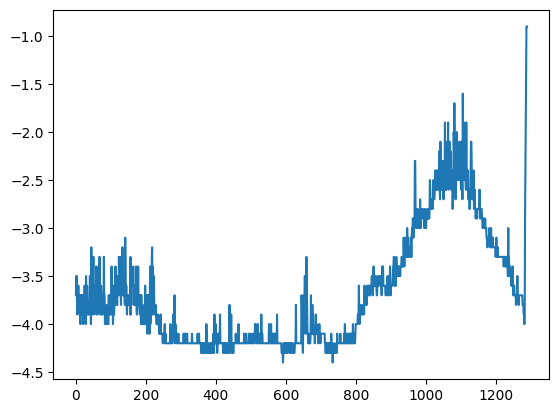

In [95]:
plt.plot(np.arange(len(df["Lab5_G1_T1"])), df["Lab5_G1_T1"])

In [10]:
len(np.unique(df["Lab5_G1_N1"]))

69

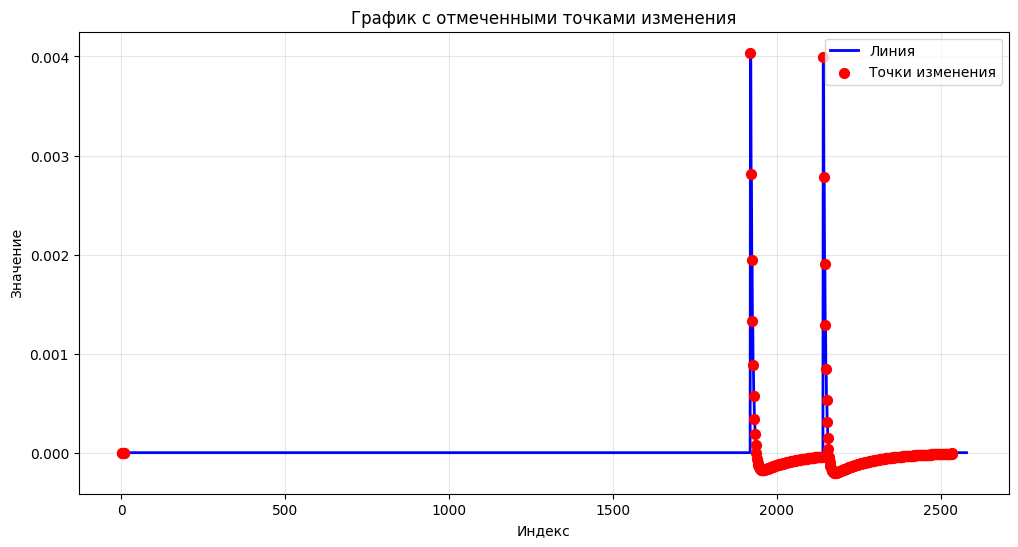

In [27]:
data = df["Lab5_G3_Lm"].values

# Находим индексы, где значение меняется
change_mask = np.diff(data) != 0
change_indices = np.where(change_mask)[0] + 1  # +1 потому что diff возвращает на 1 элемент меньше

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(data)), data, 'b-', linewidth=2, label='Линия')

# Добавляем точки изменений
plt.scatter(change_indices, data[change_indices], 
           color='red', s=50, zorder=5, label='Точки изменения', marker='o')

# Для наглядности можно также отметить точки, где происходит изменение, на предыдущем значении
# plt.scatter(change_indices - 1, data[change_indices - 1], 
#            color='orange', s=30, alpha=0.5, label='Перед изменением')

plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.title('График с отмеченными точками изменения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
len(df.columns)

119

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

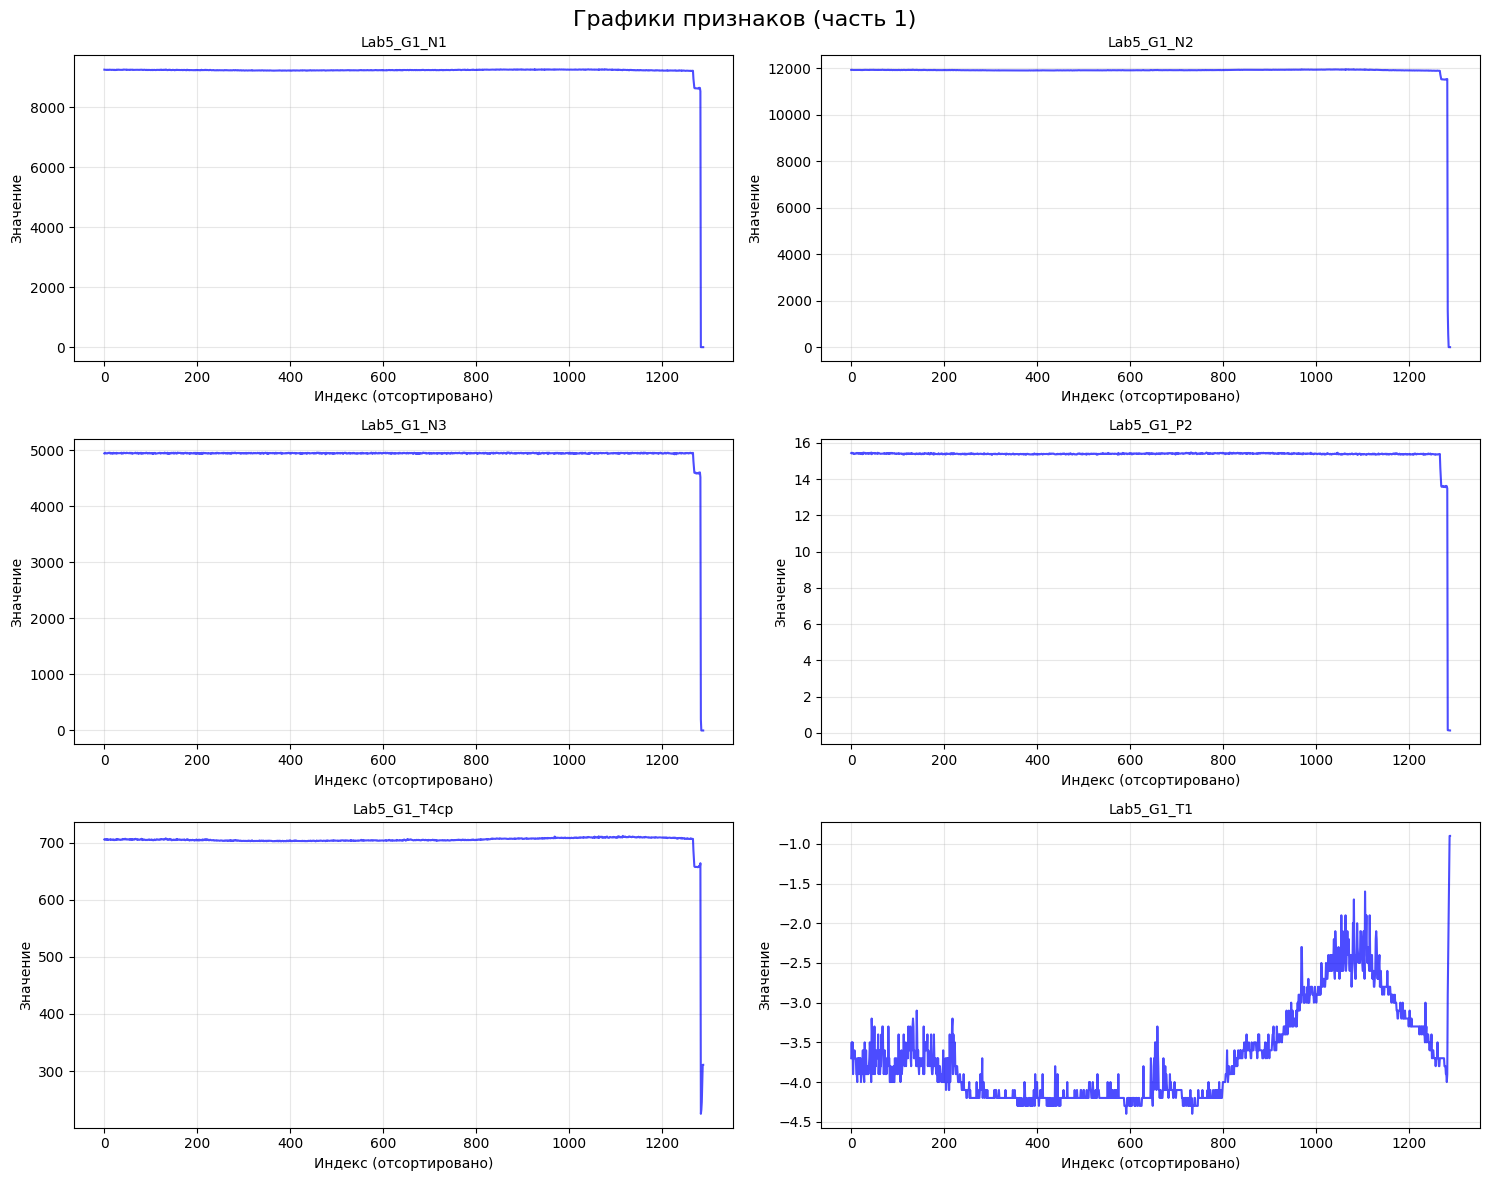

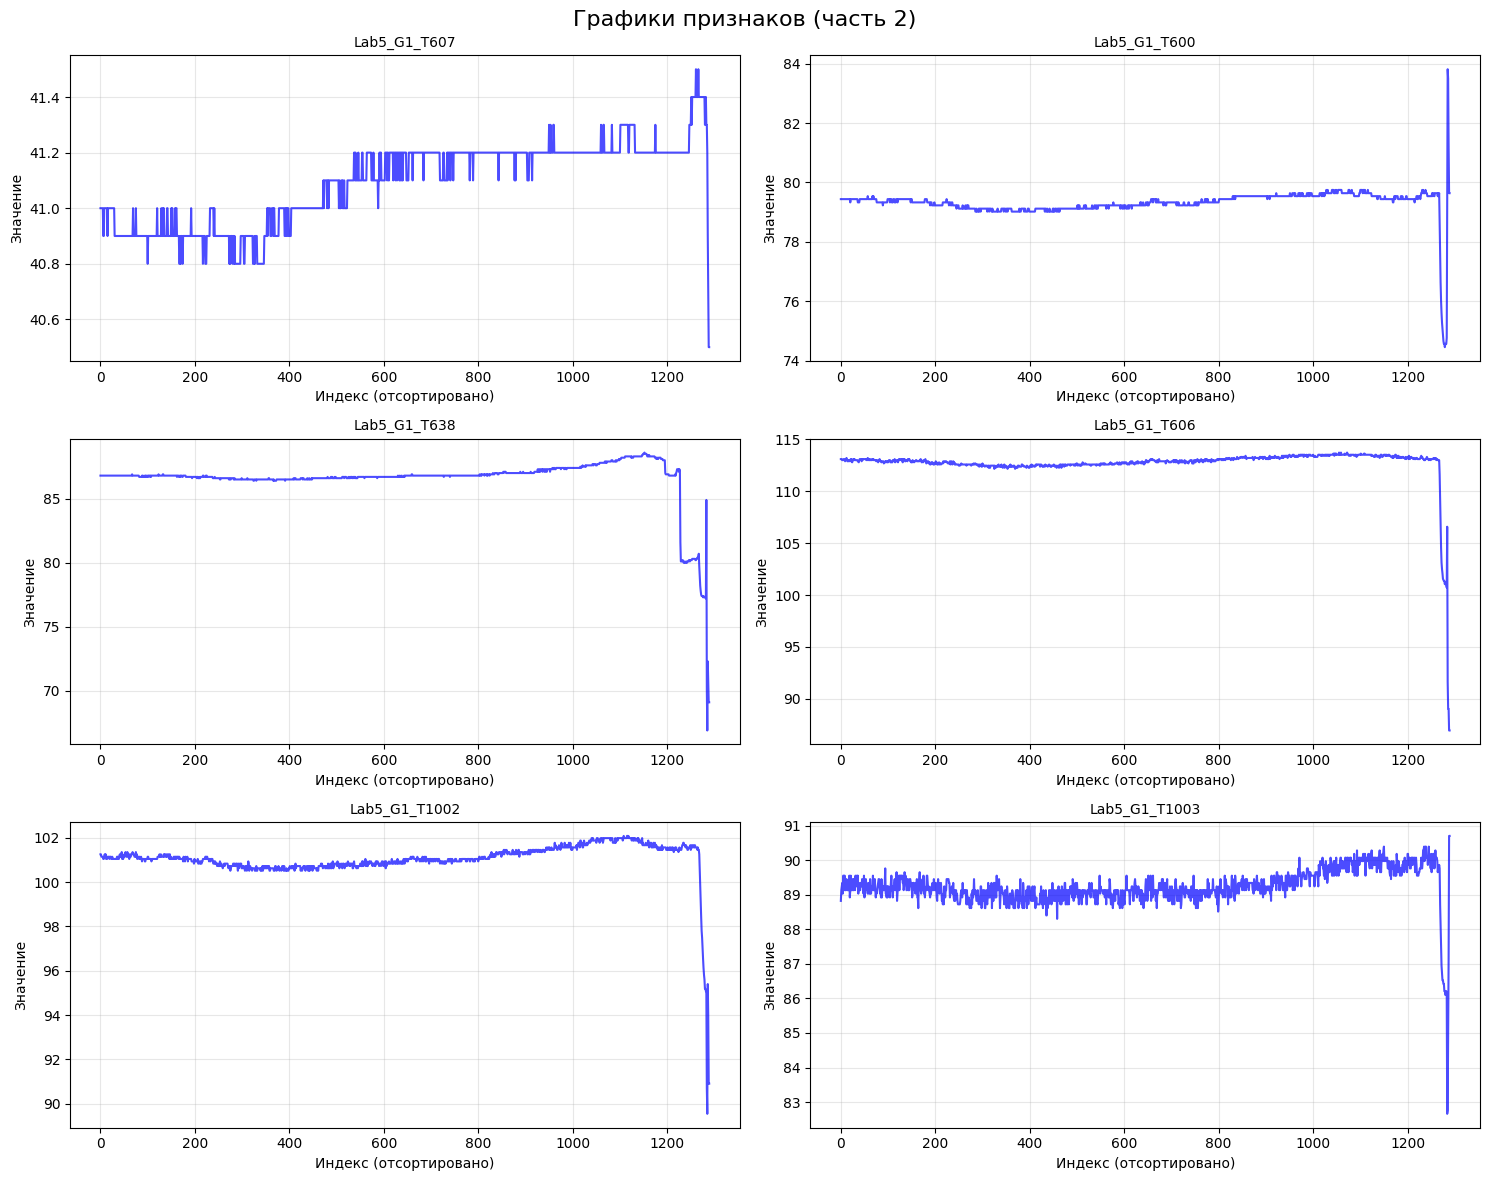

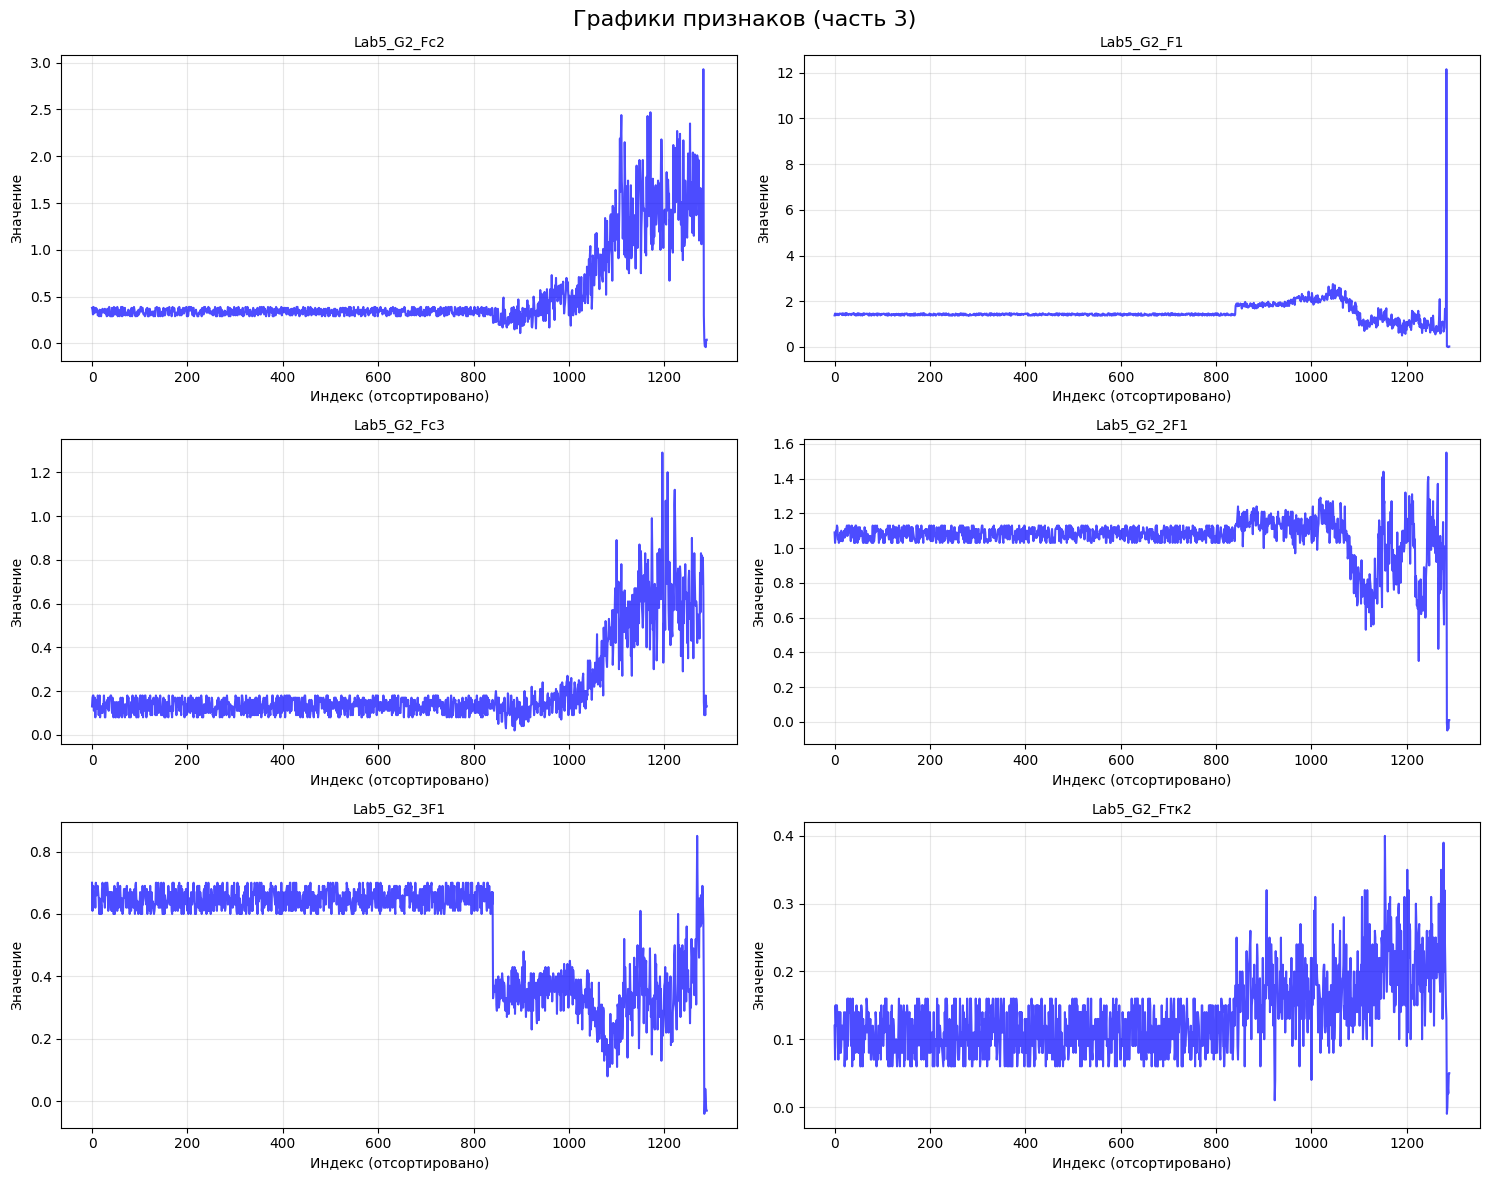

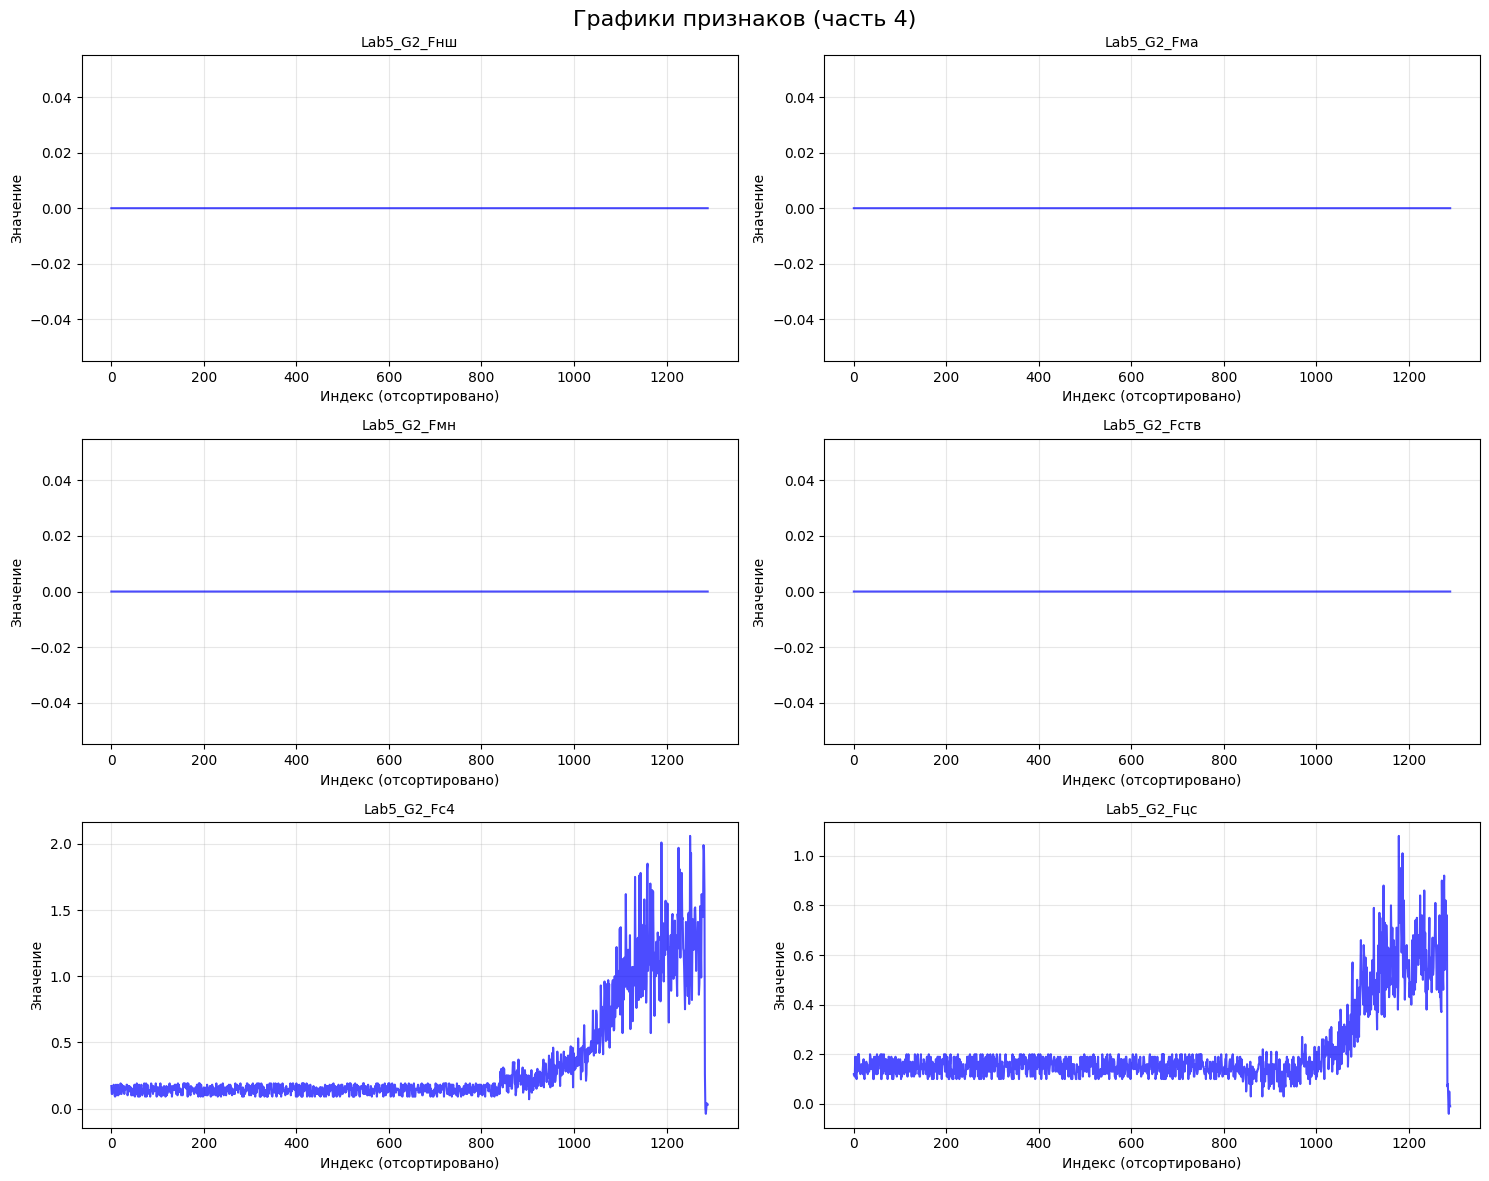

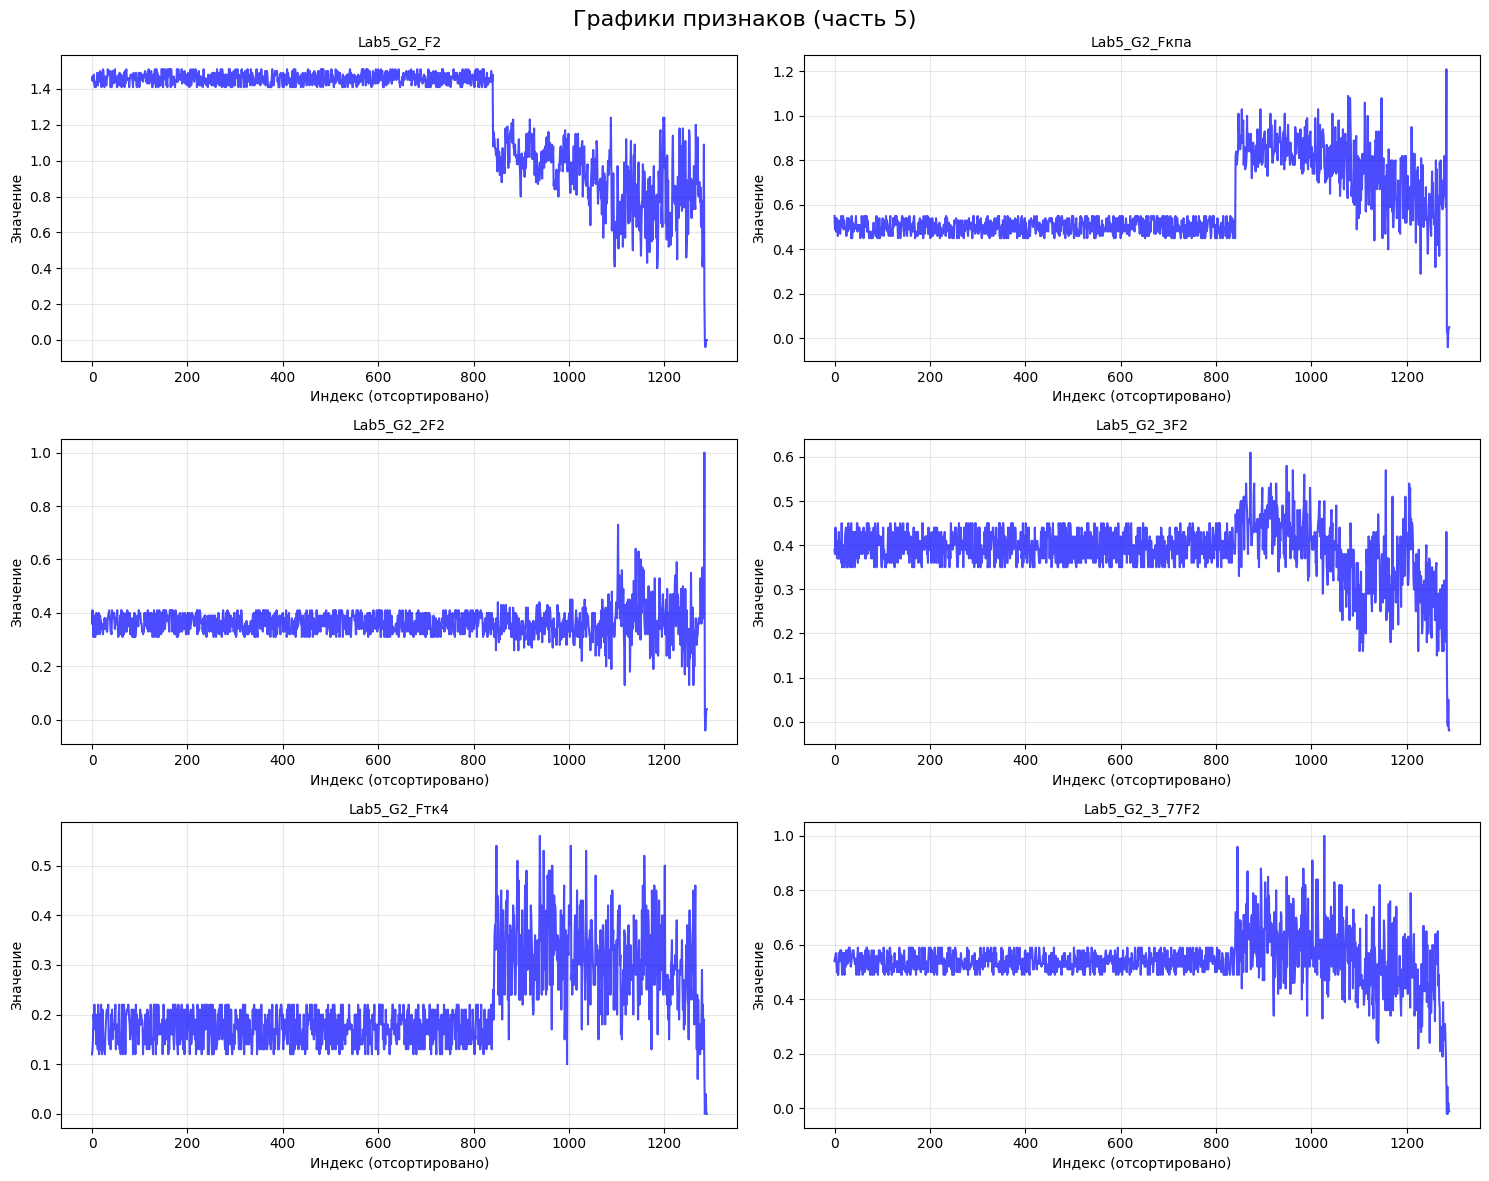

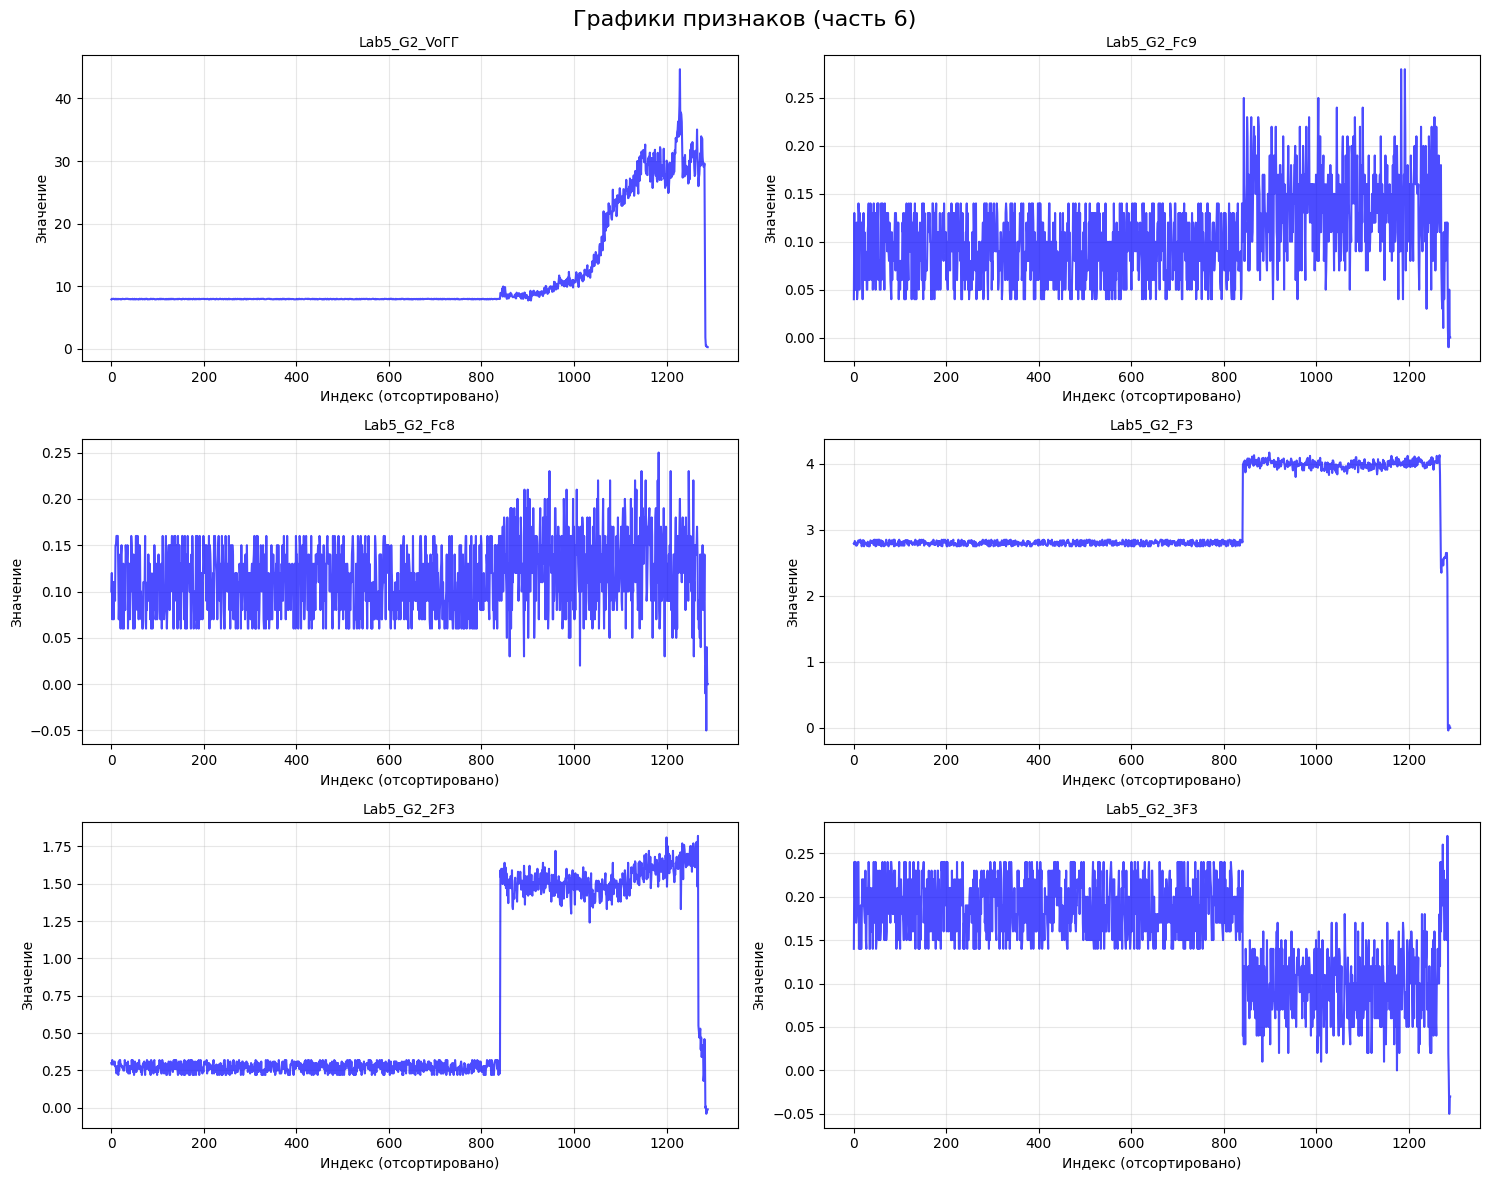

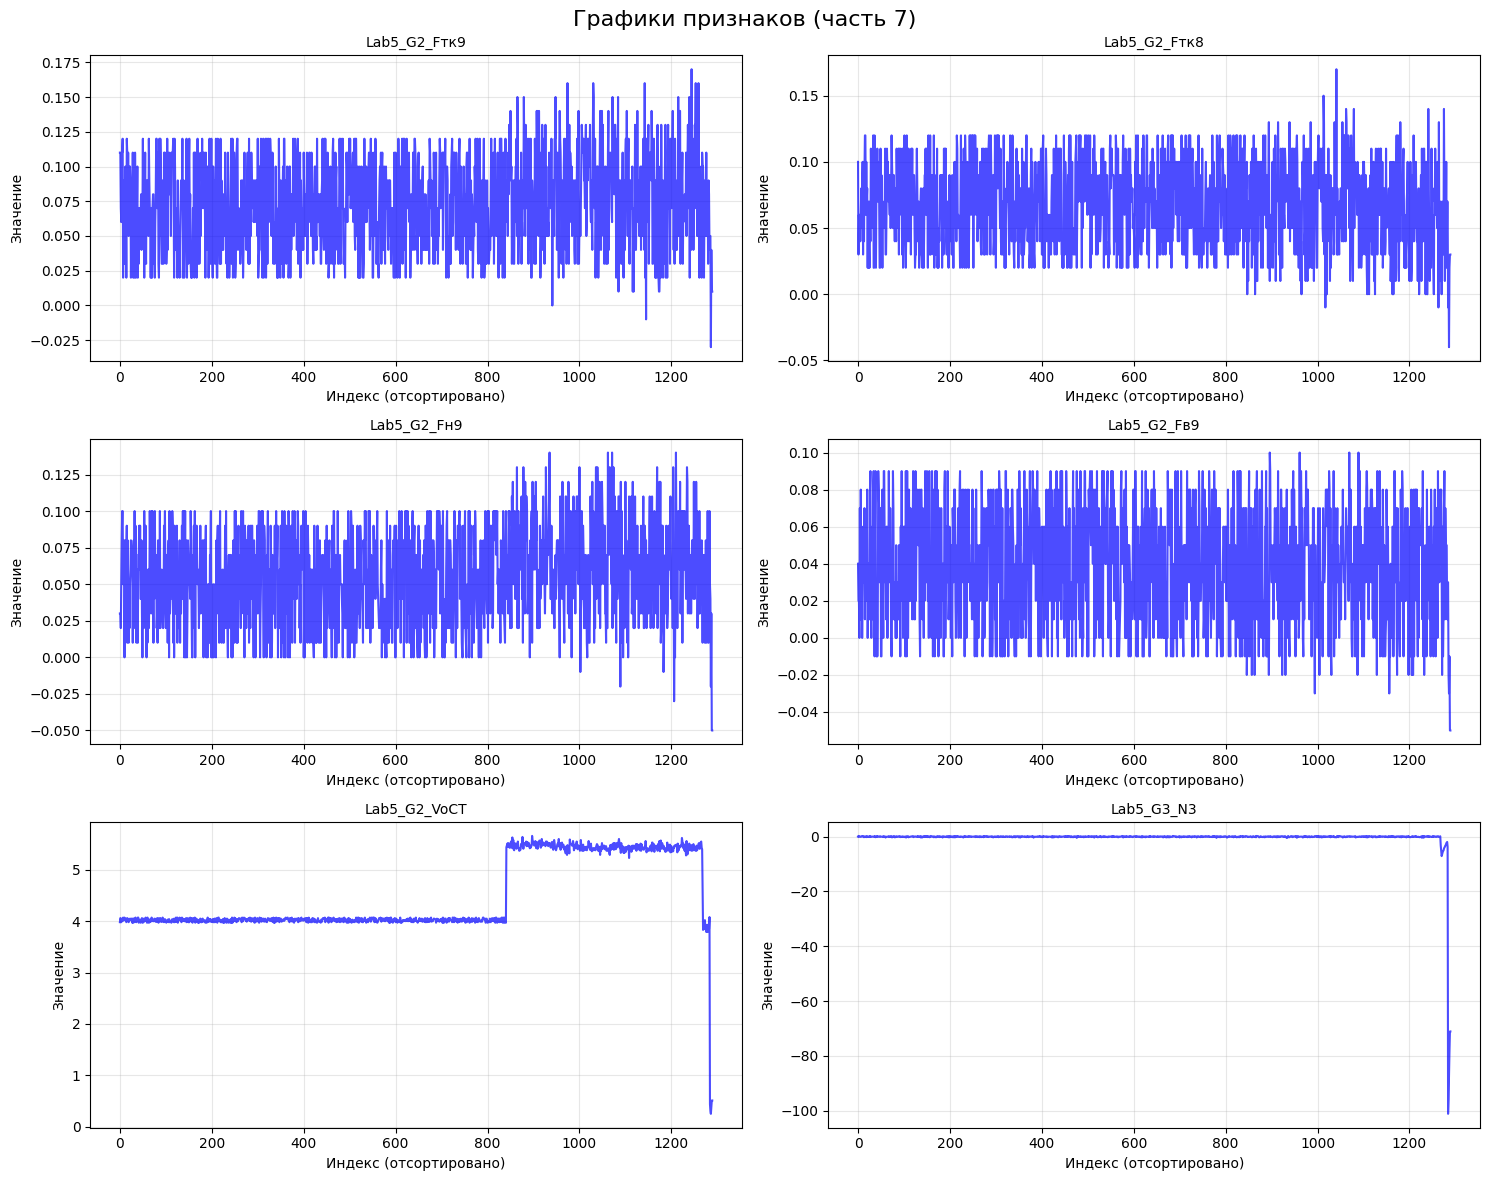

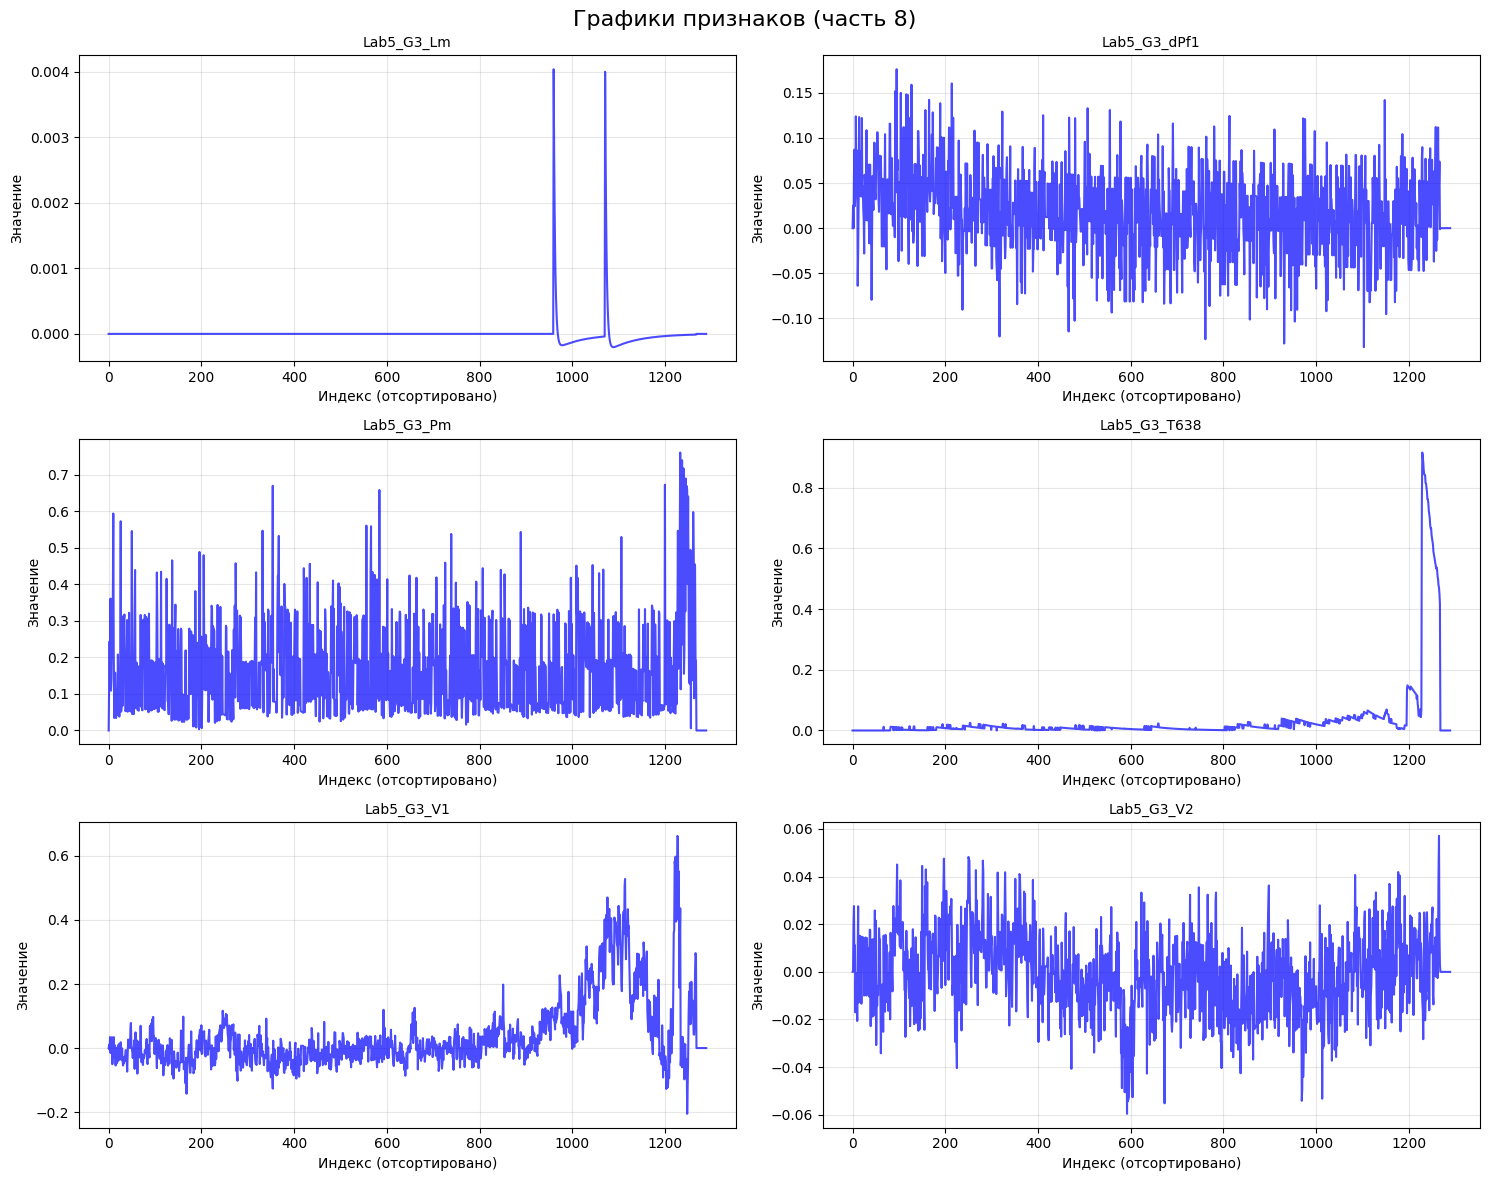

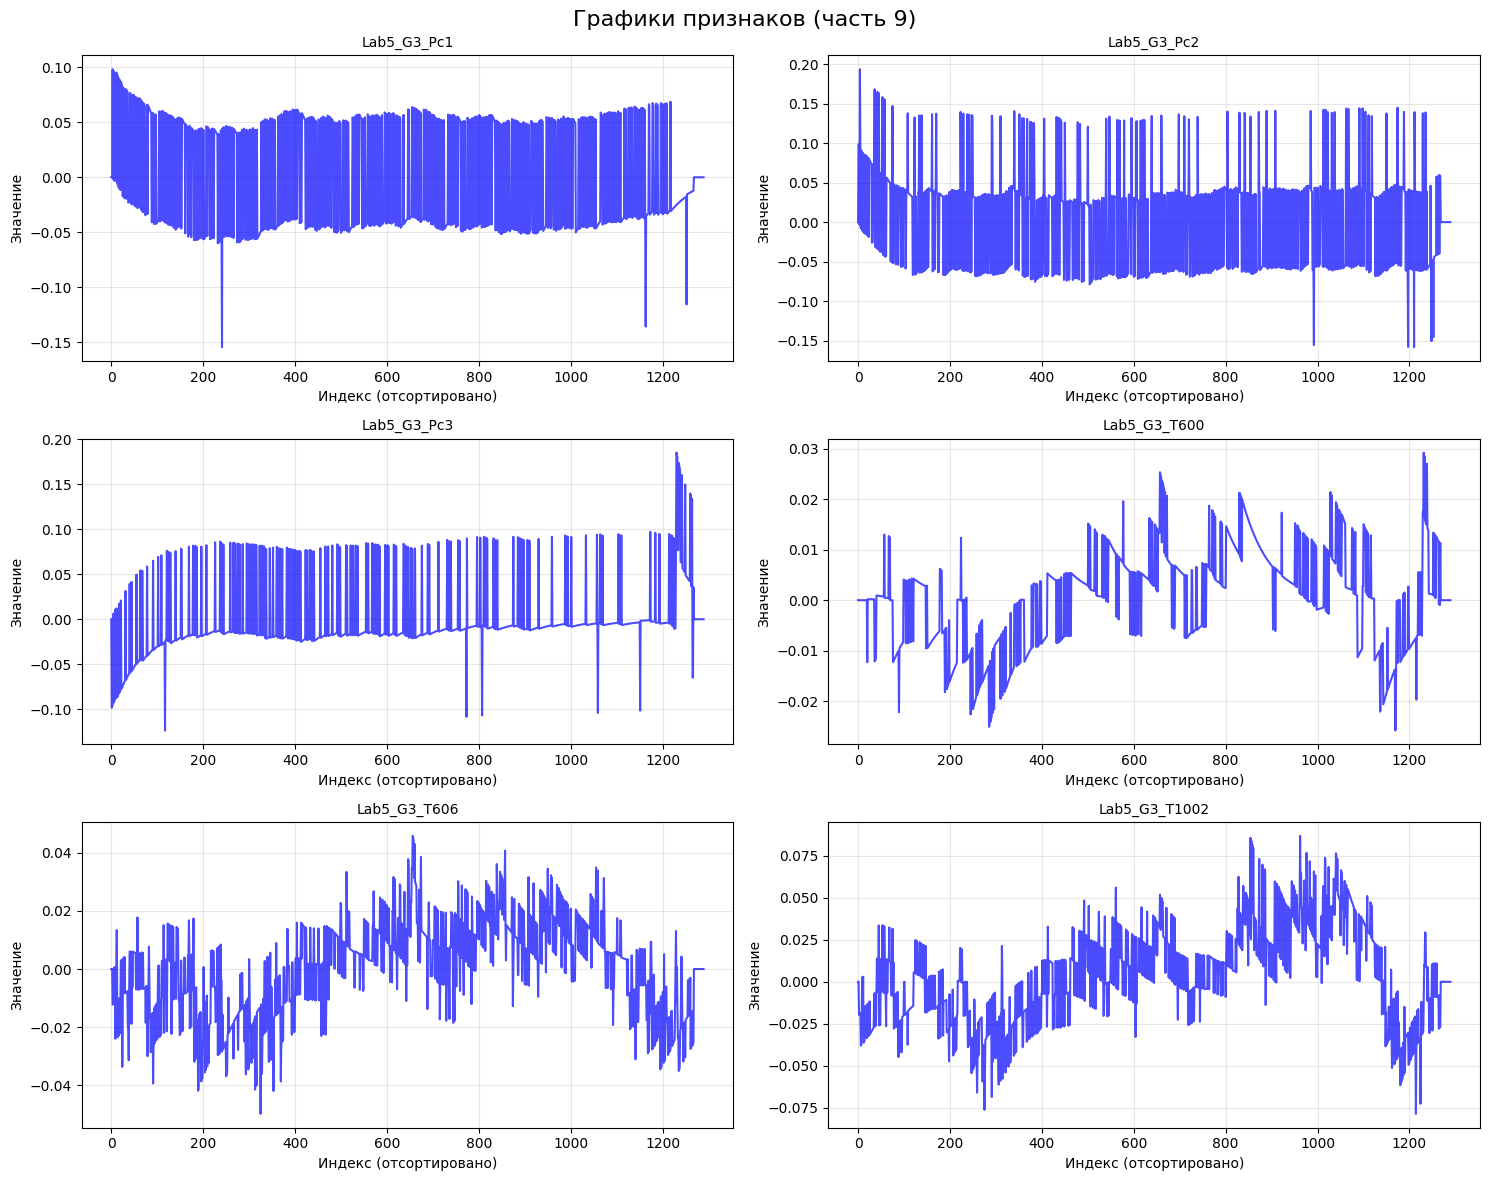

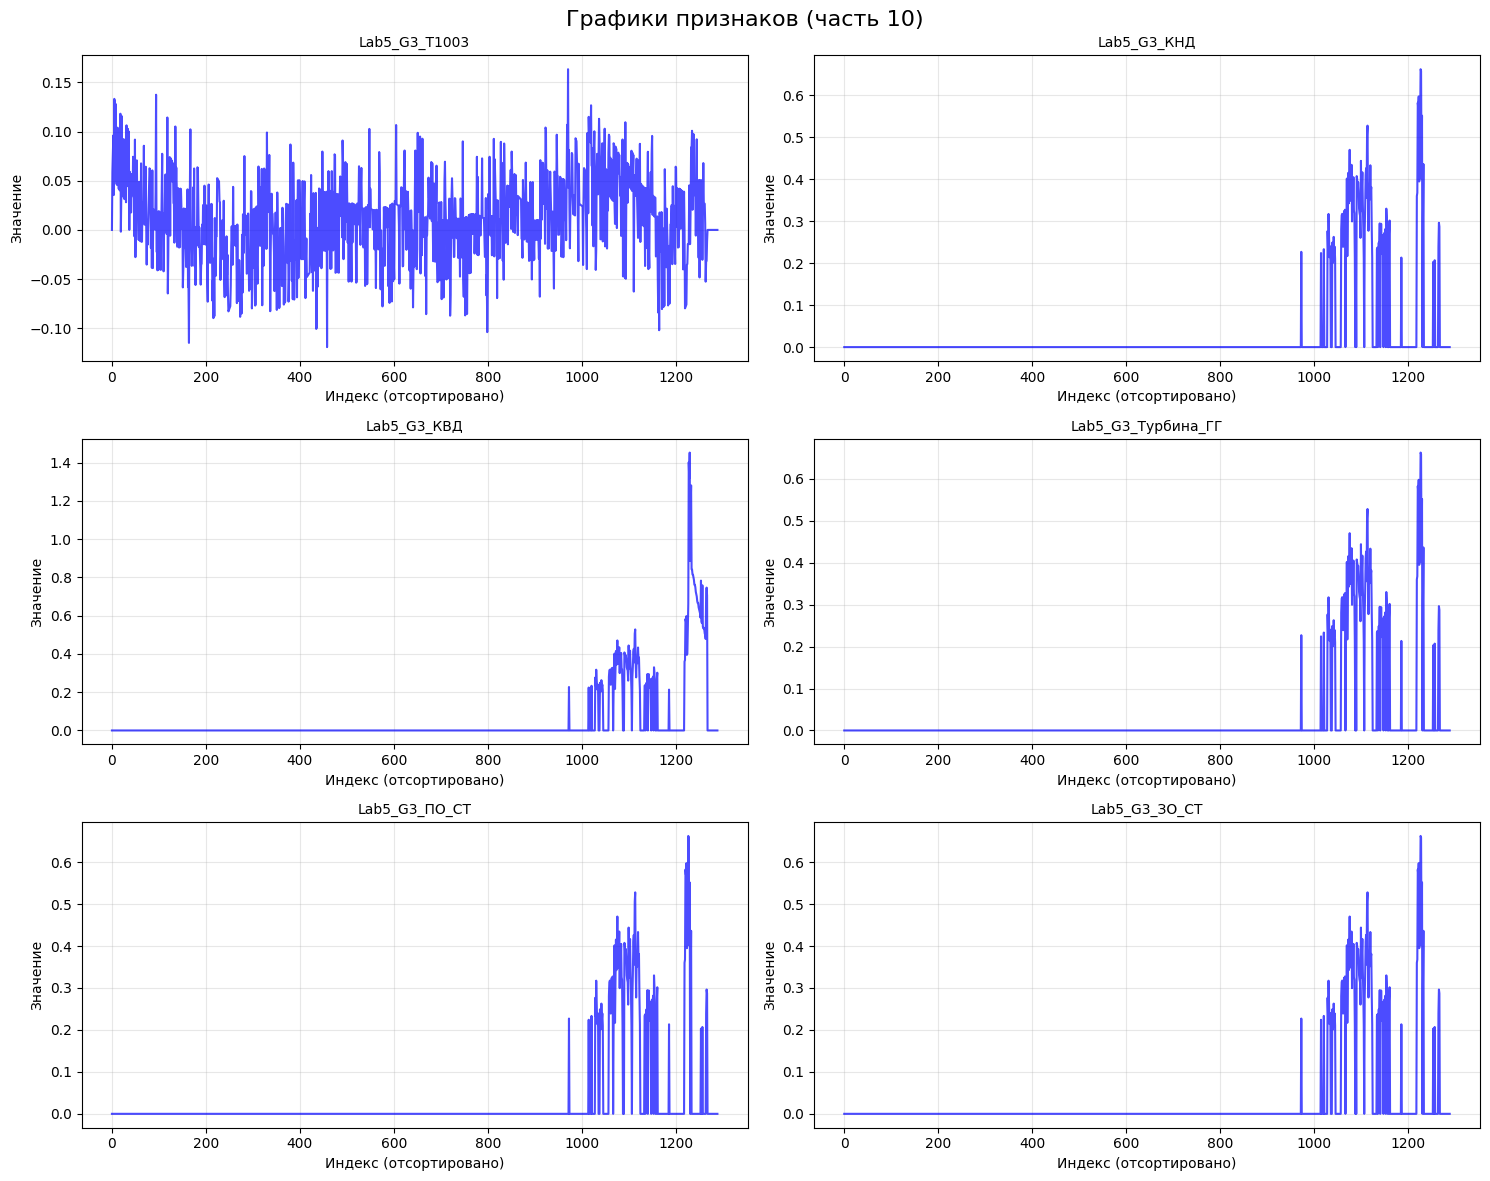

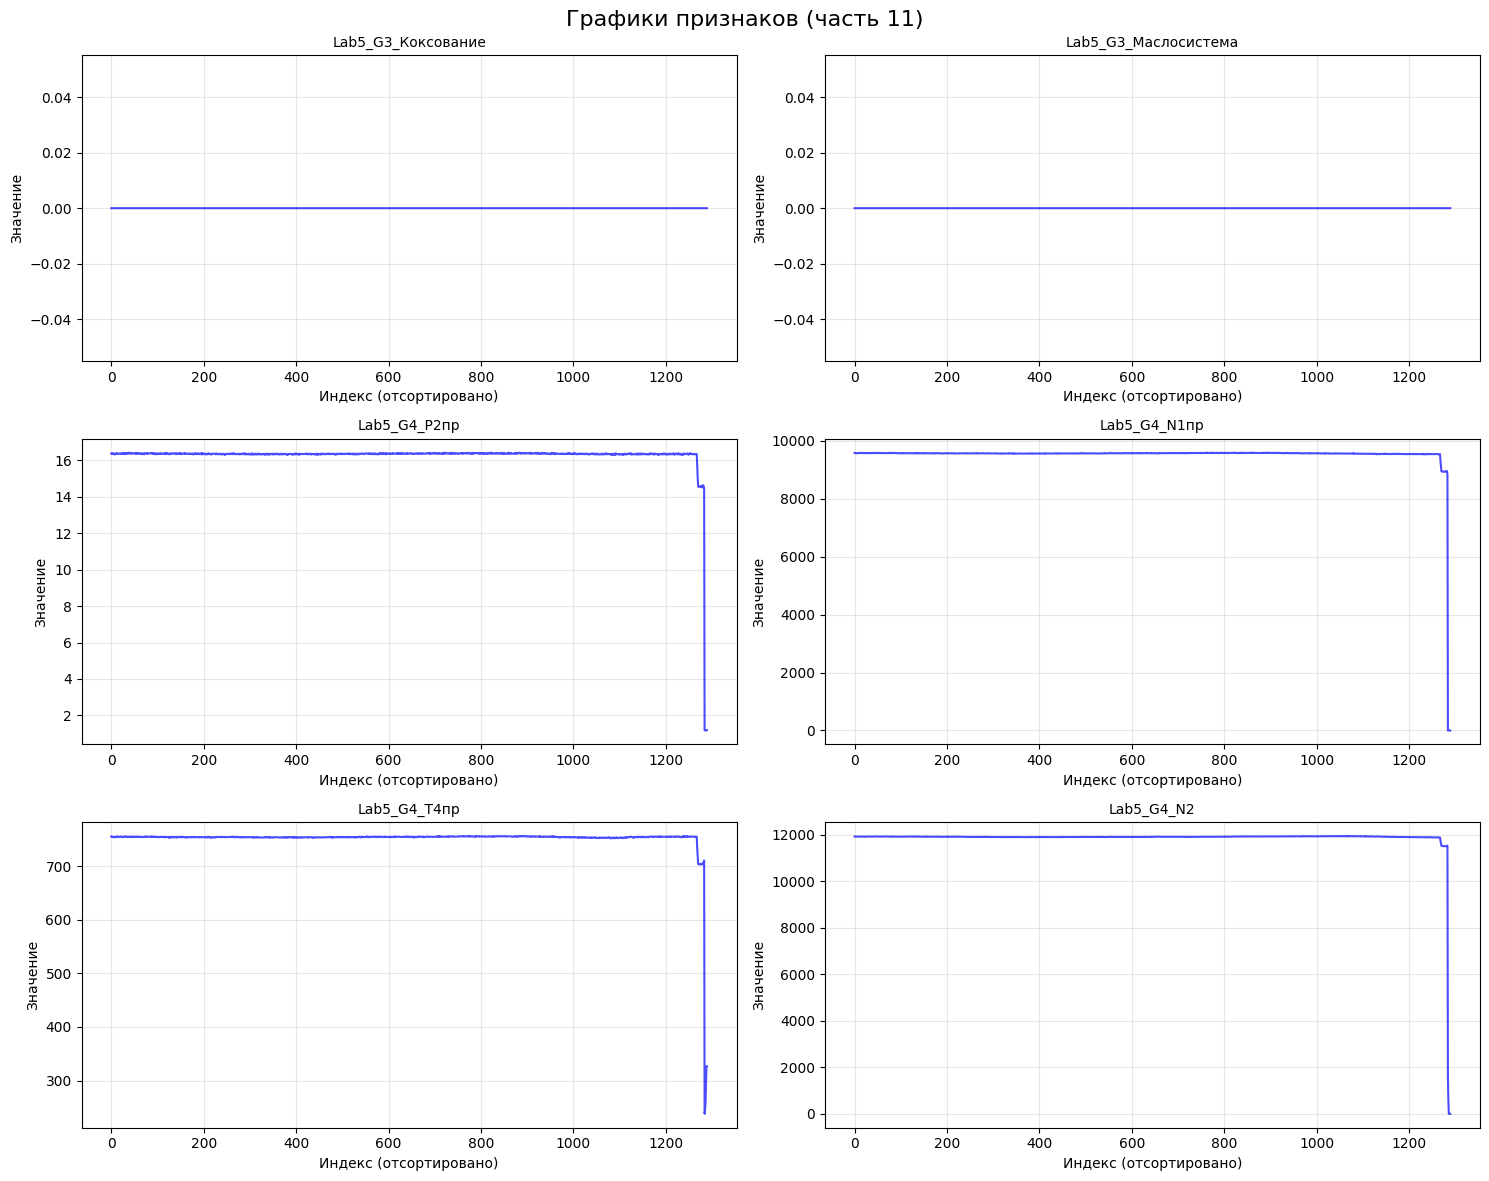

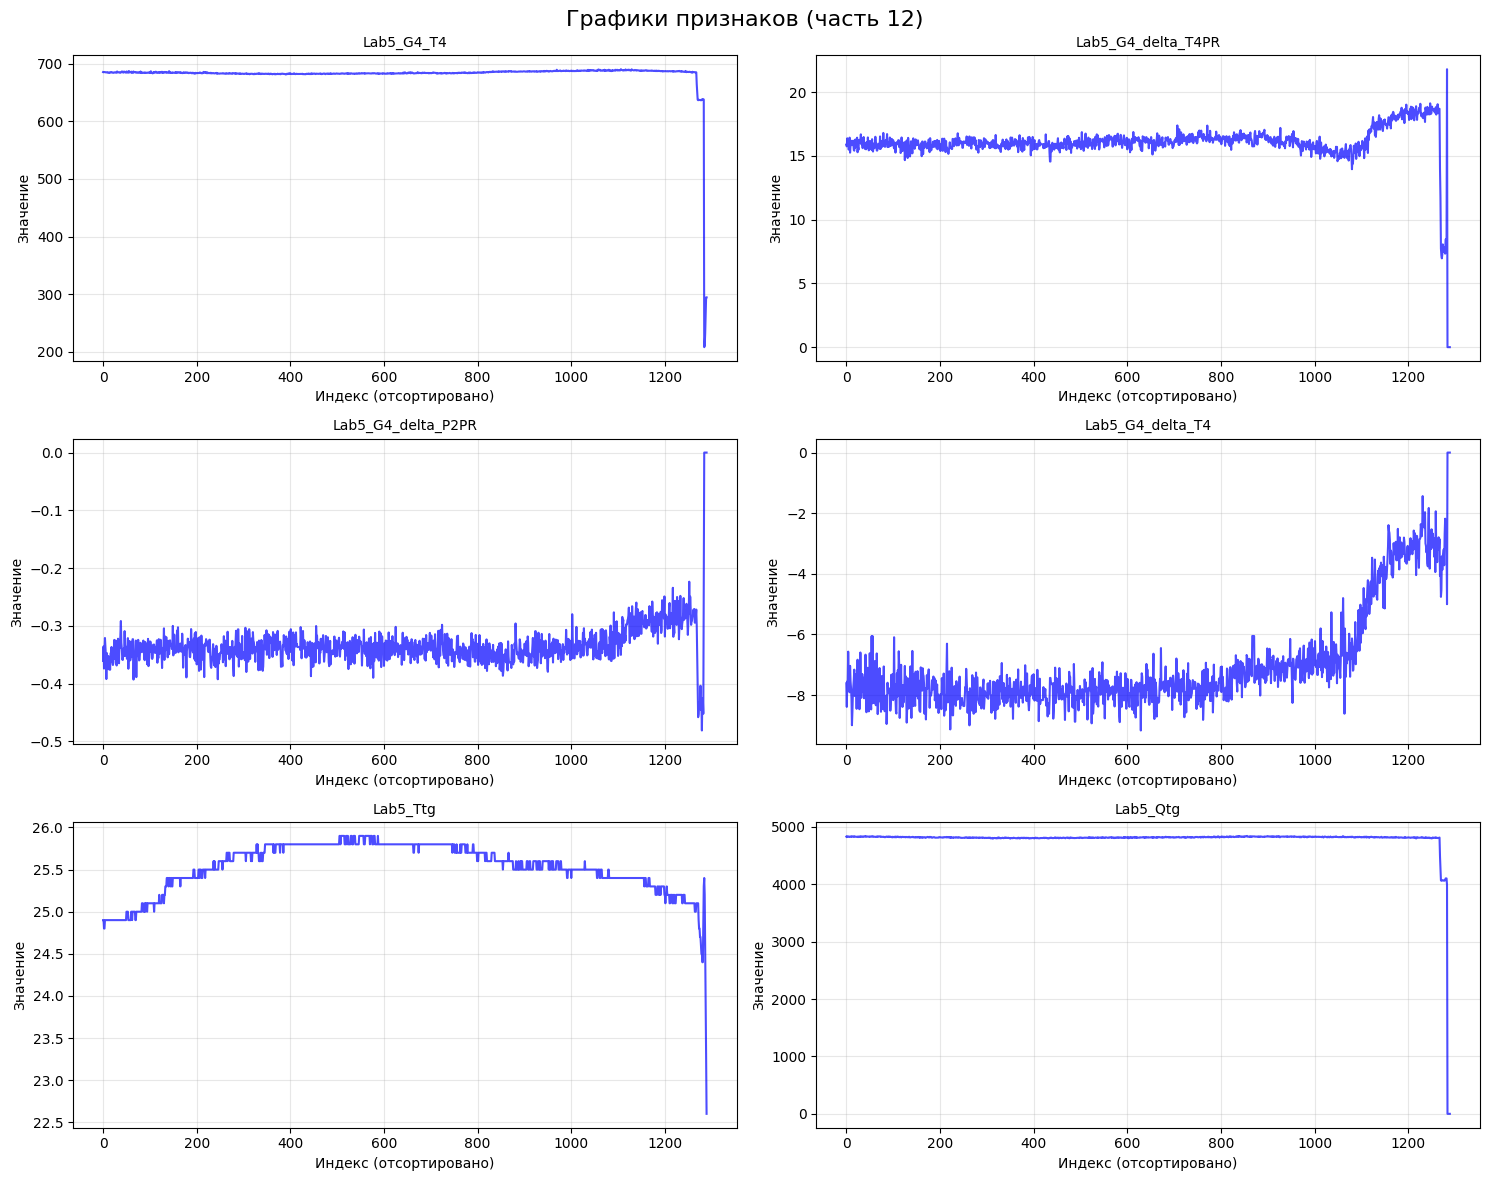

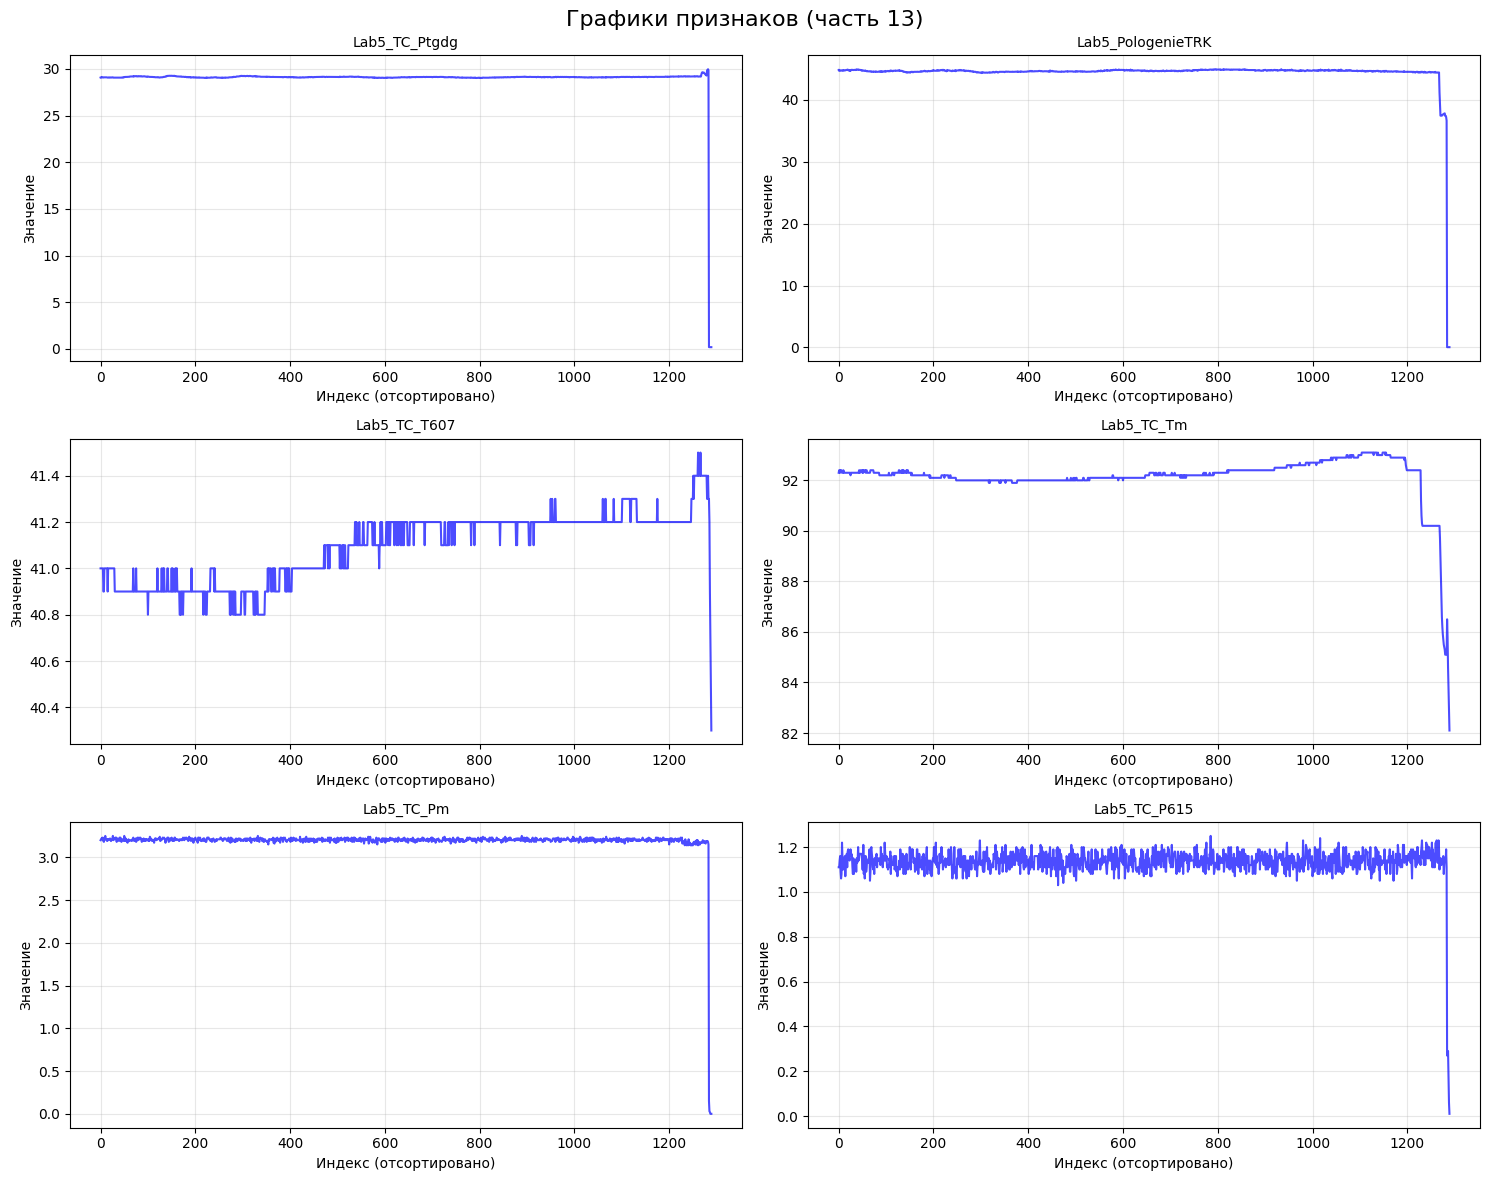

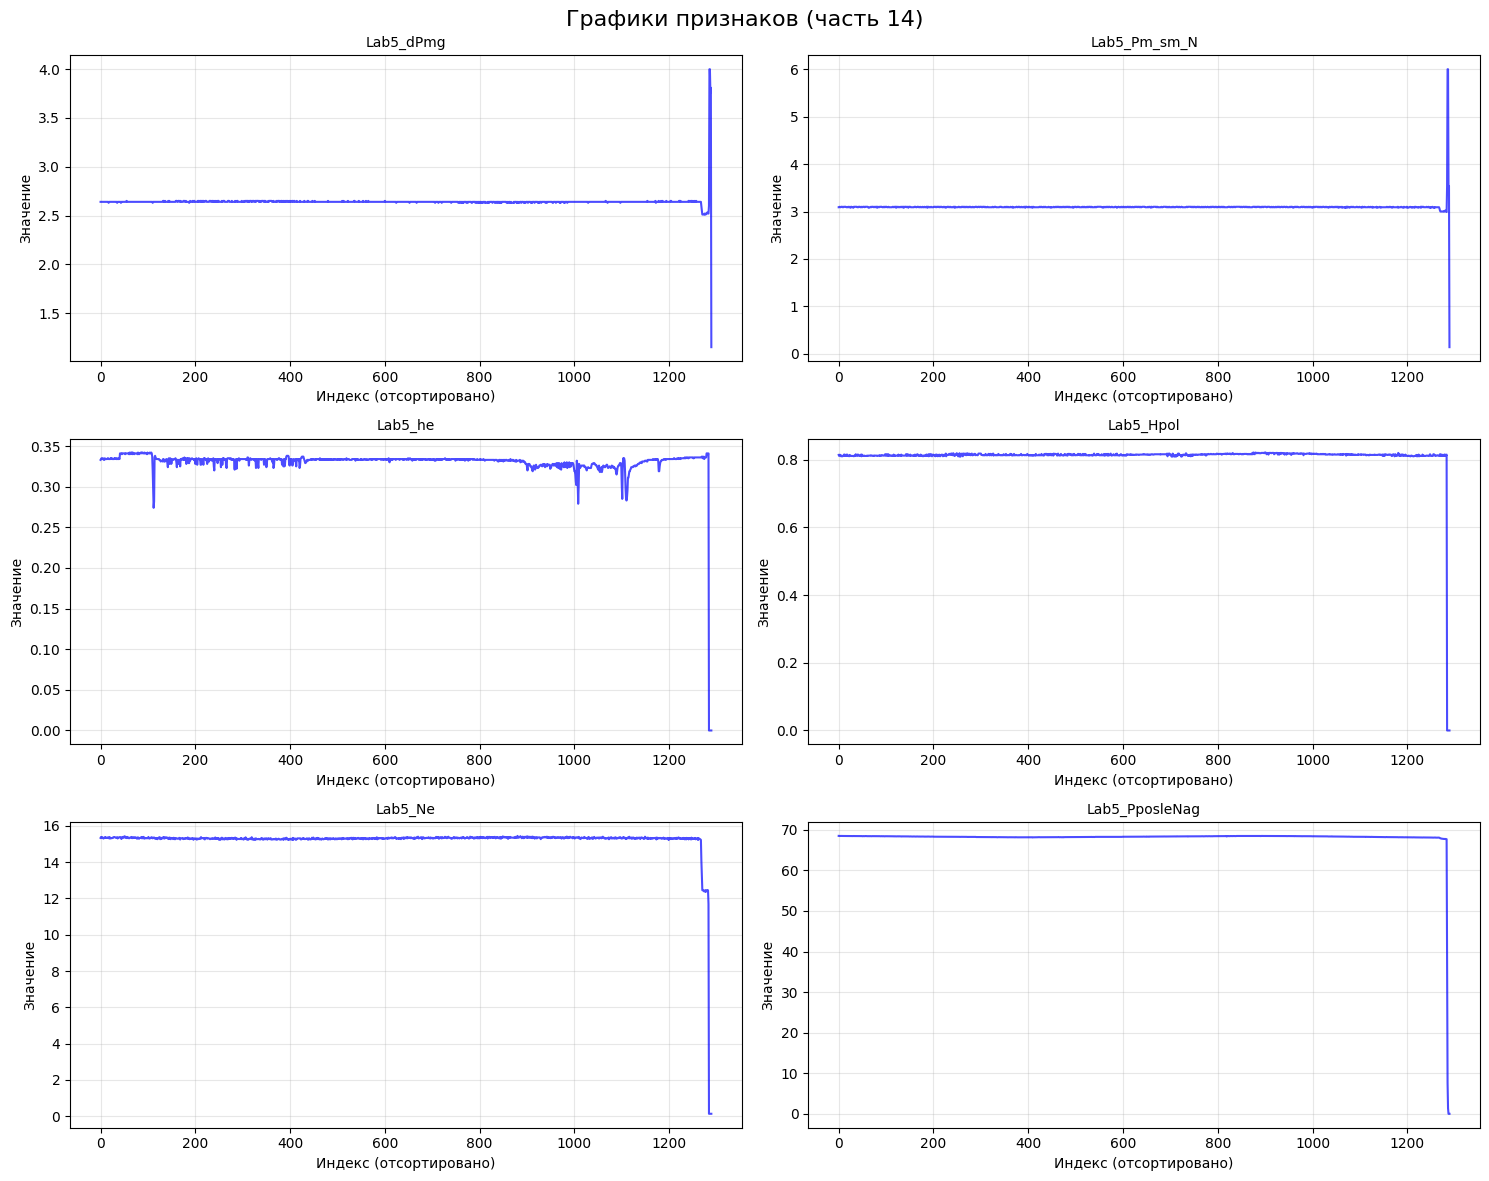

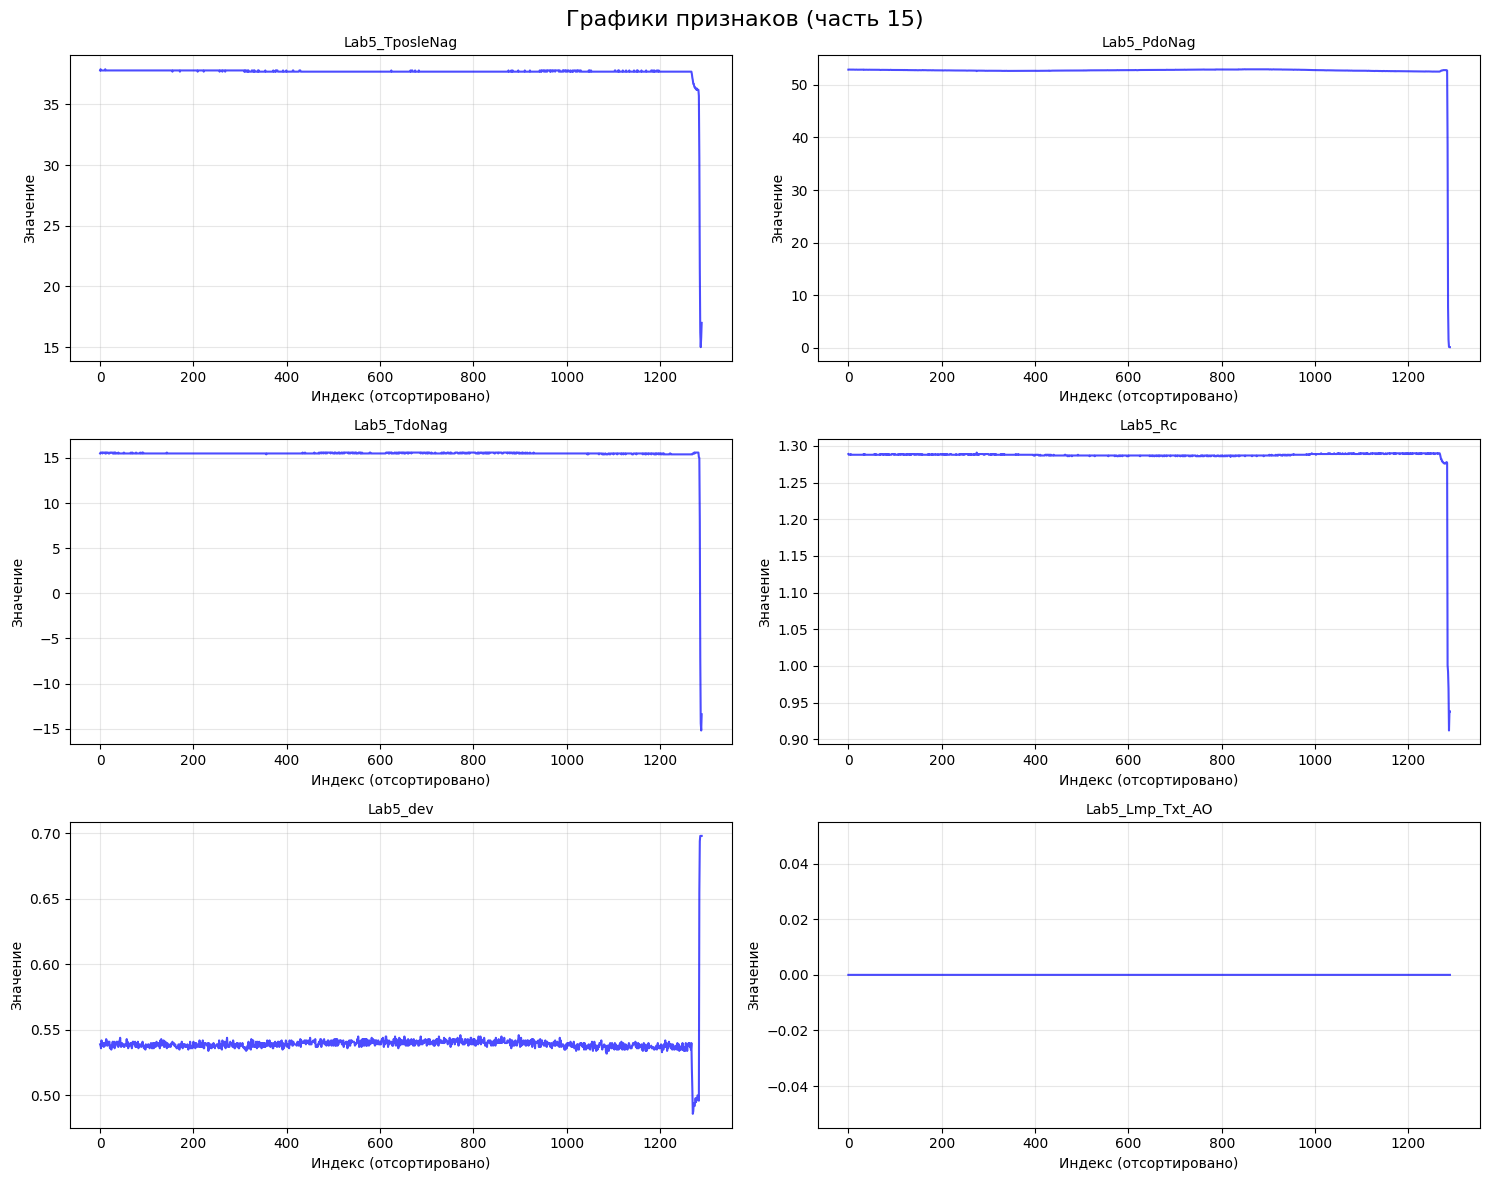

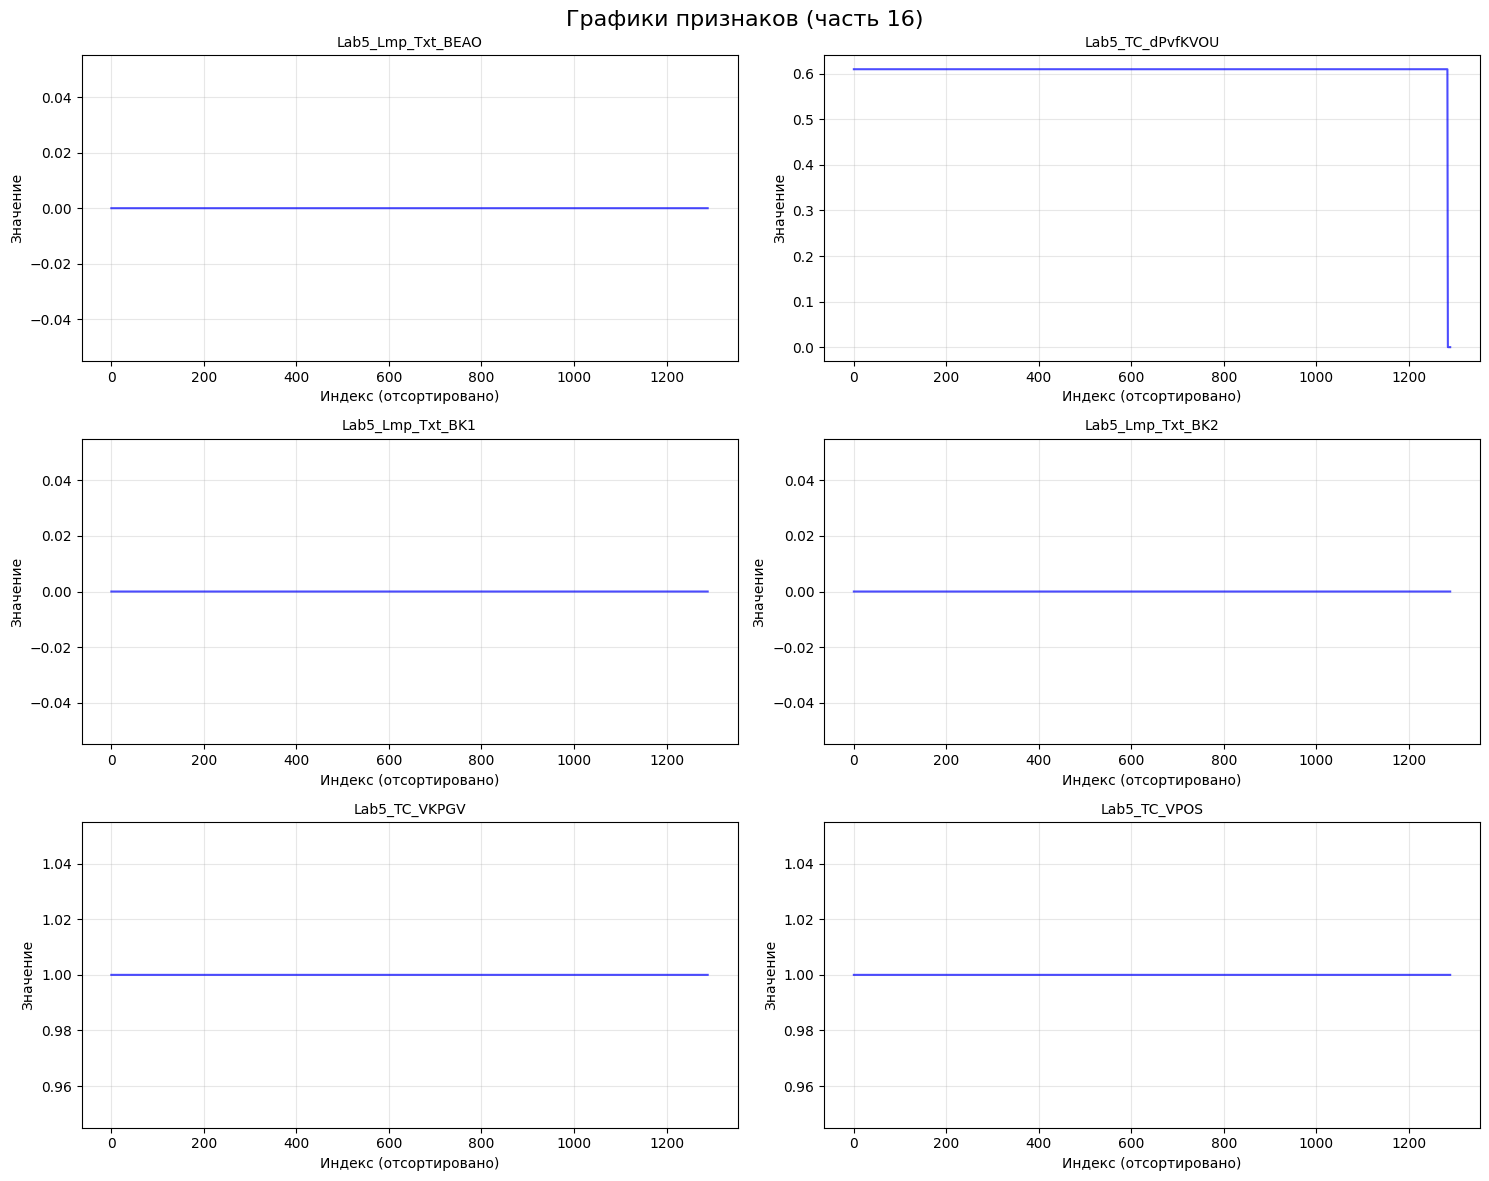

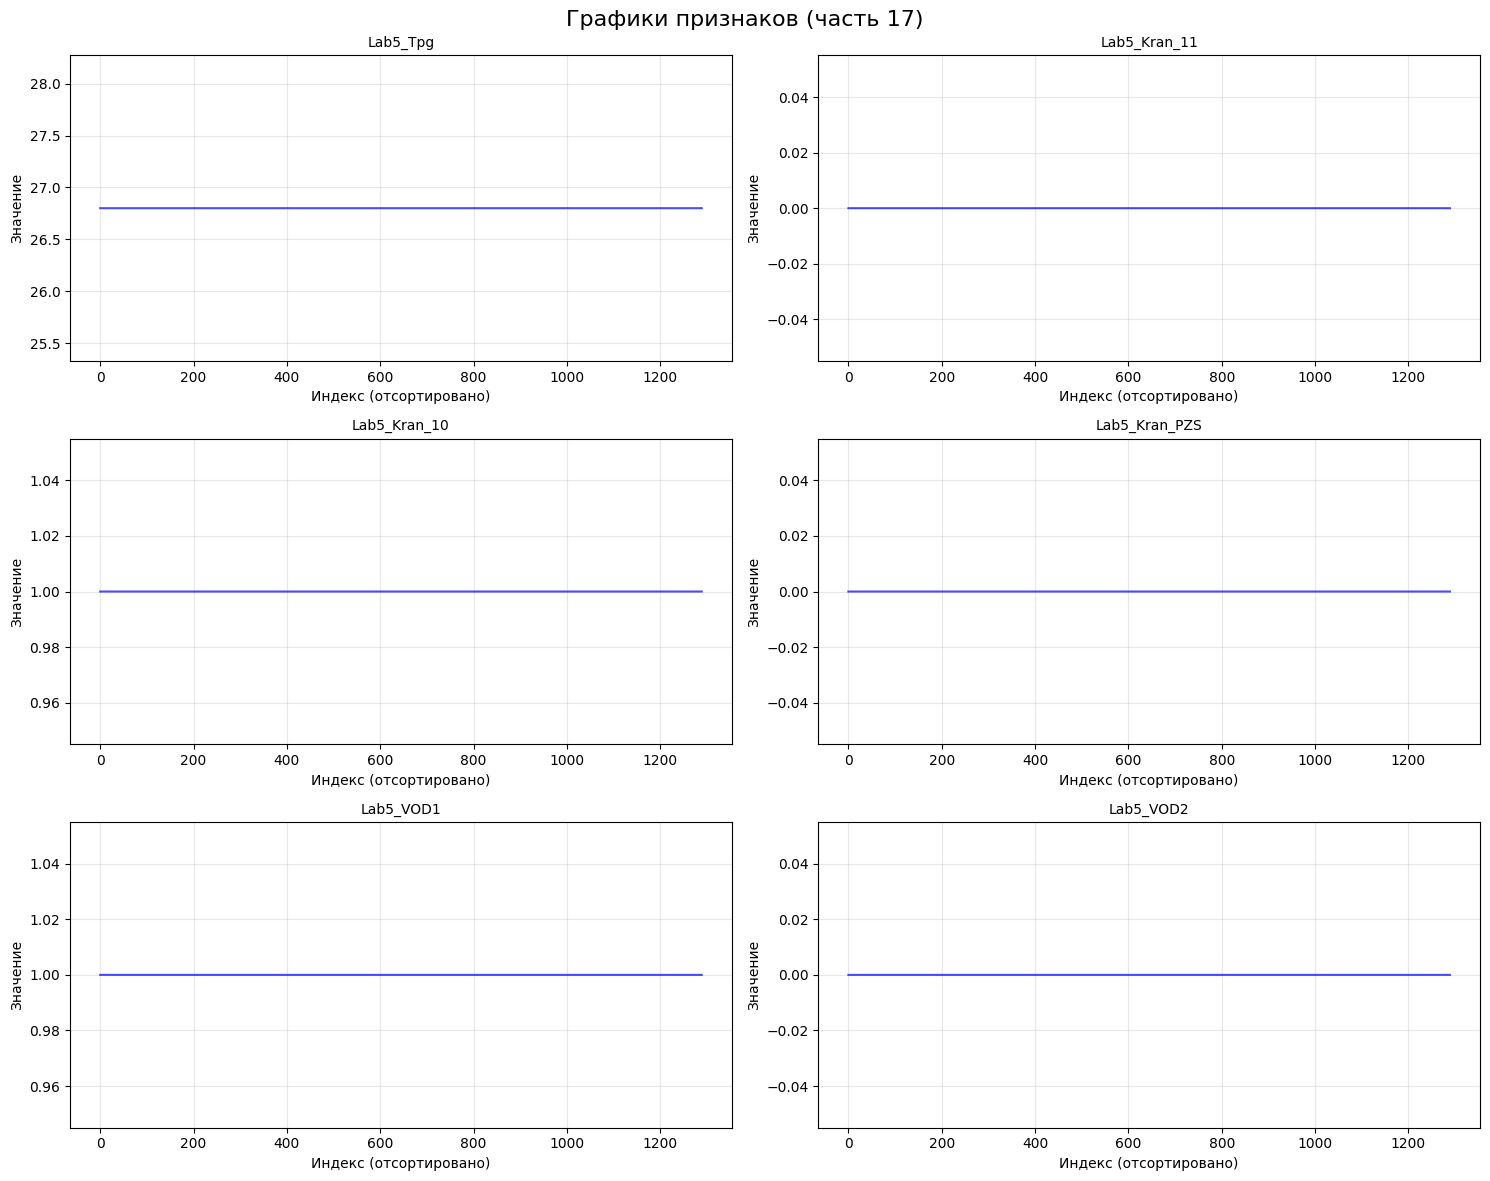

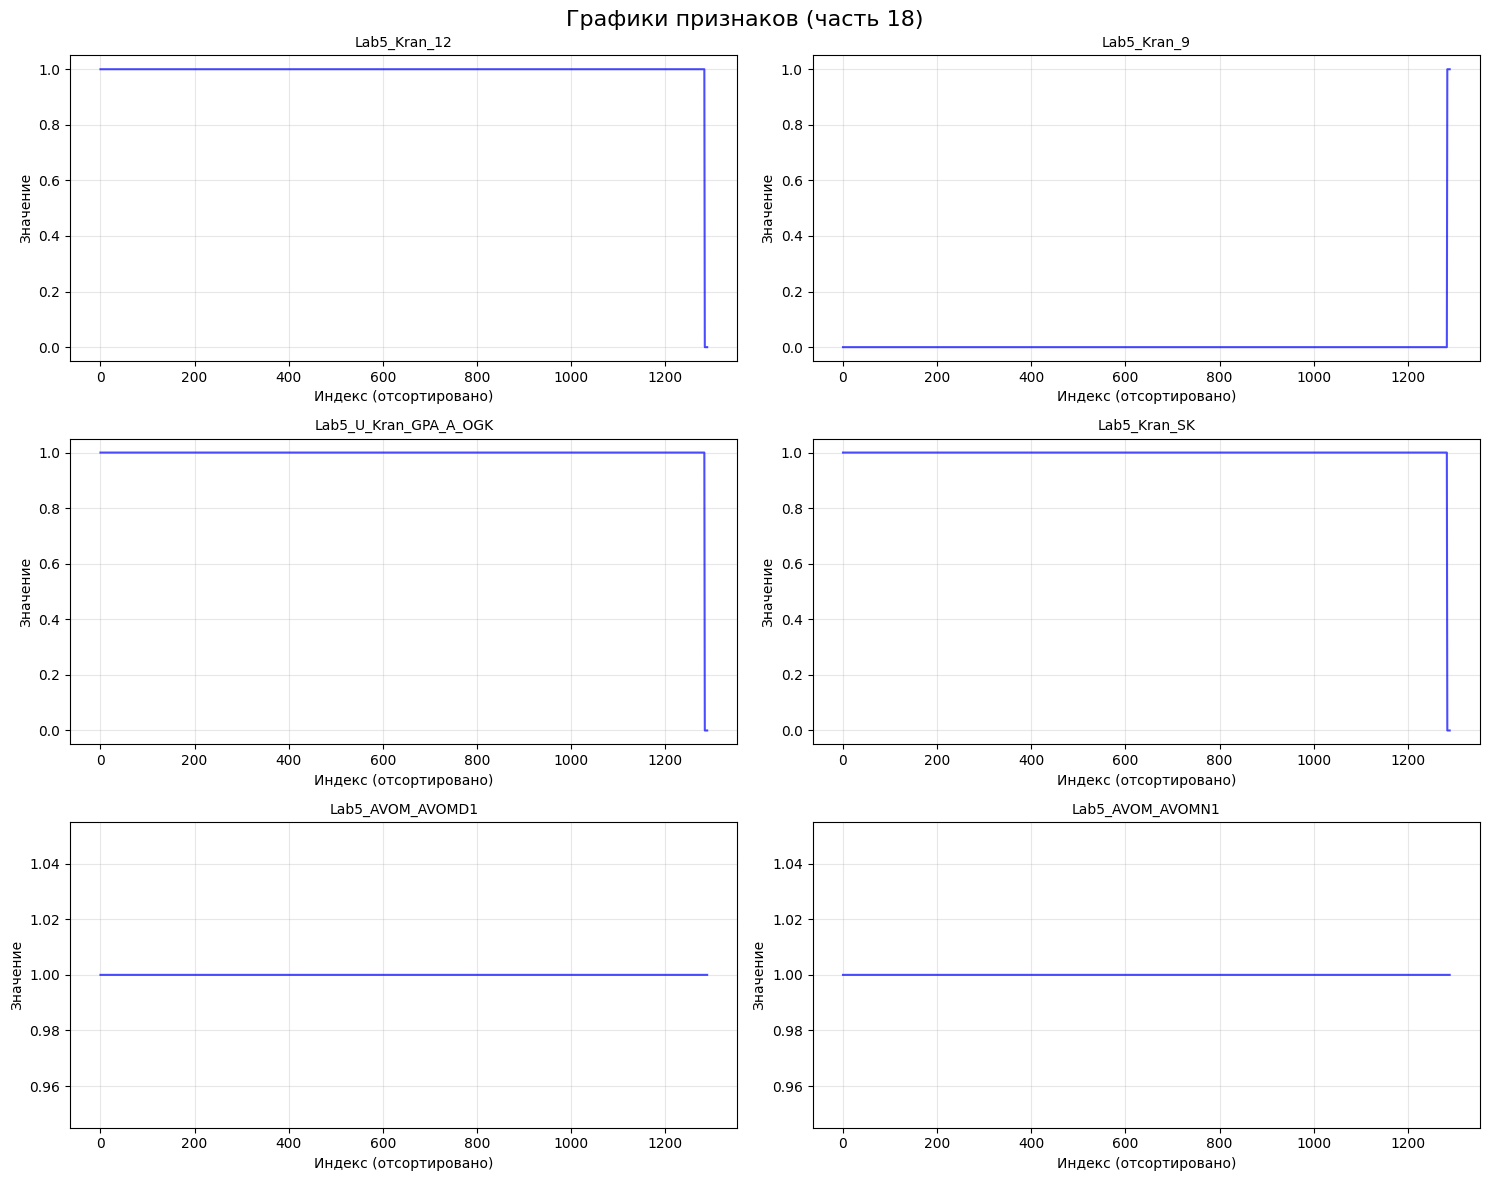

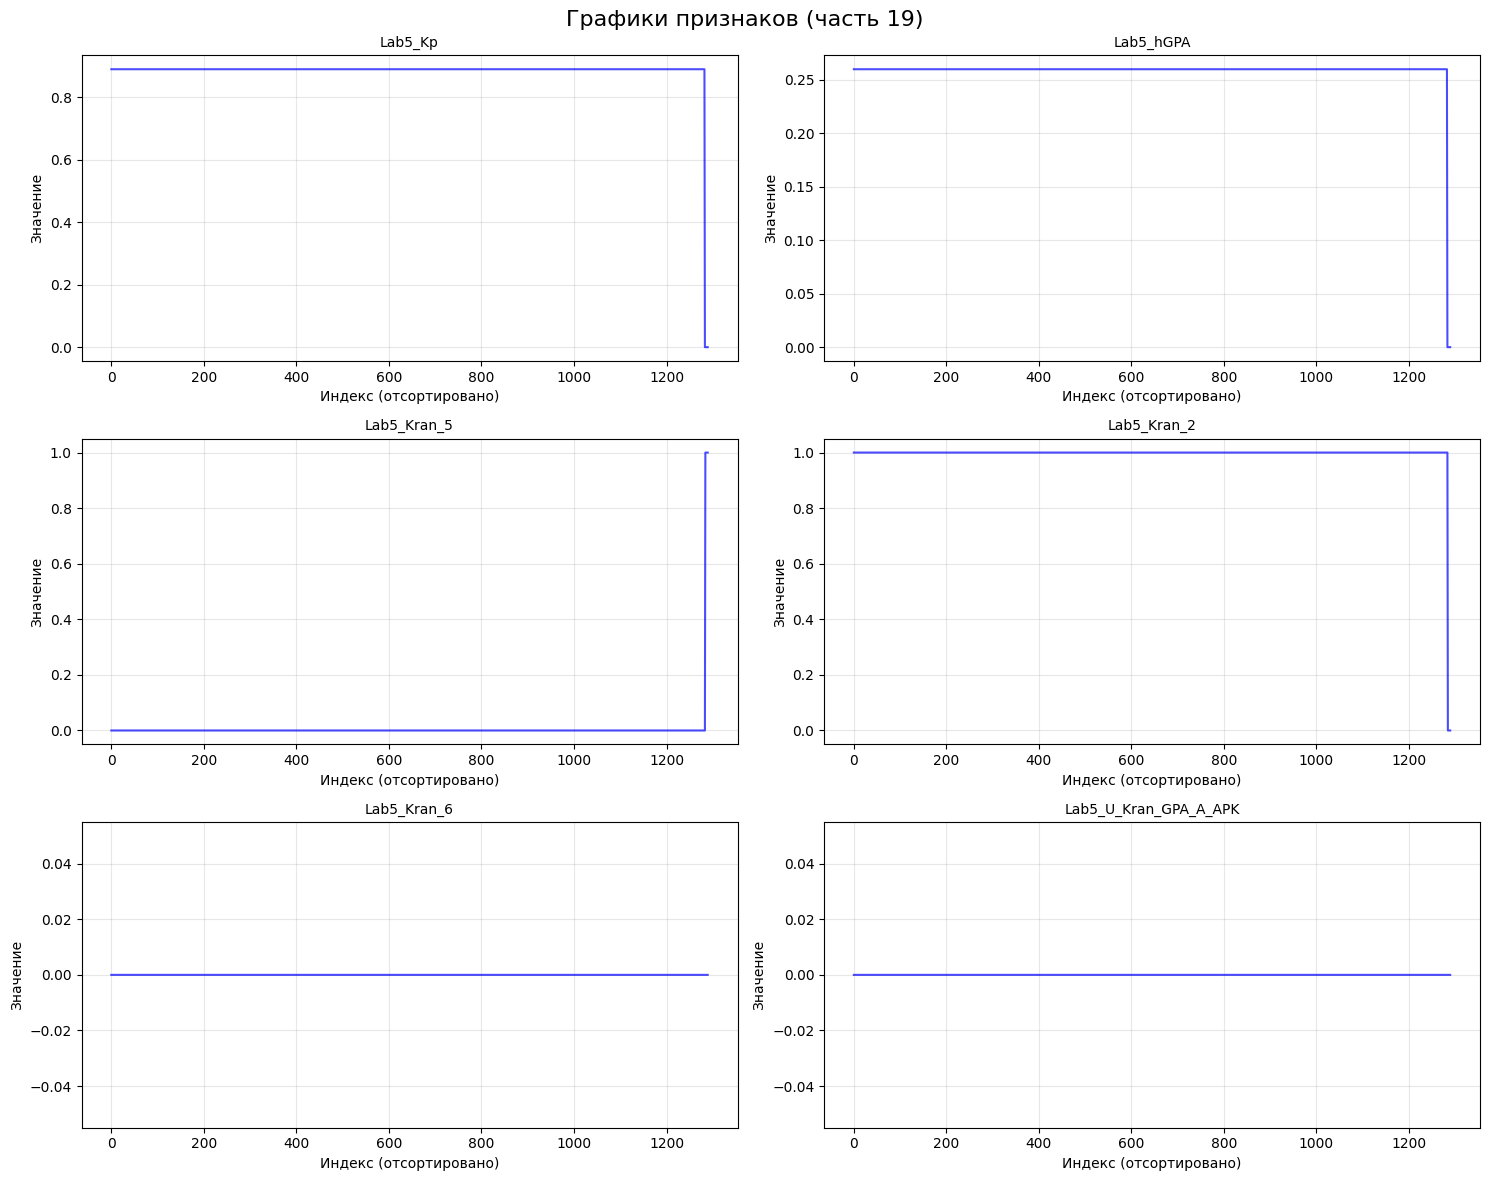

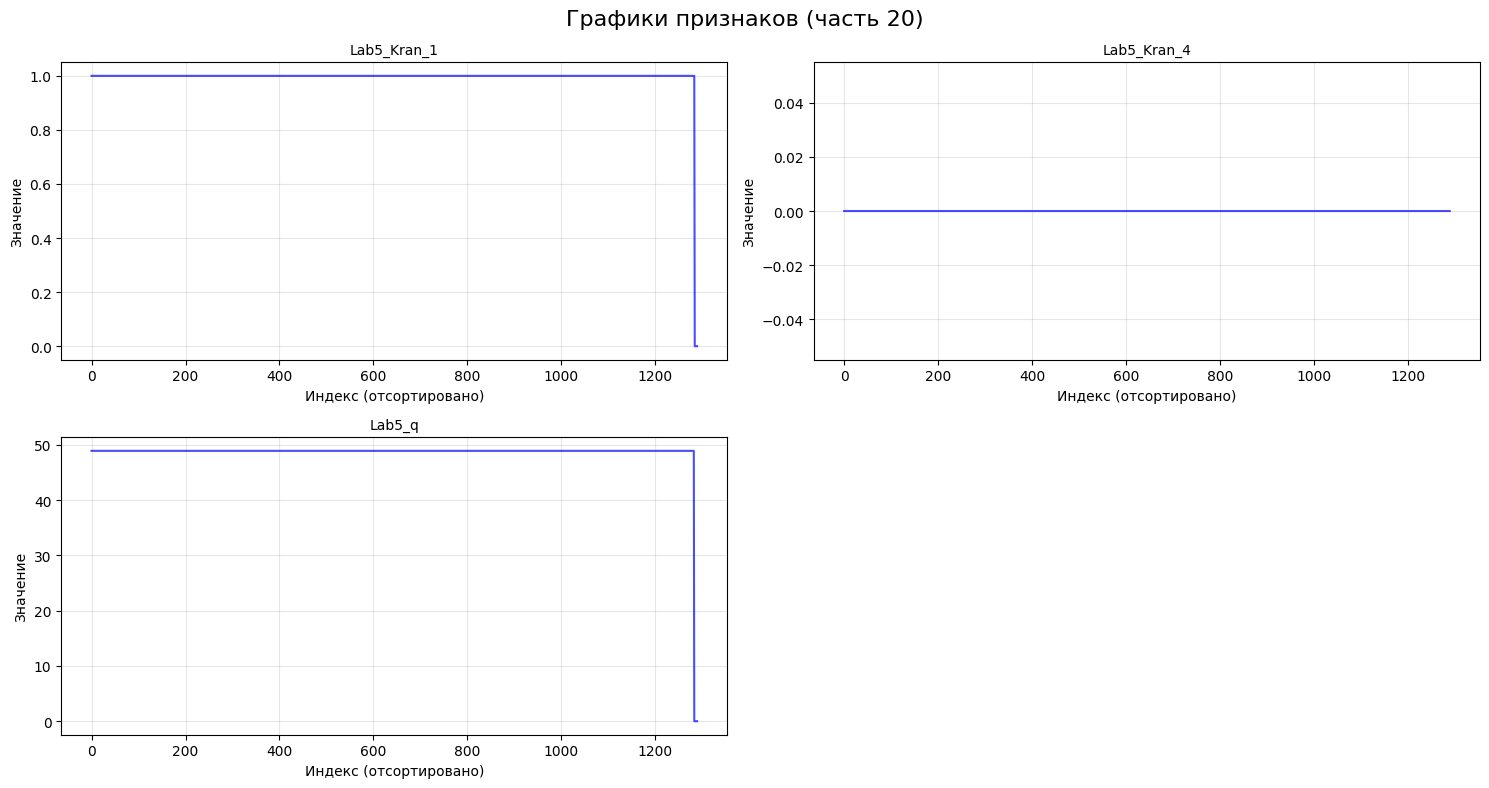

In [97]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(numeric_cols)

plots_per_figure = 6
n_figures = (n_cols + plots_per_figure - 1) // plots_per_figure  

for fig_num in range(n_figures):
    start_idx = fig_num * plots_per_figure
    end_idx = min(start_idx + plots_per_figure, n_cols)
    cols_in_figure = numeric_cols[start_idx:end_idx]
    
    # Создаем figure с субплотами
    n_plots = len(cols_in_figure)
    n_rows = (n_plots + 1) // 2  # 2 колонки, 3 строки для 6 графиков
    n_cols_grid = 2
    
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(15, 4*n_rows))
    fig.suptitle(f'Графики признаков (часть {fig_num+1})', fontsize=16)
    
    # Выравниваем оси в одномерный массив для удобства
    axes_flat = axes.flatten() if n_plots > 1 else [axes]
    
    for idx, col in enumerate(cols_in_figure):
        # Для line plot нужны значения по X (индекс) и Y (значения признака)
        # Сортируем данные для连贯ного графика
        # sorted_data = df[col].dropna().sort_values().reset_index(drop=True)
        axes_flat[idx].plot(df[col].index, df[col].values, 
                           linewidth=1.5, color='blue', alpha=0.7)
        axes_flat[idx].set_title(f'{col}', fontsize=10)
        axes_flat[idx].set_xlabel('Индекс (отсортировано)')
        axes_flat[idx].set_ylabel('Значение')
        axes_flat[idx].grid(True, alpha=0.3)
    
    # Скрываем пустые субплоты
    for idx in range(len(cols_in_figure), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

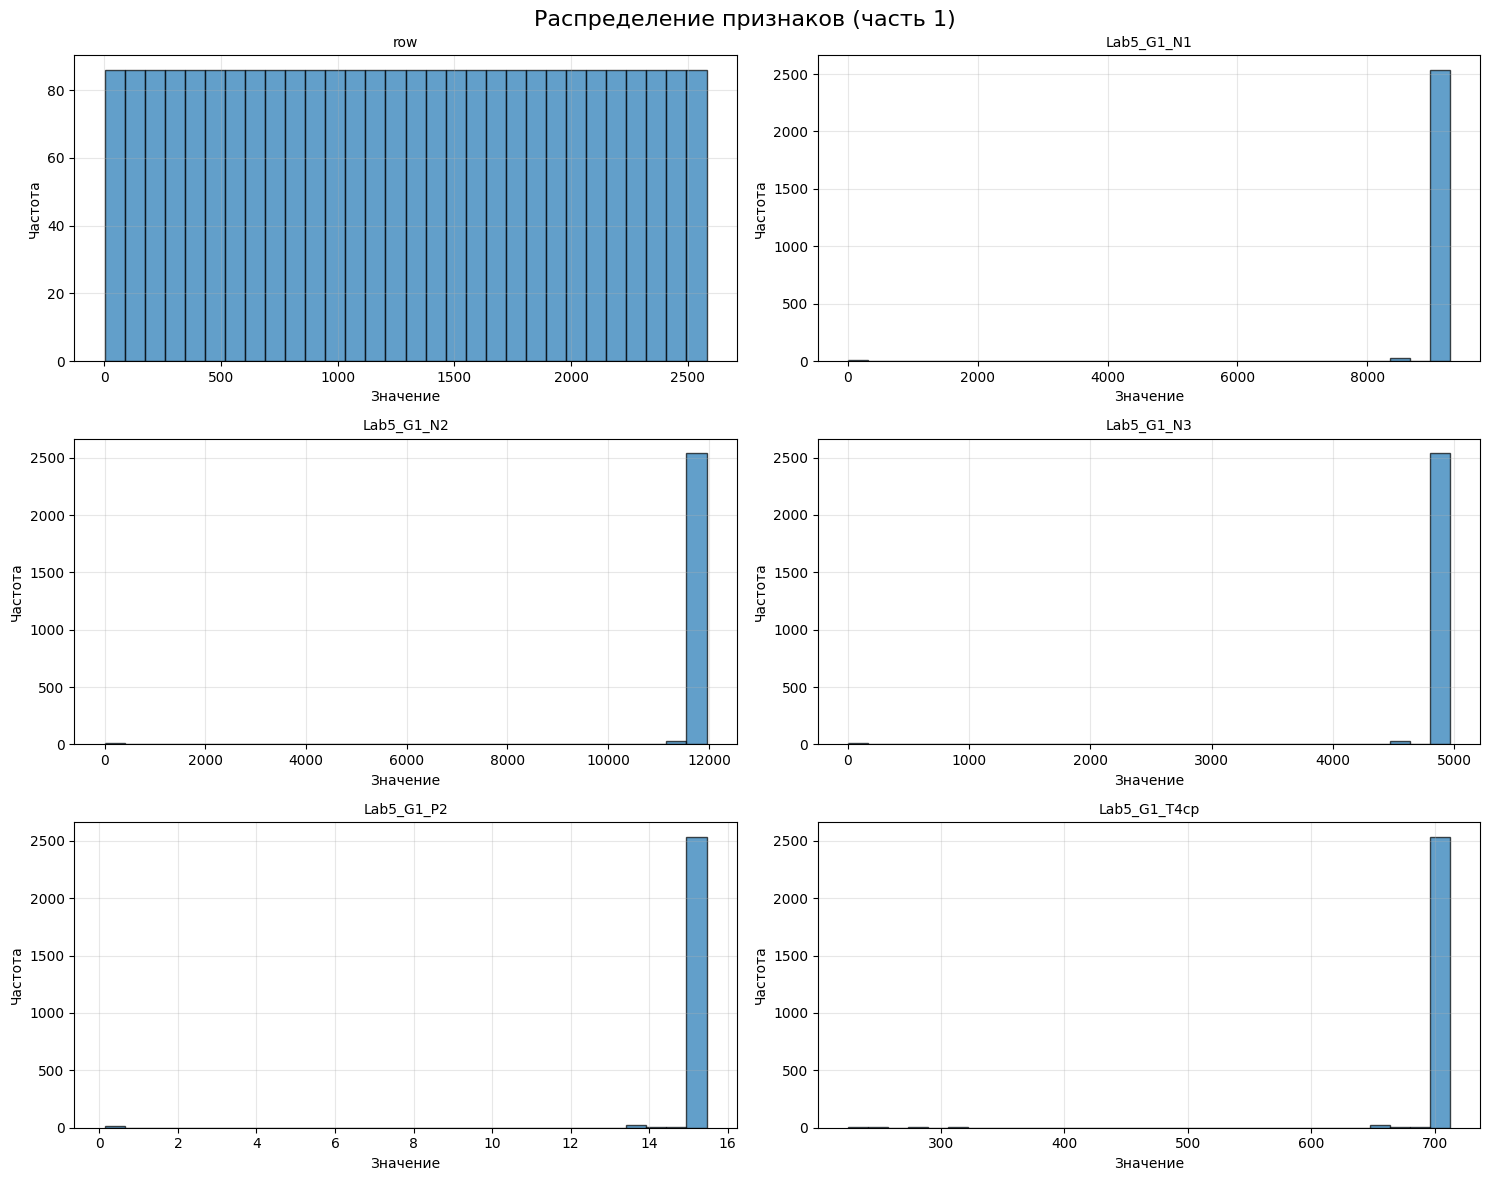

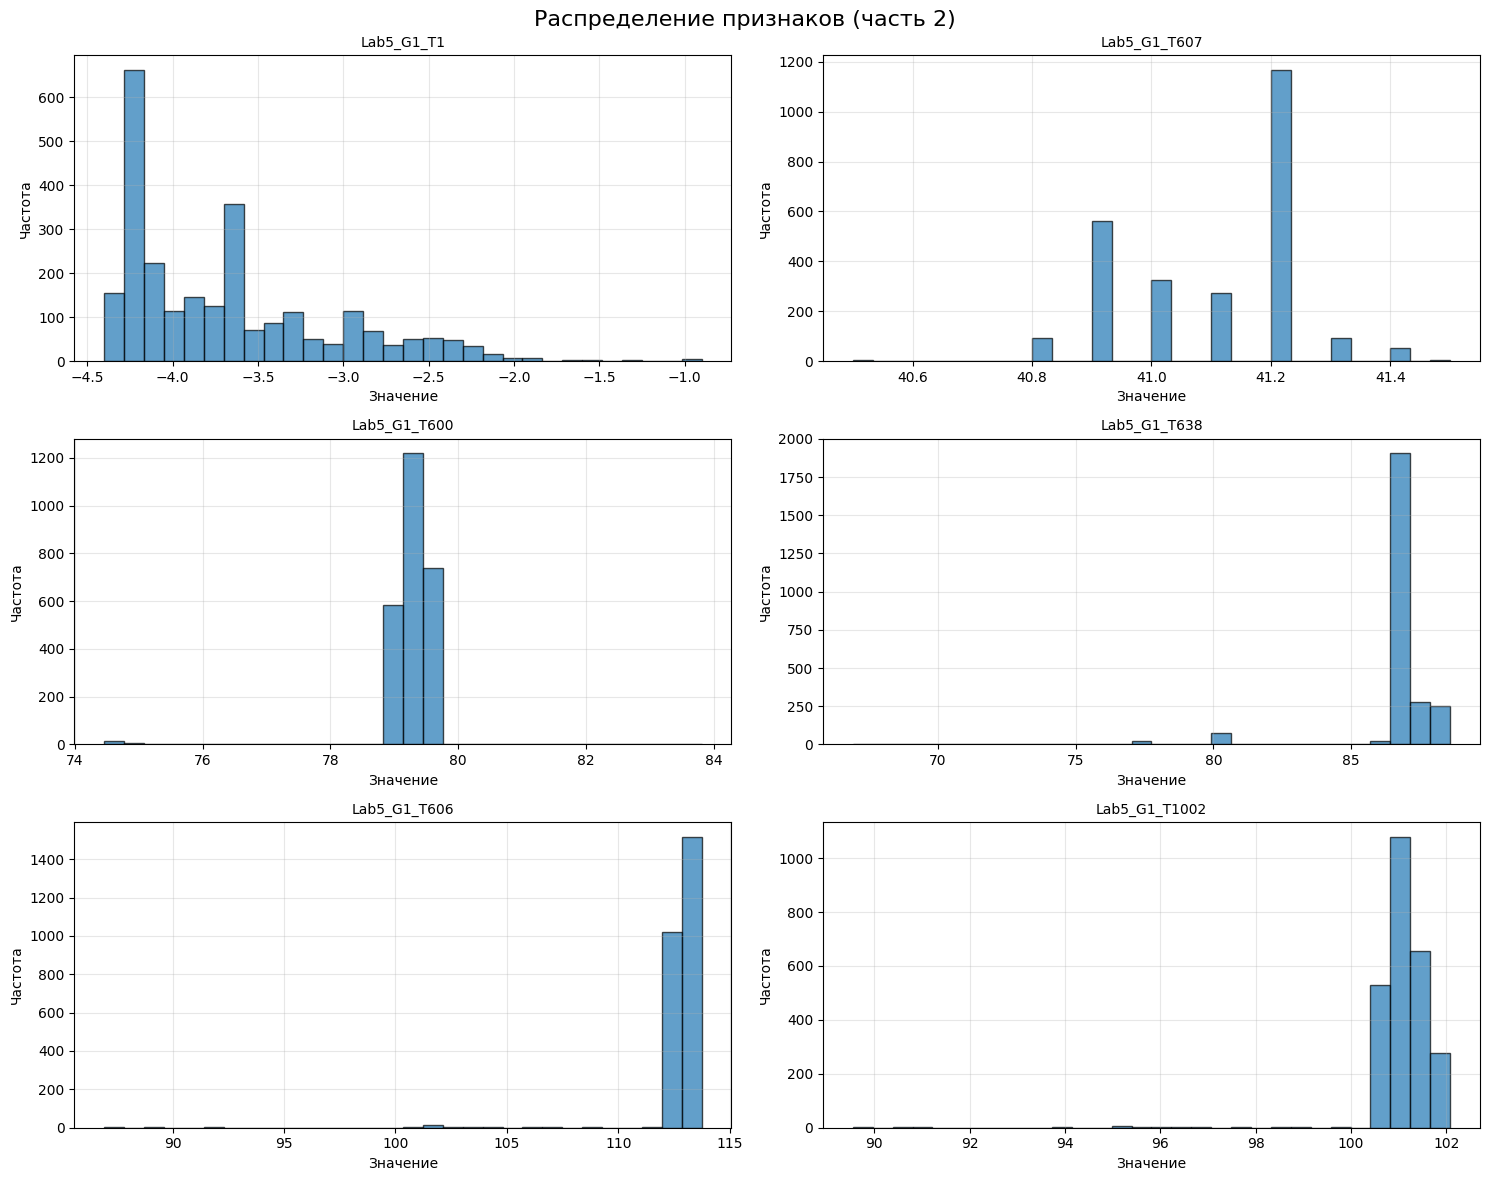

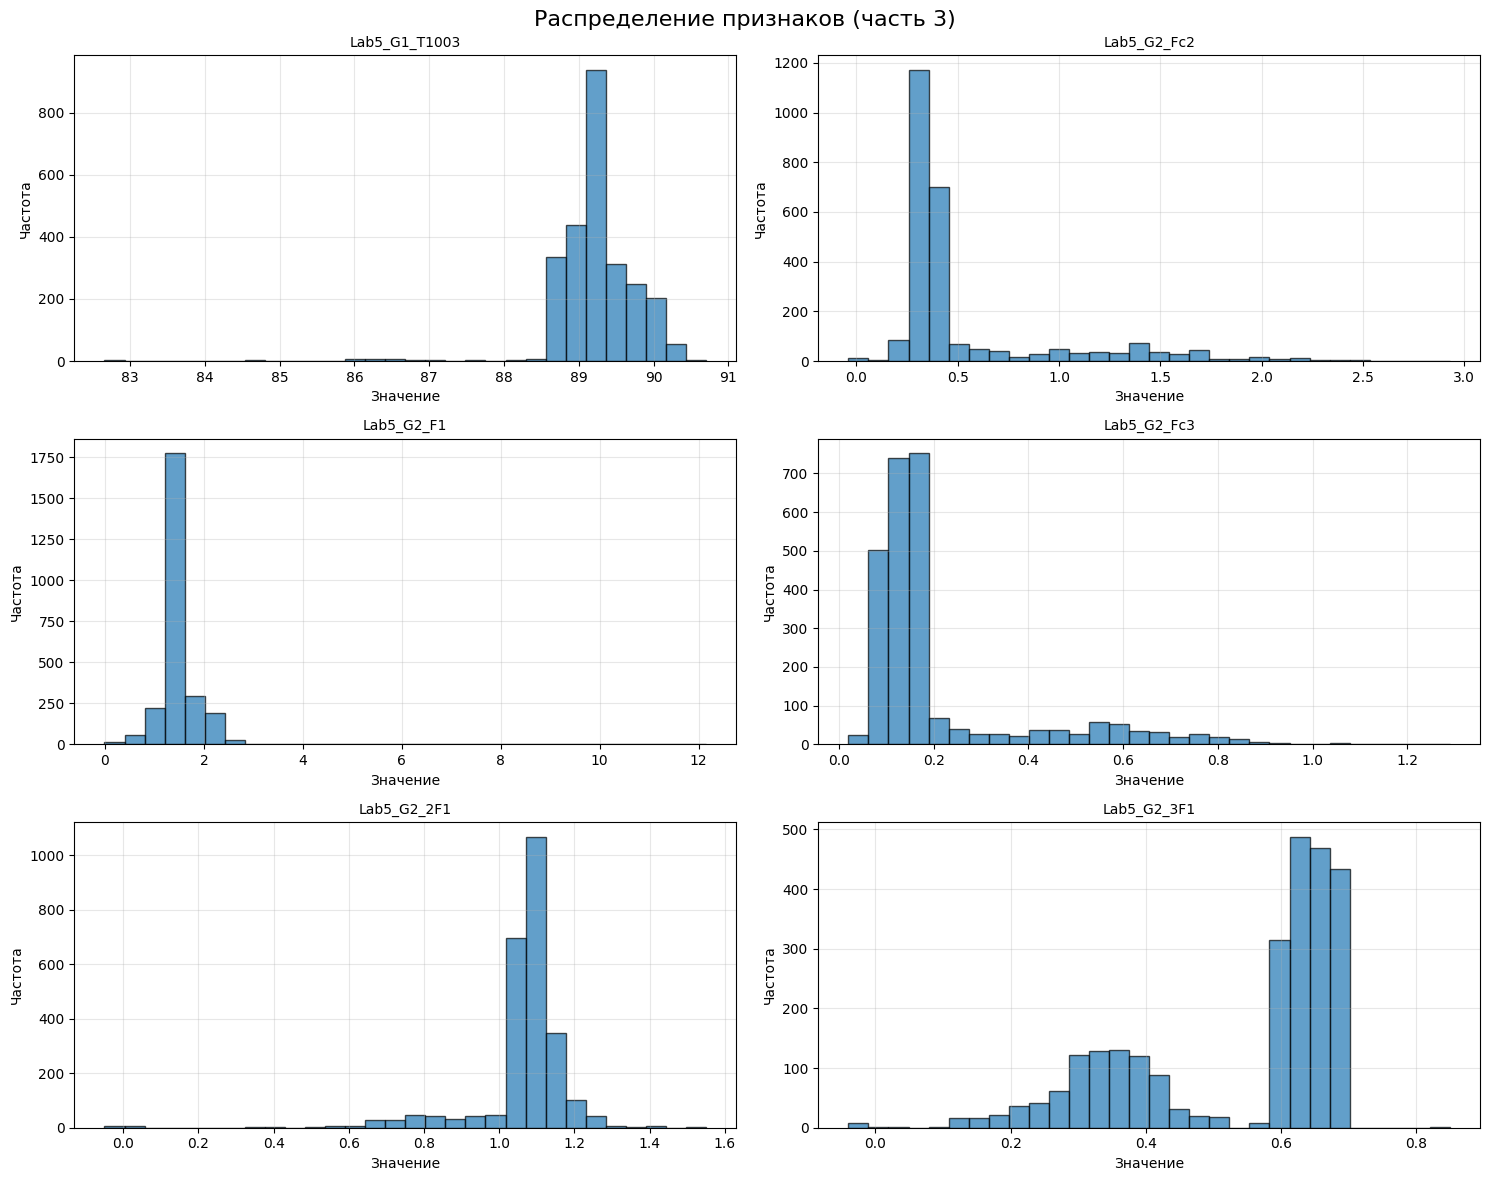

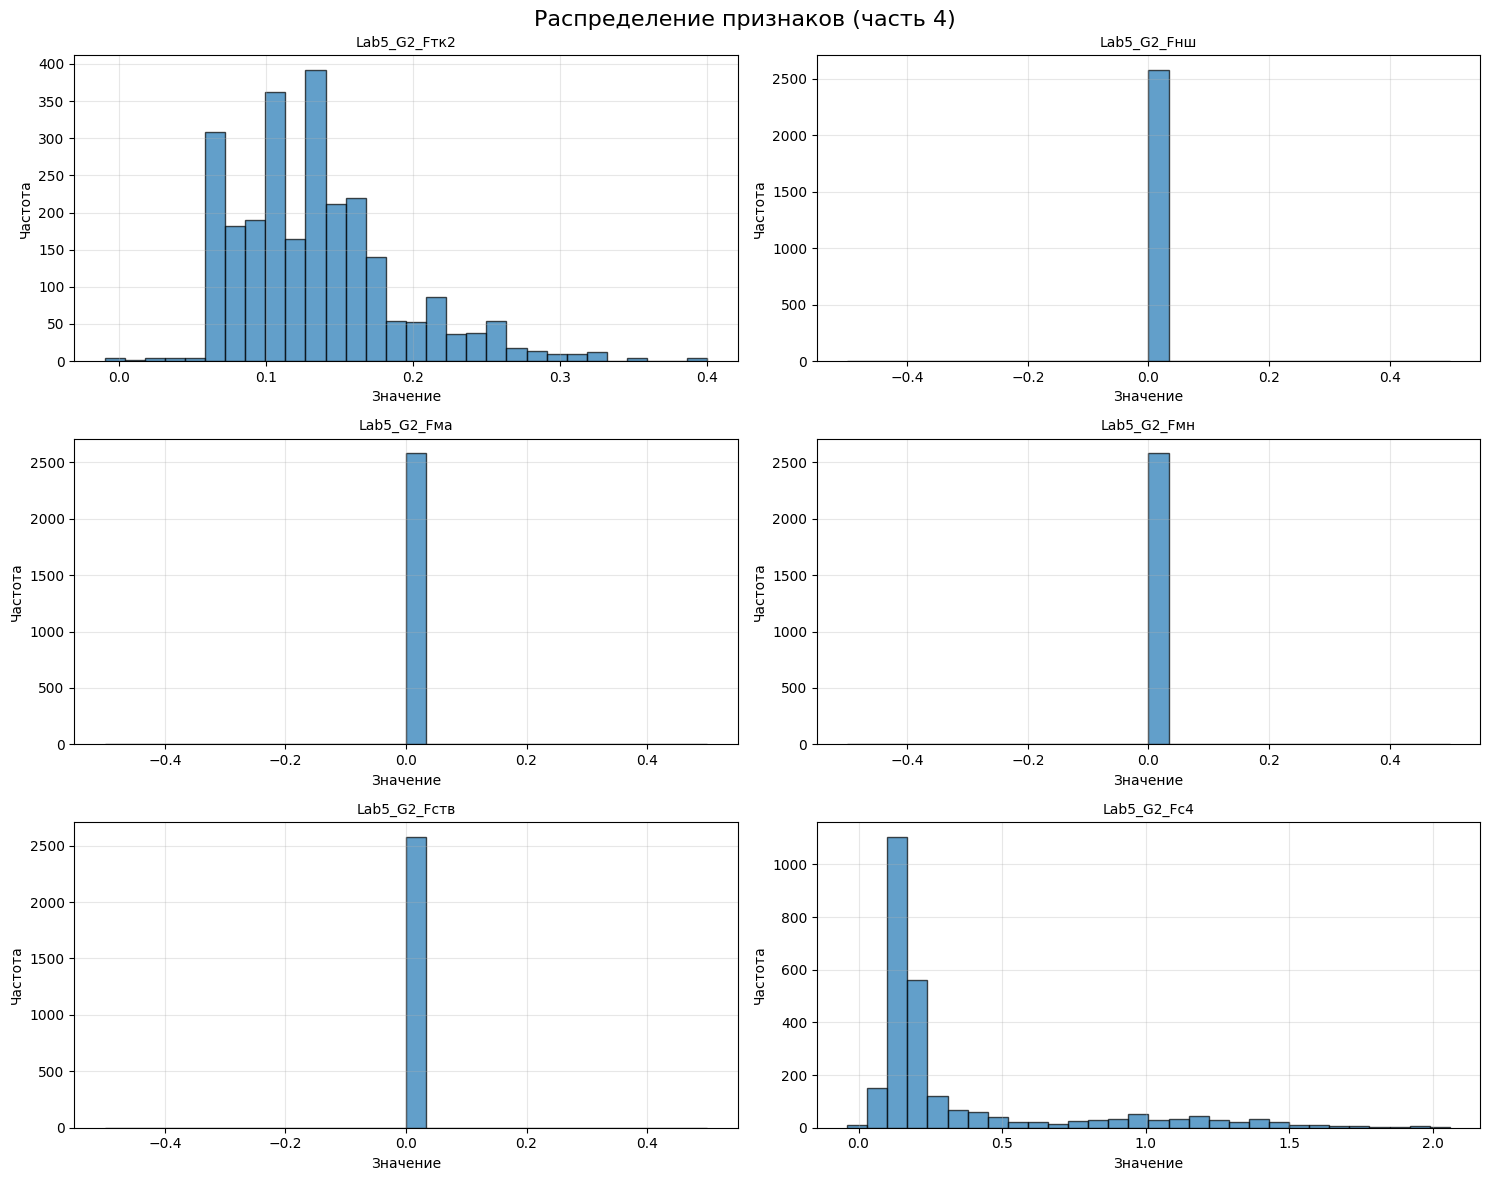

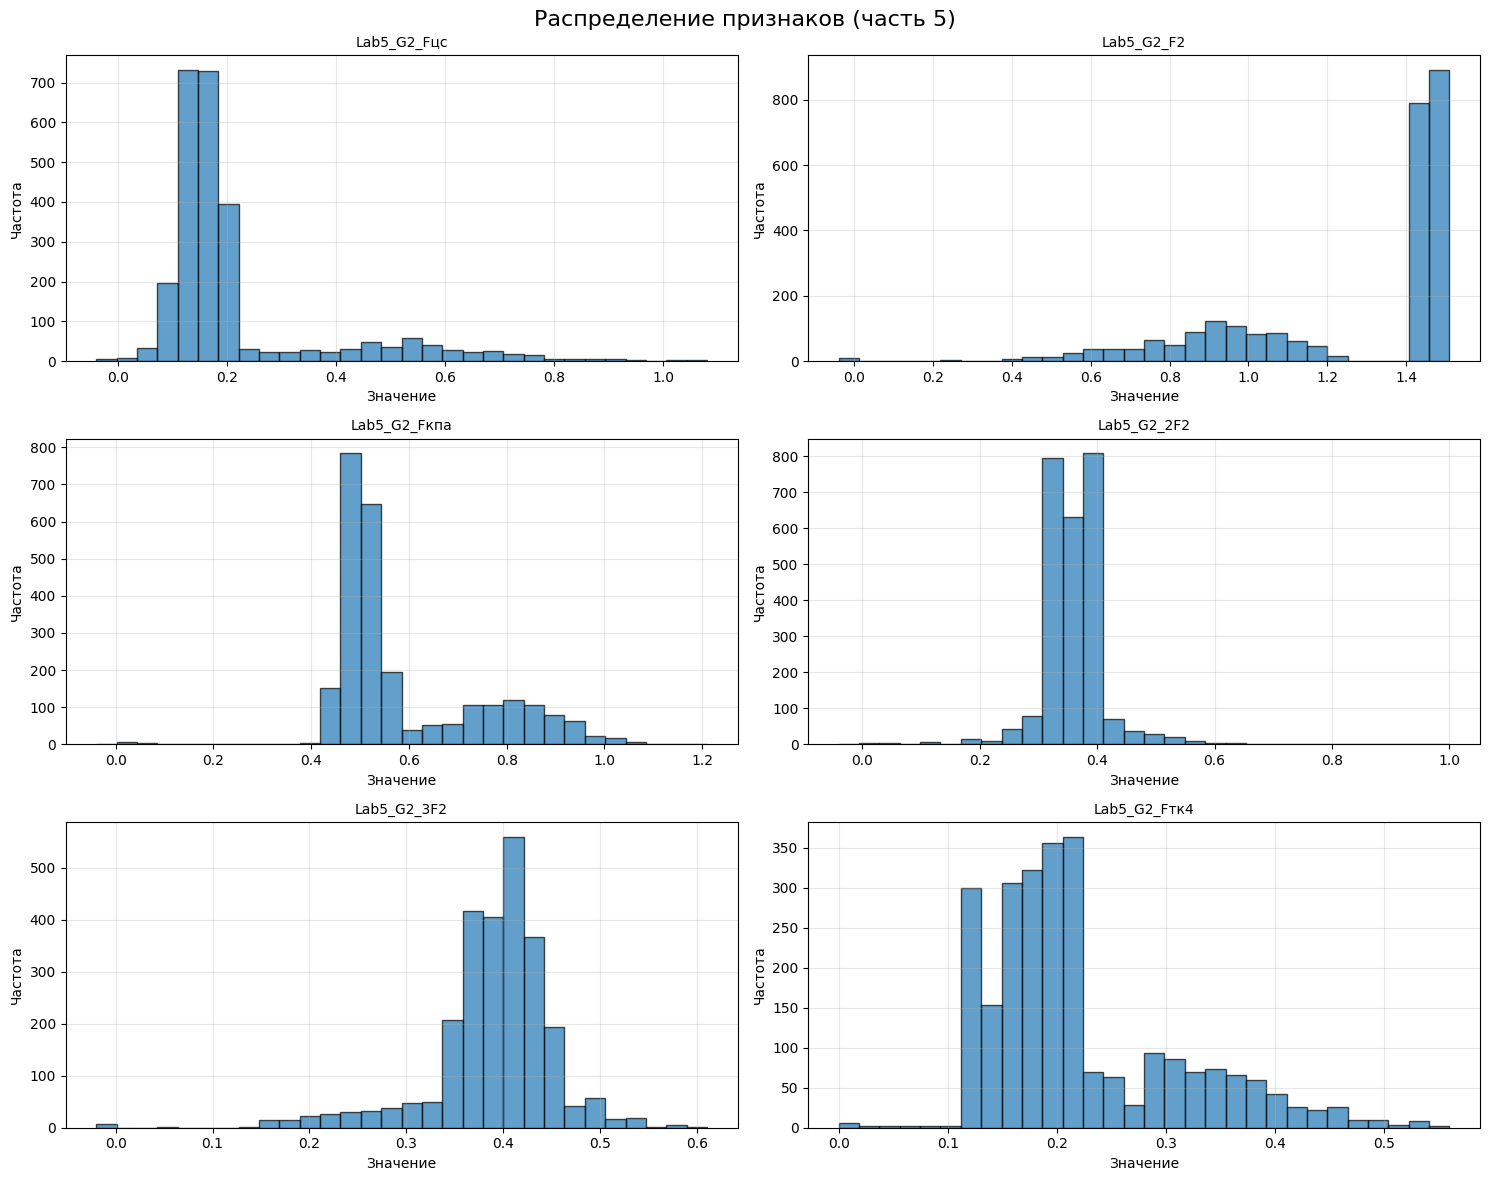

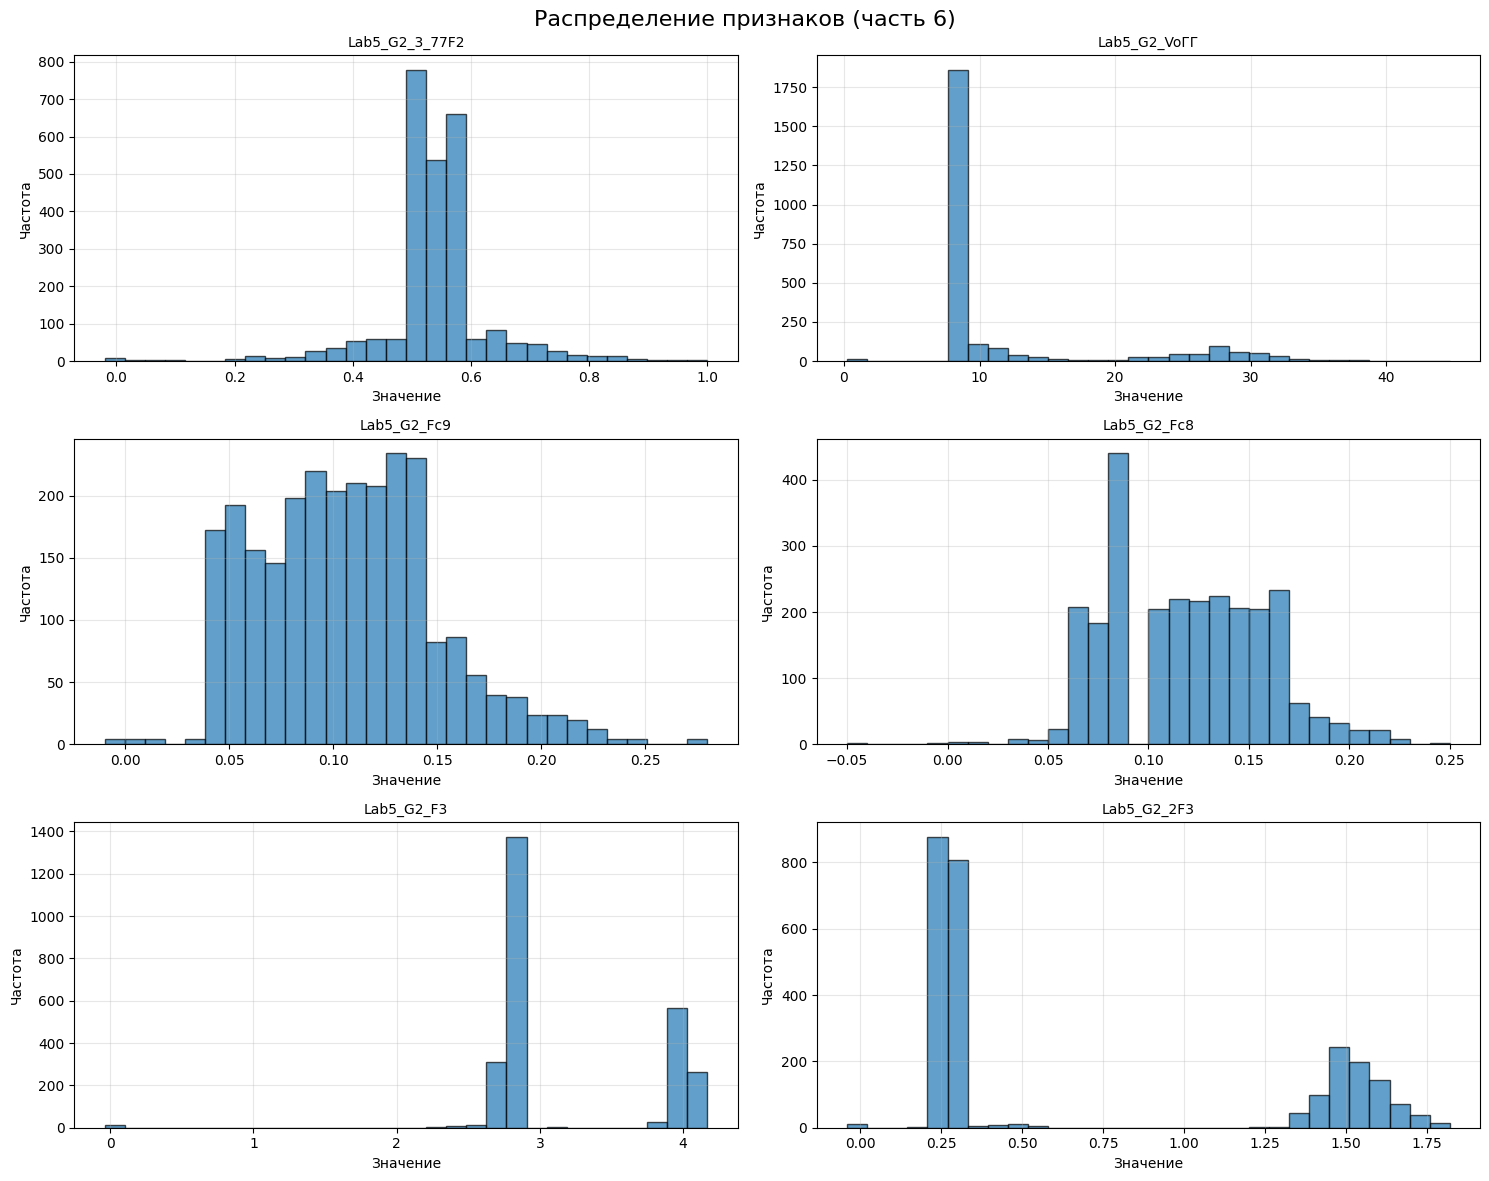

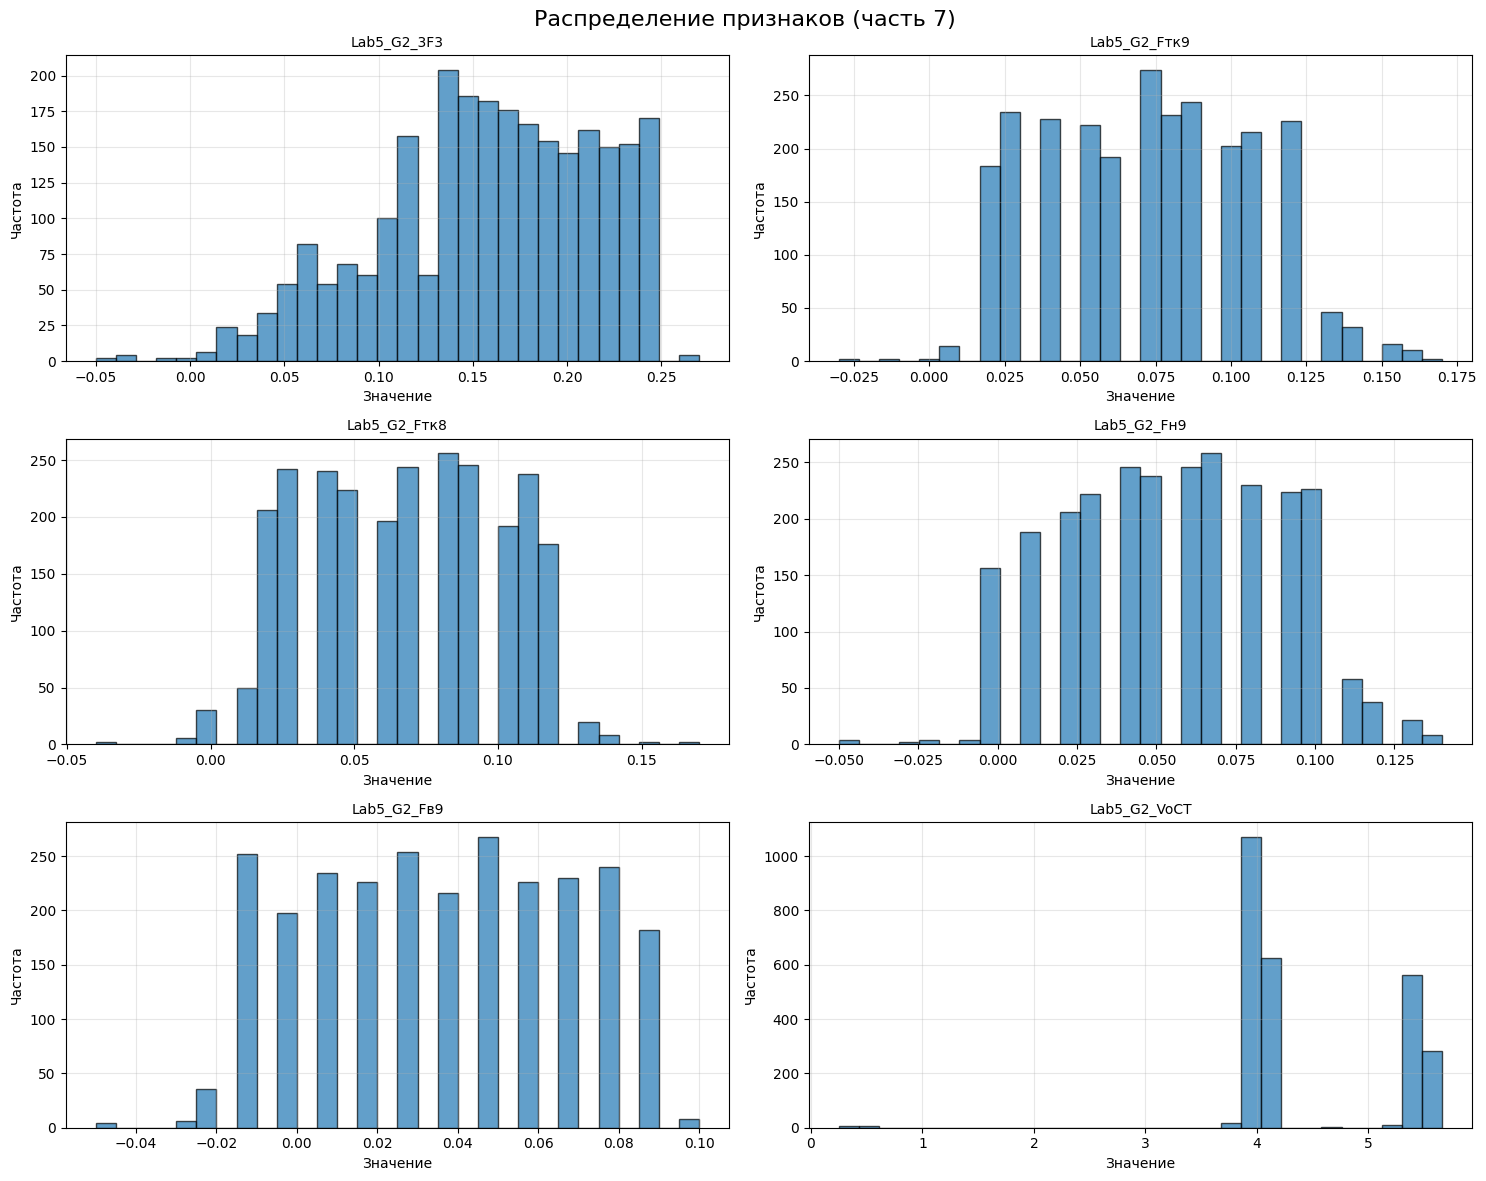

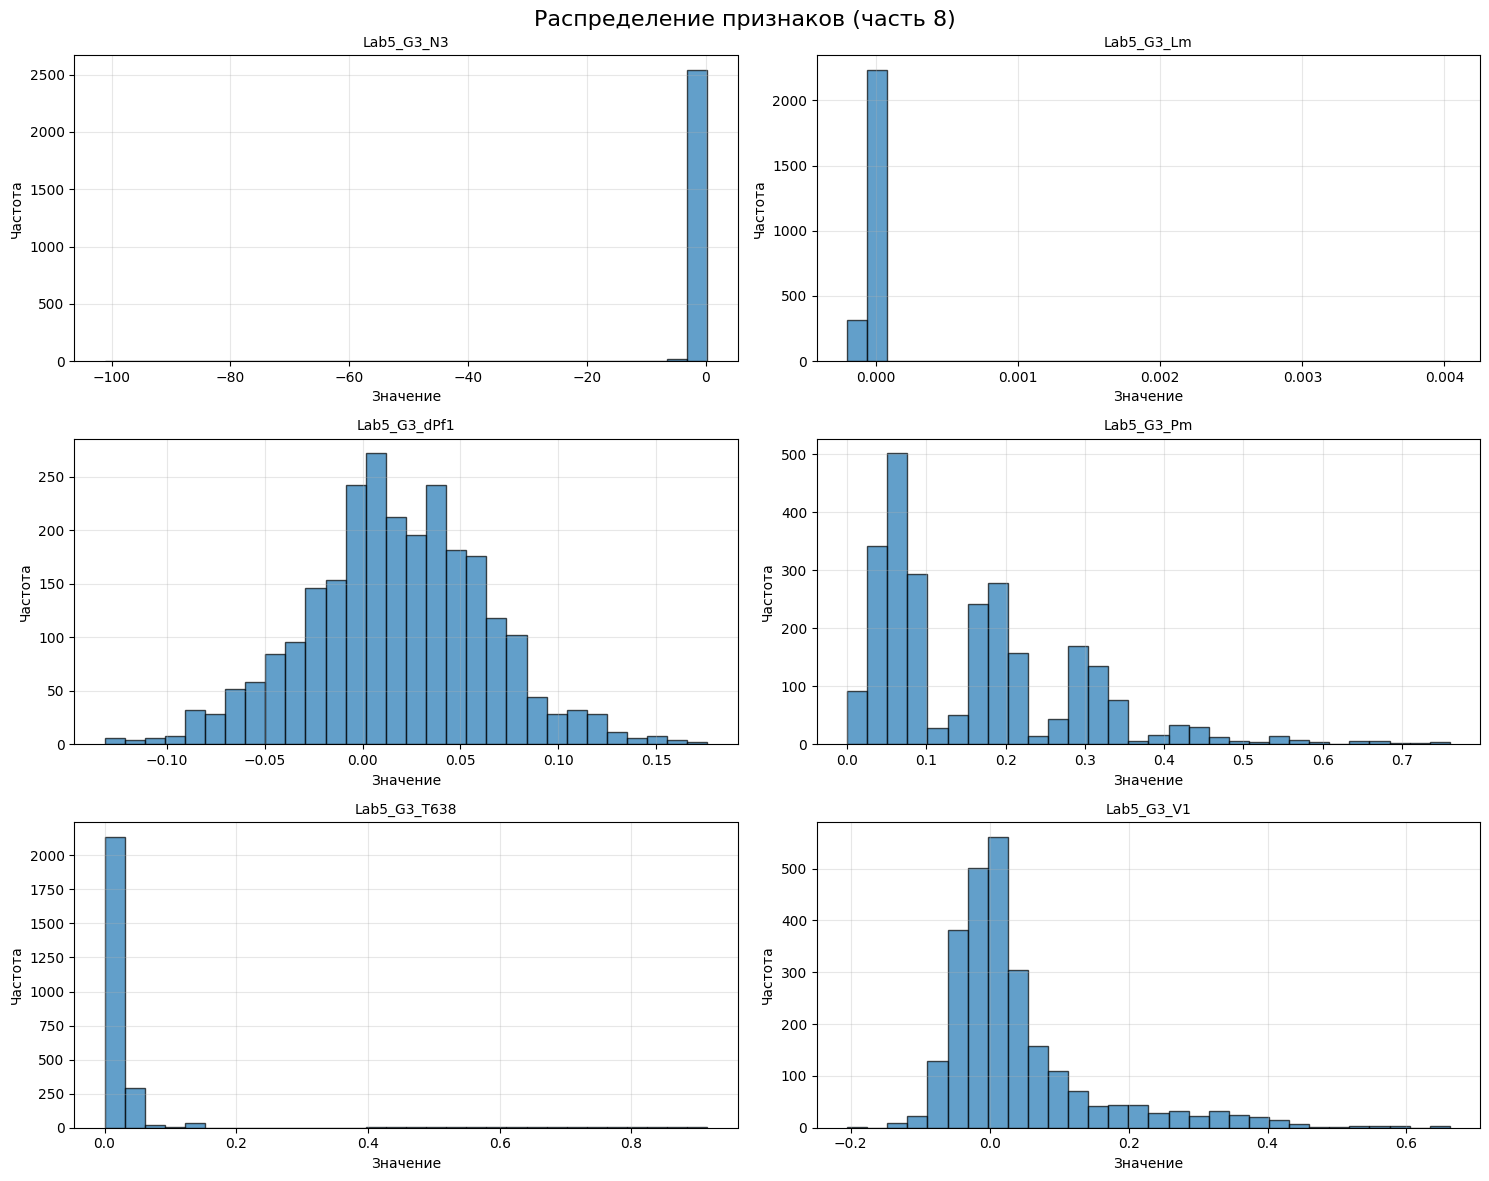

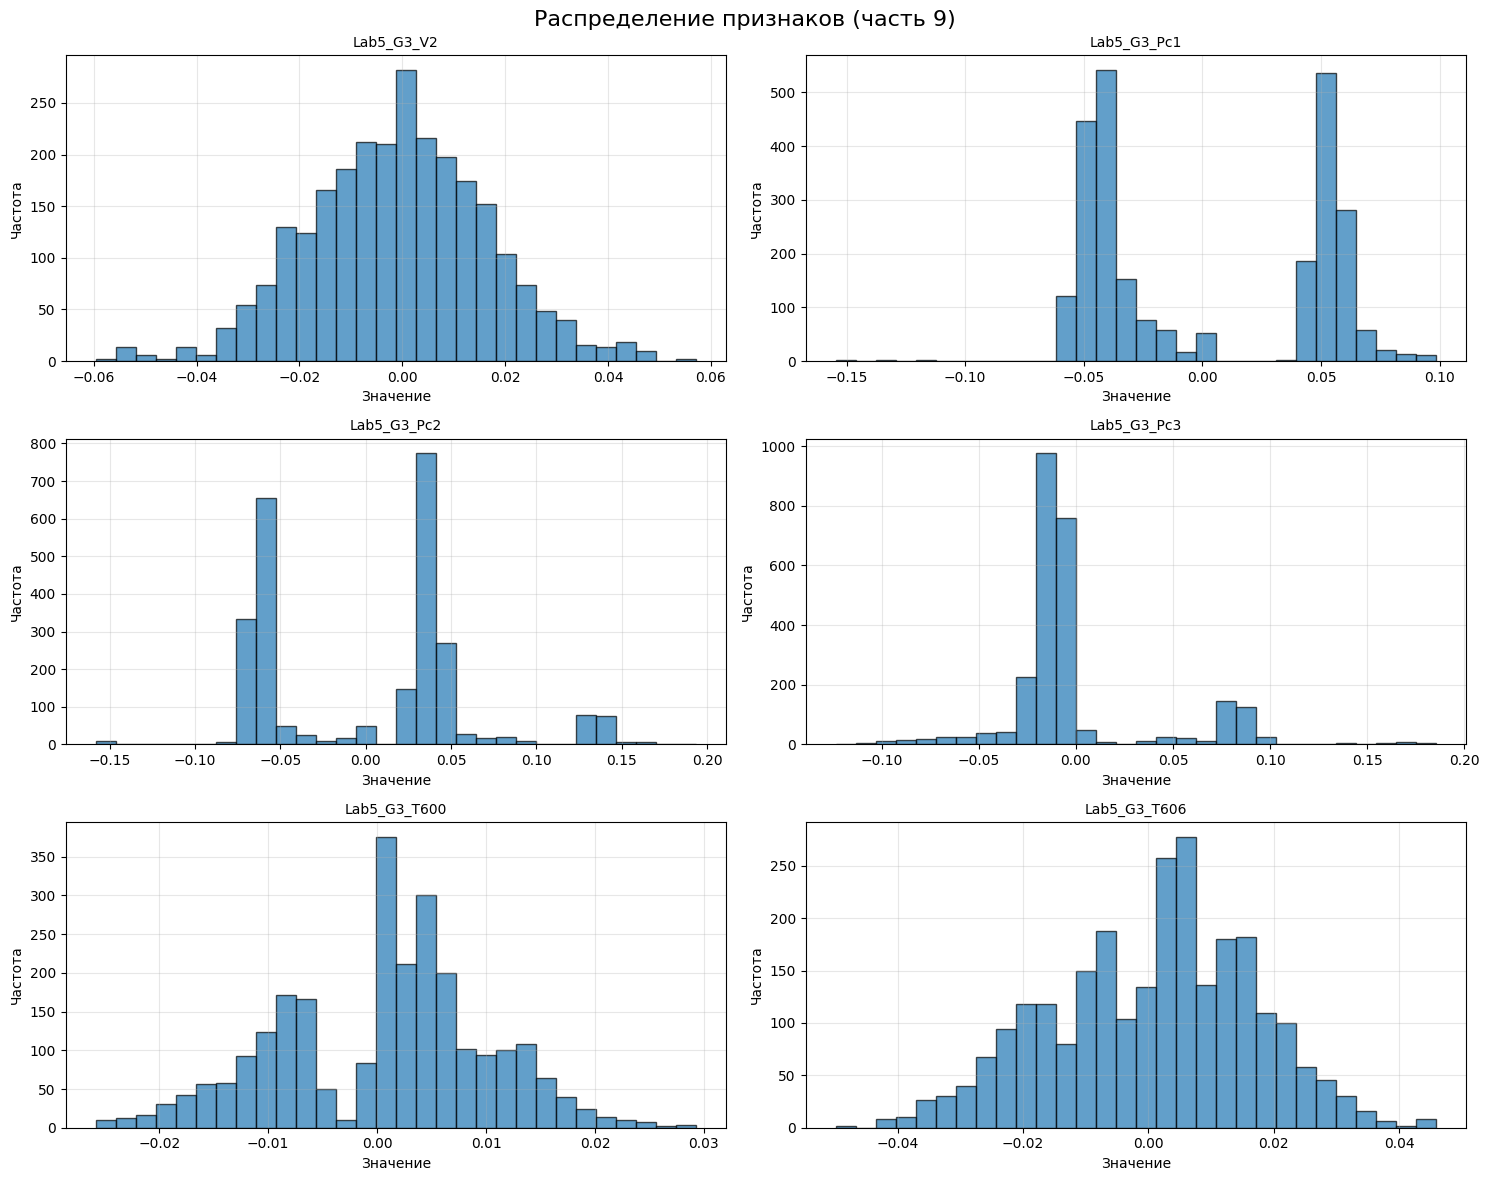

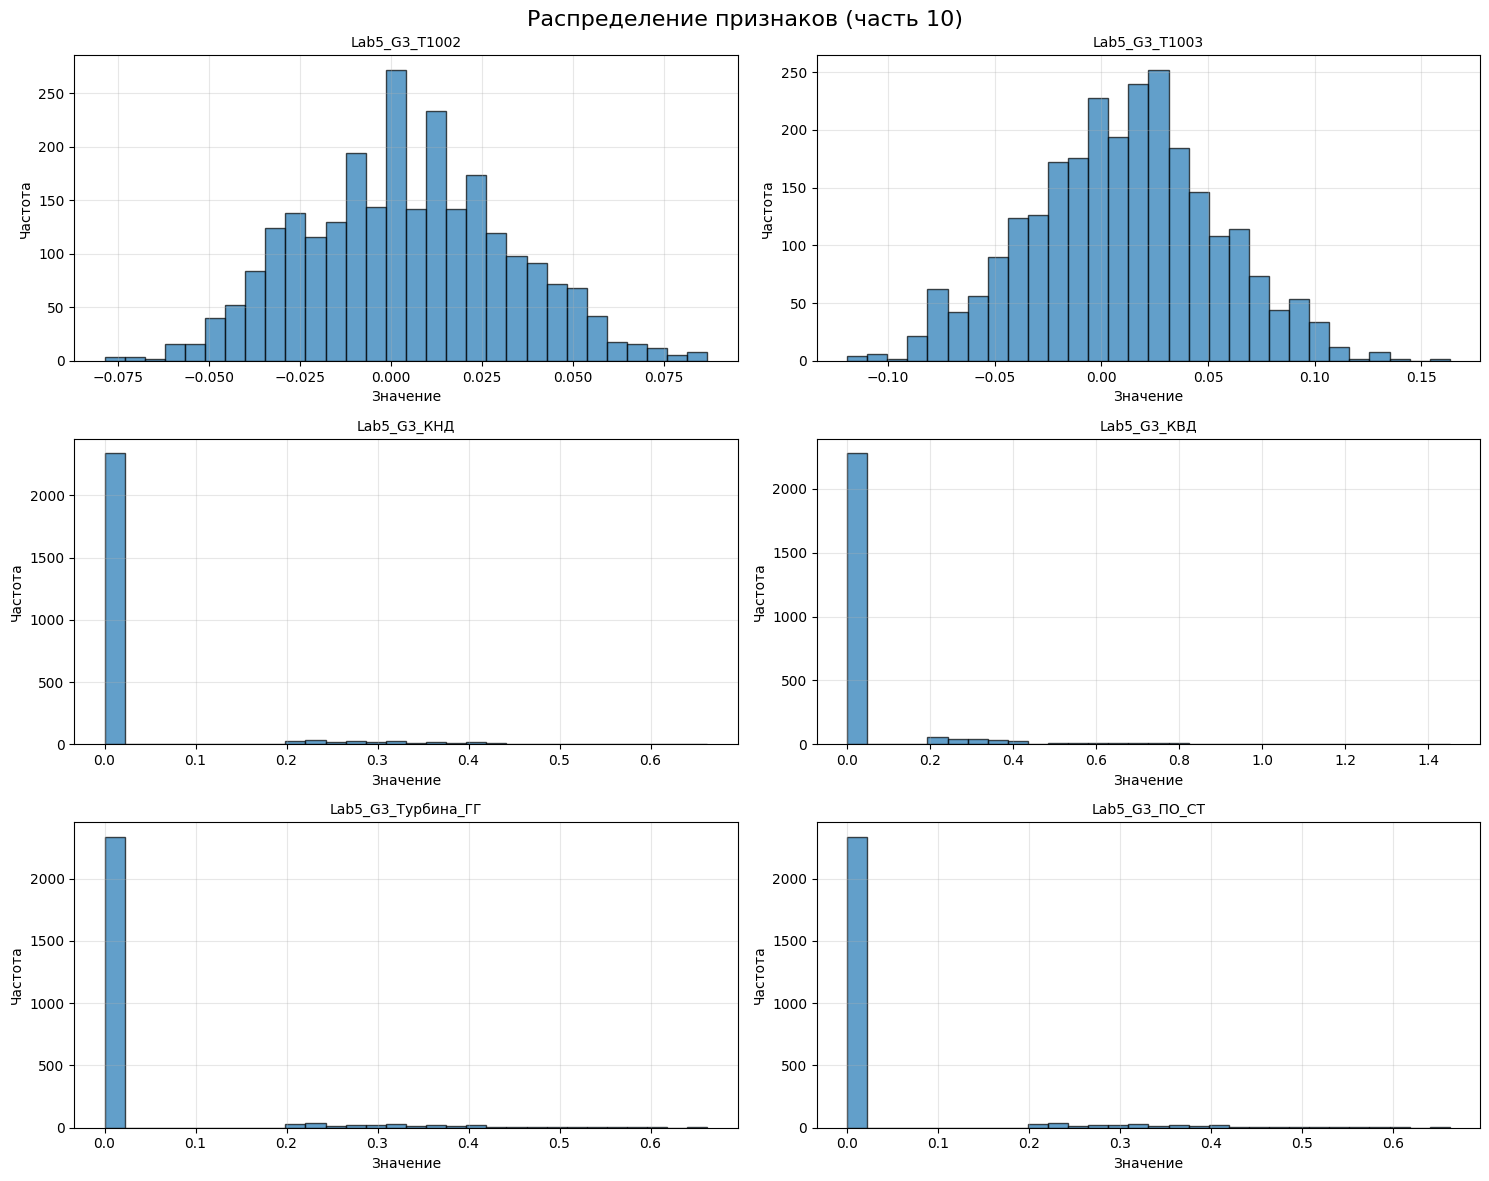

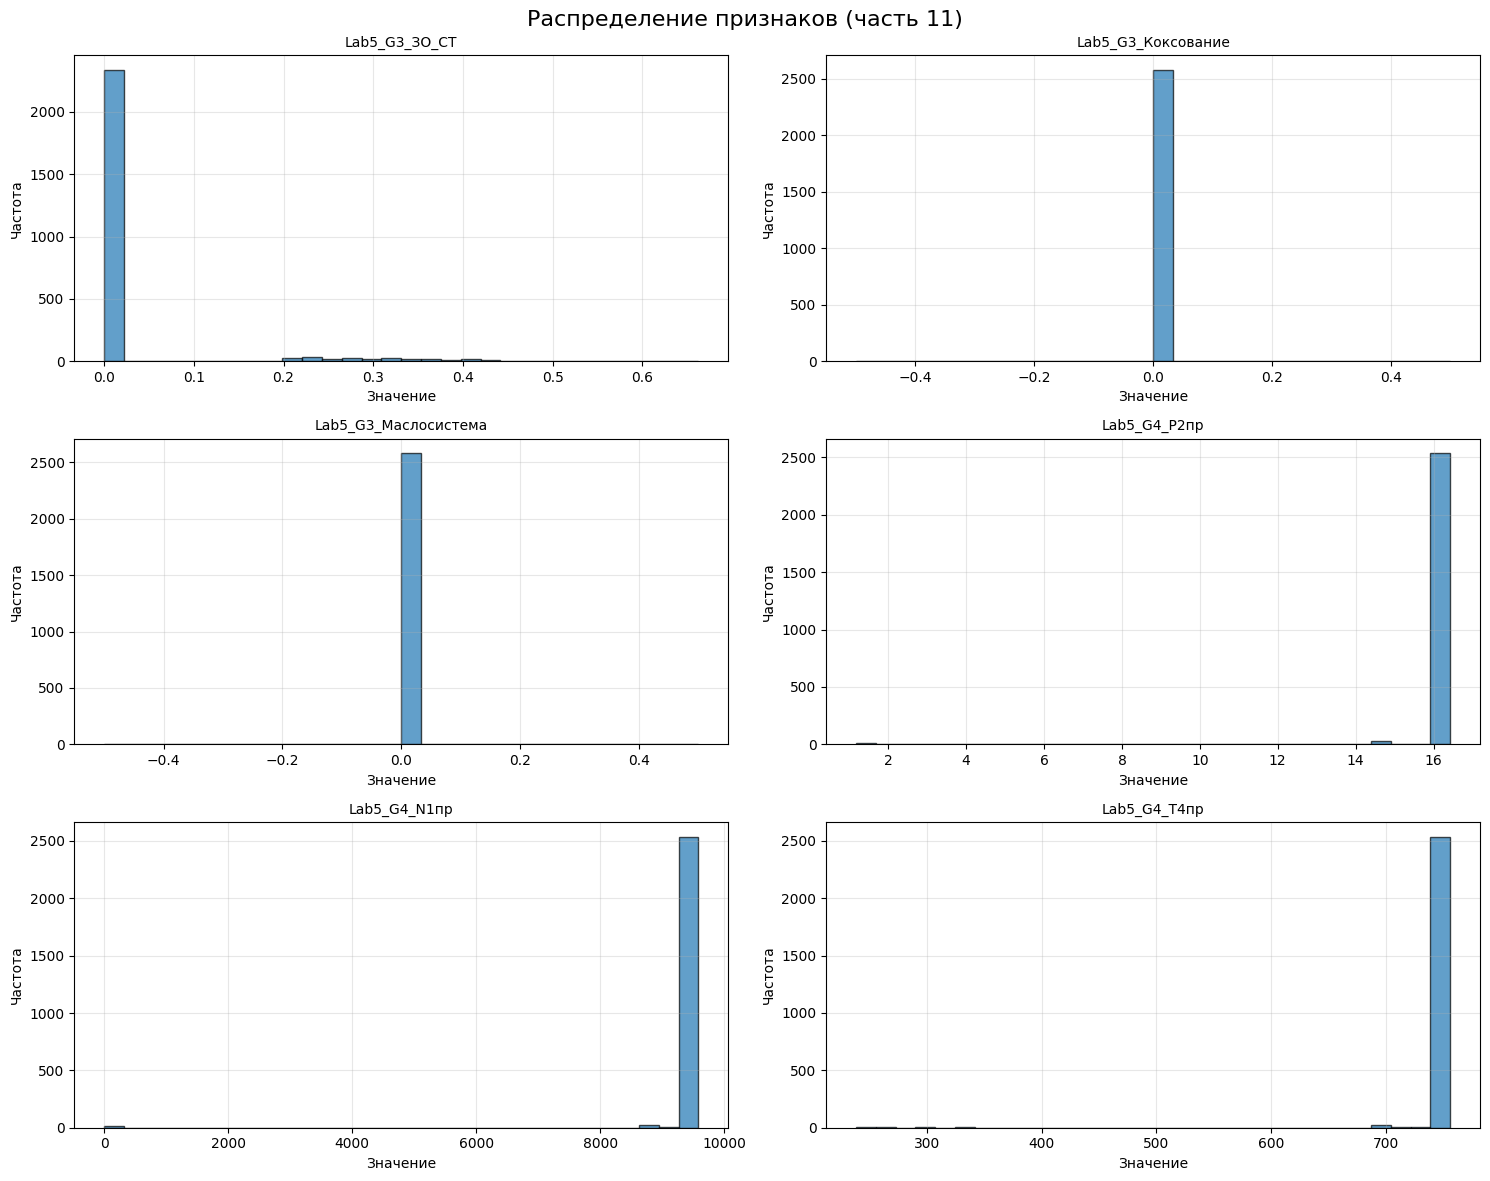

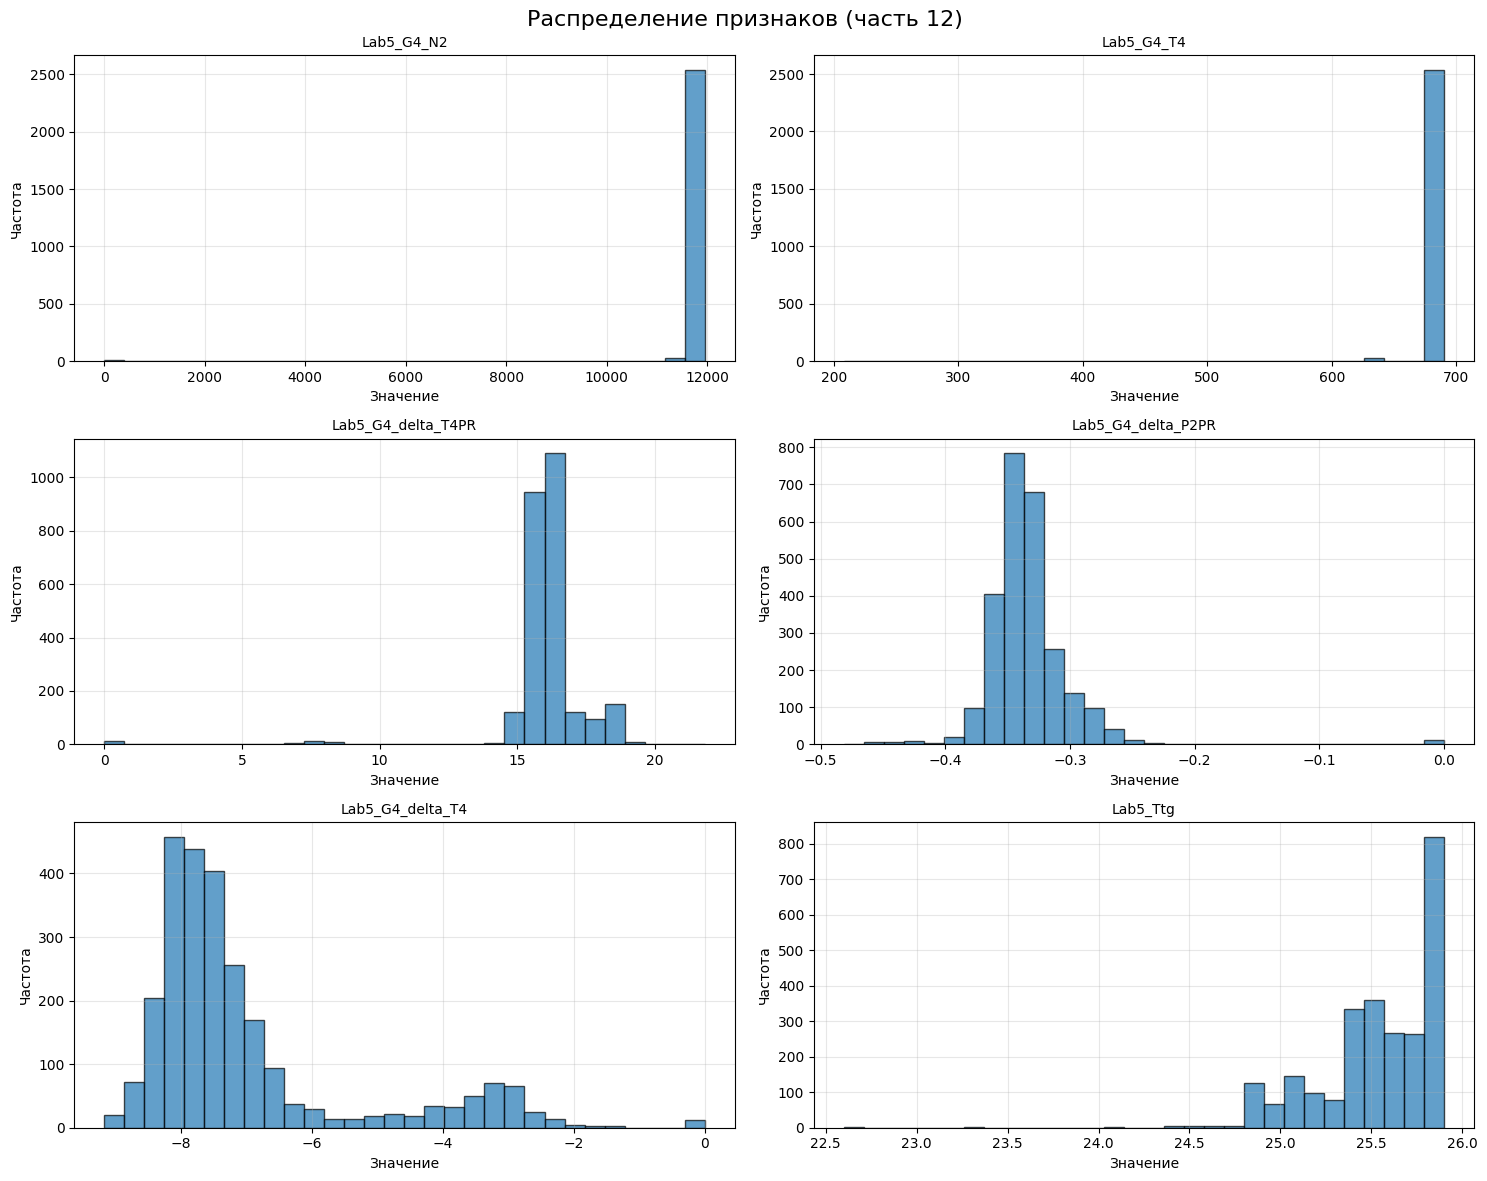

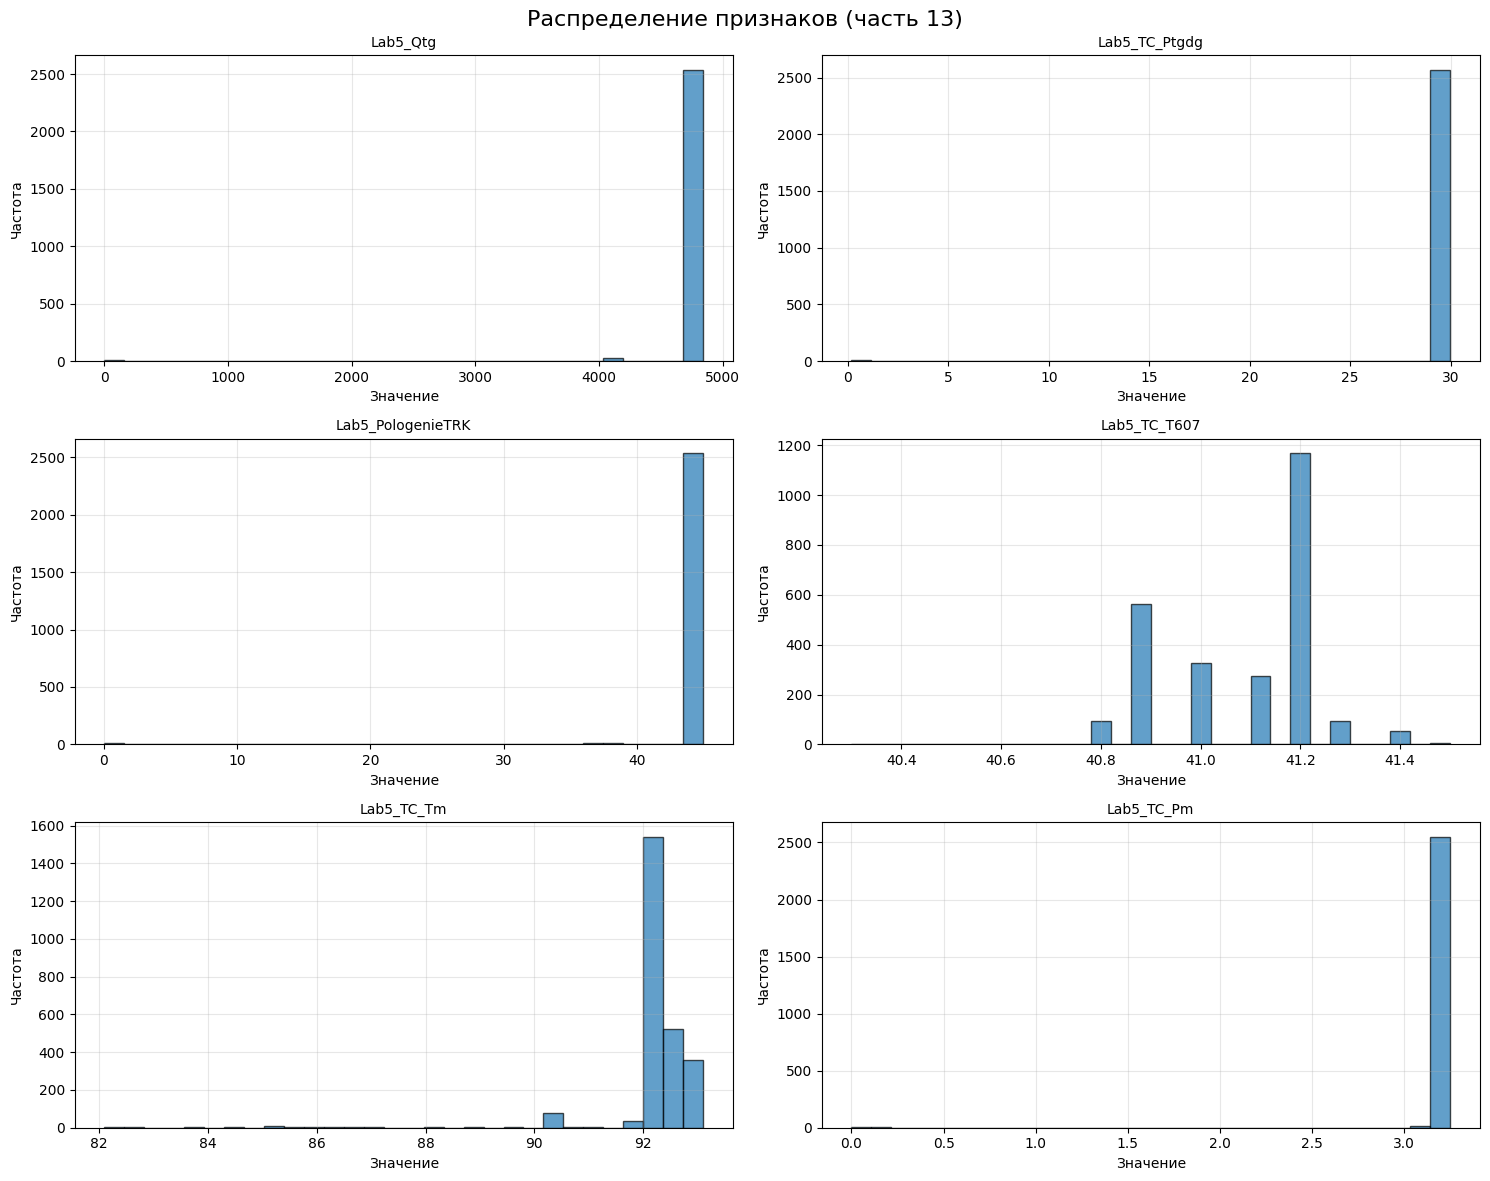

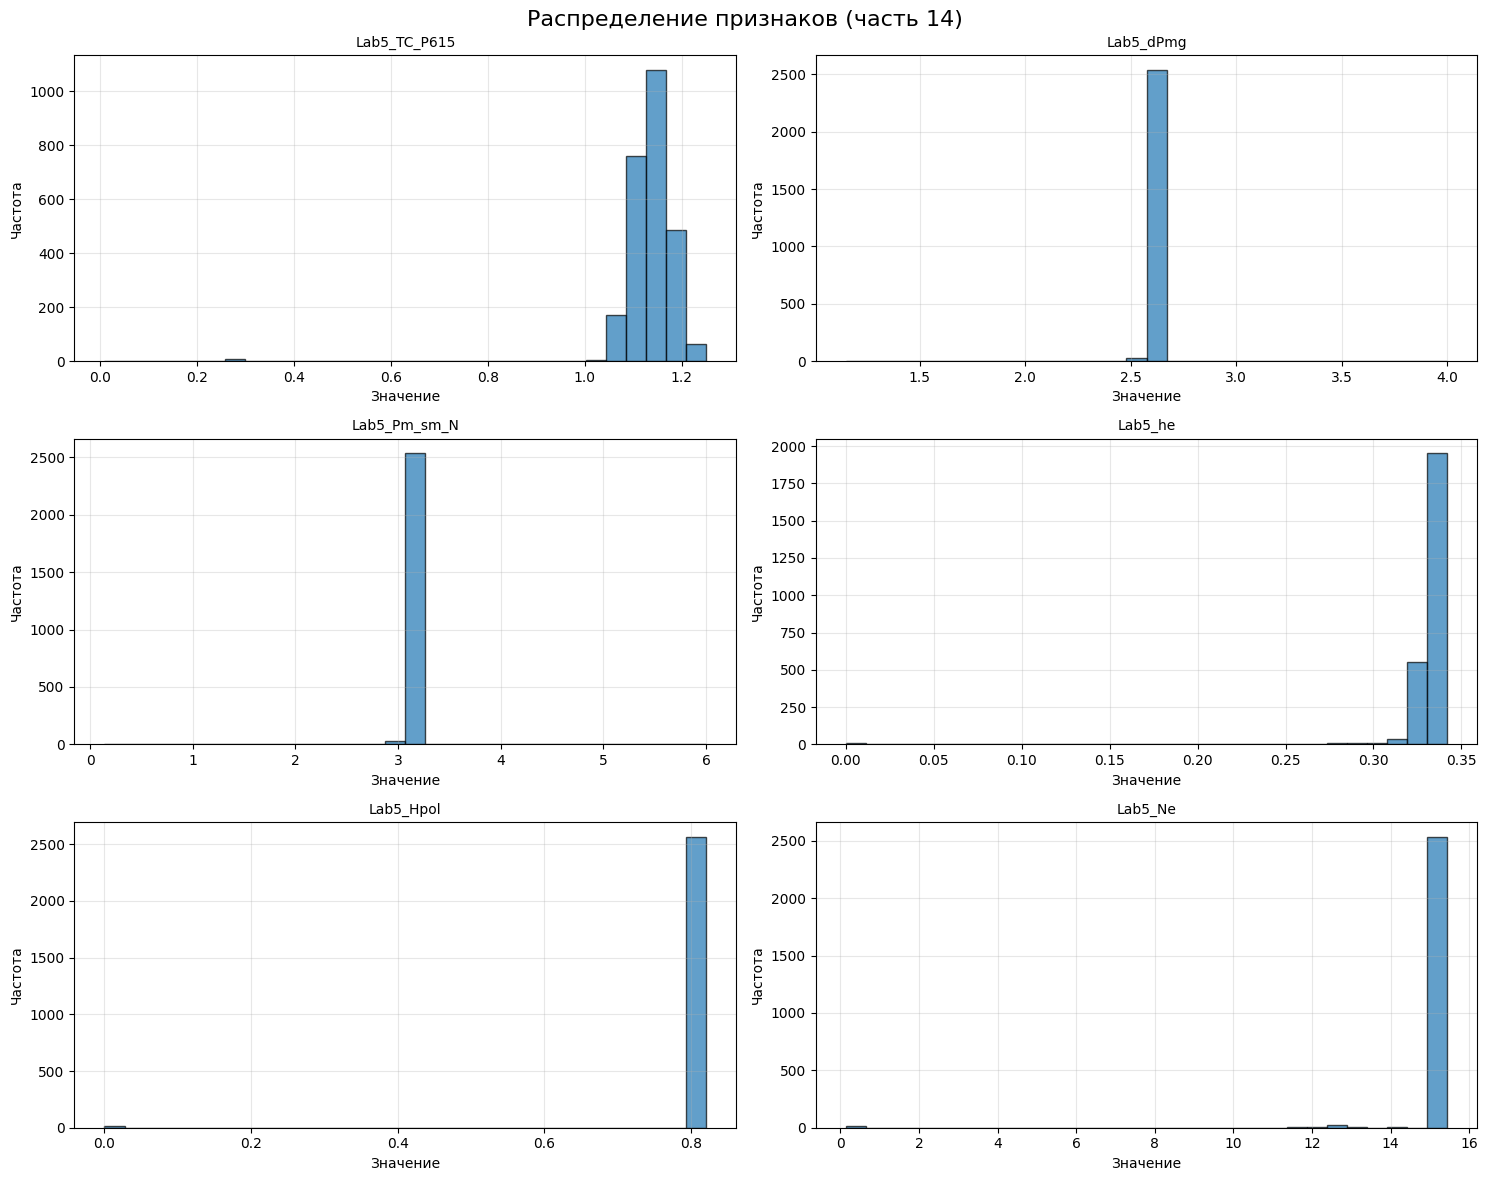

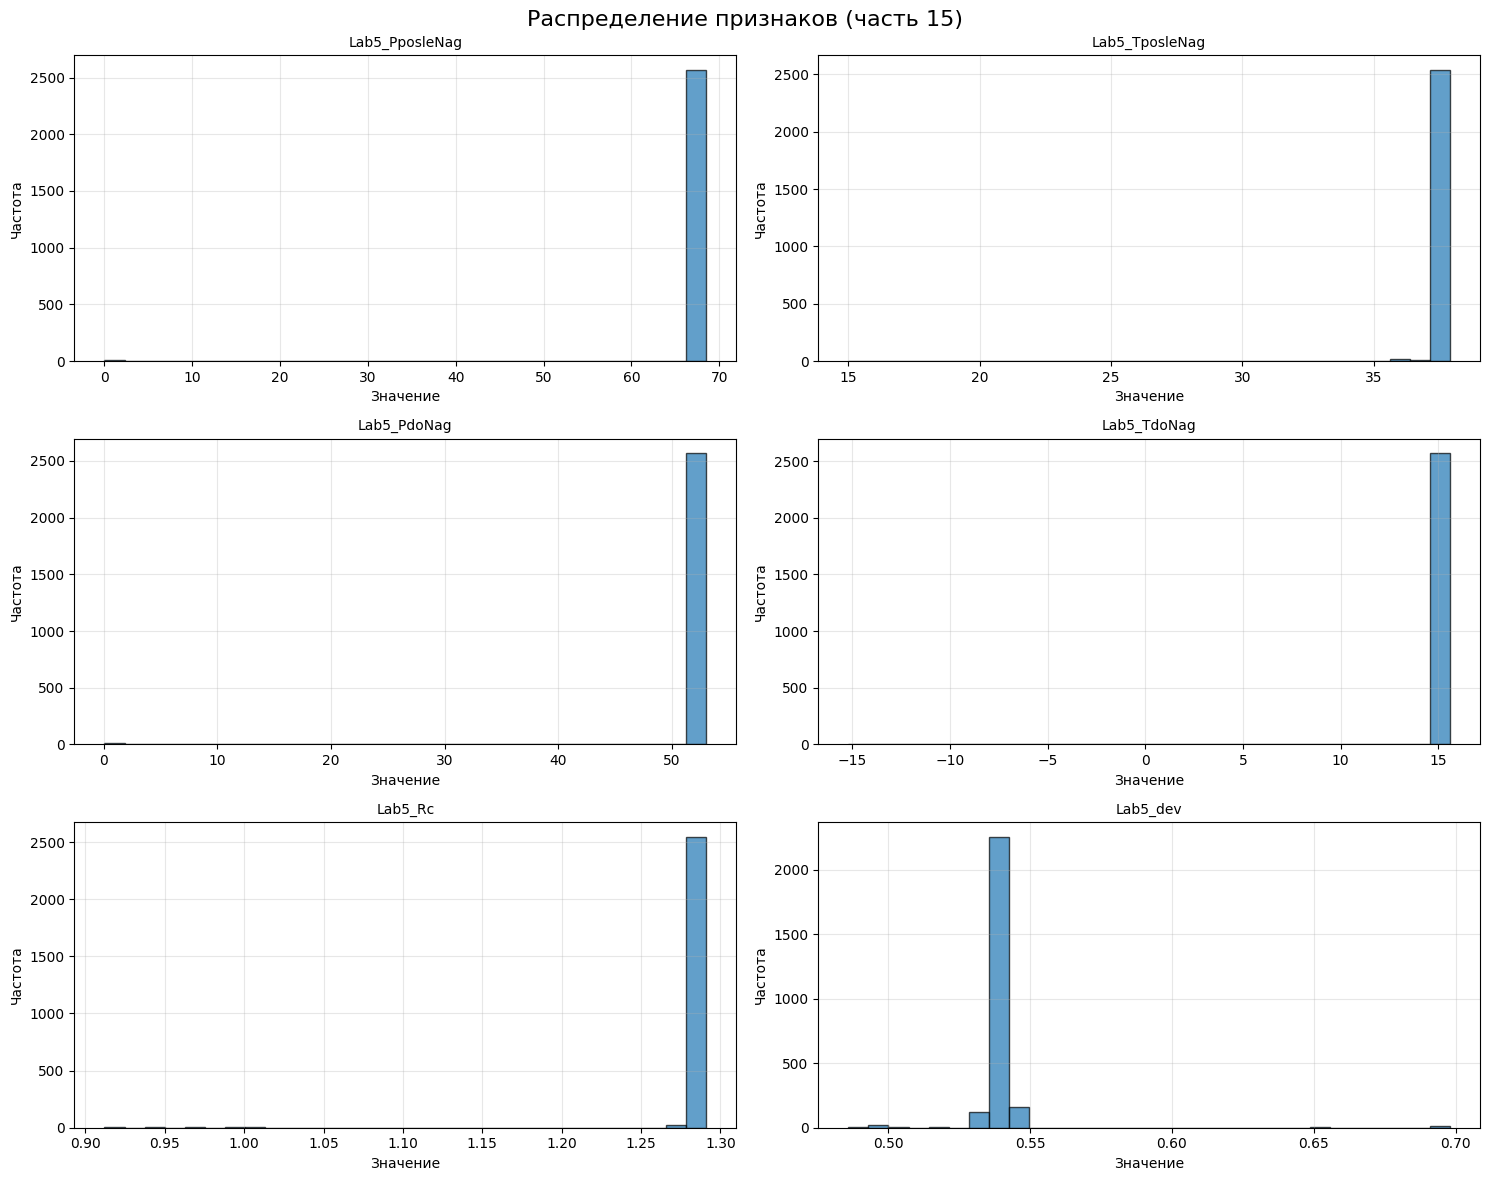

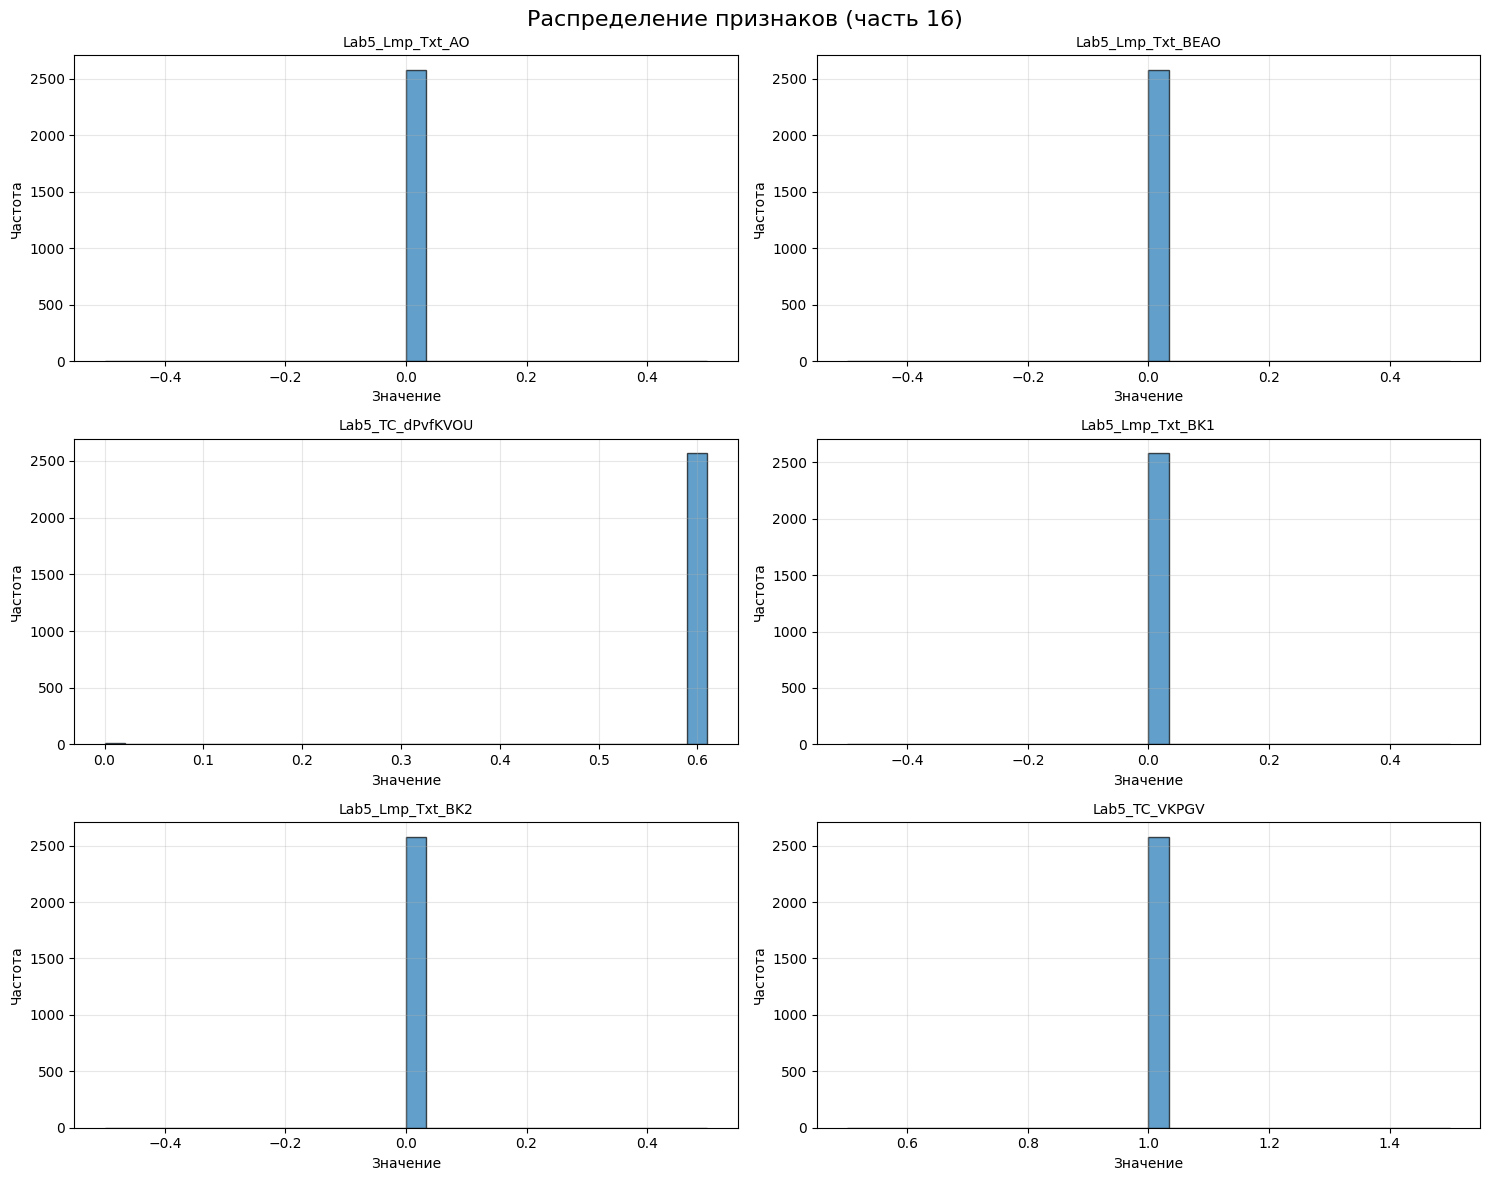

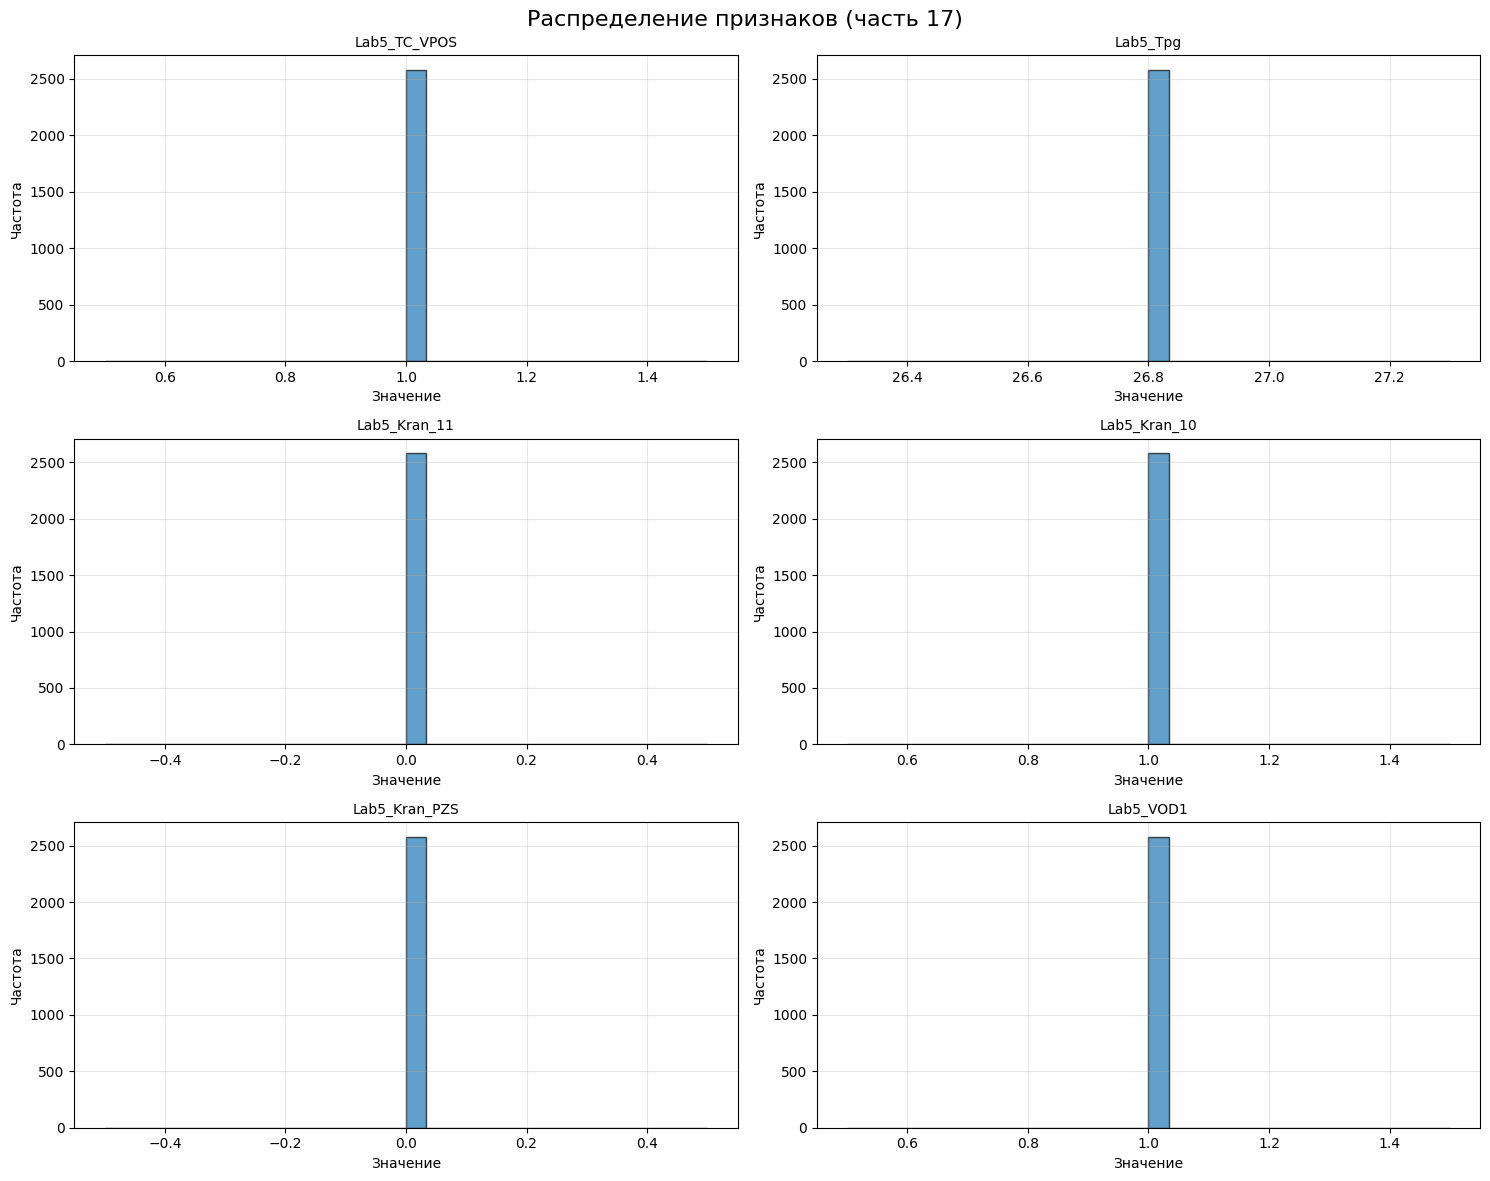

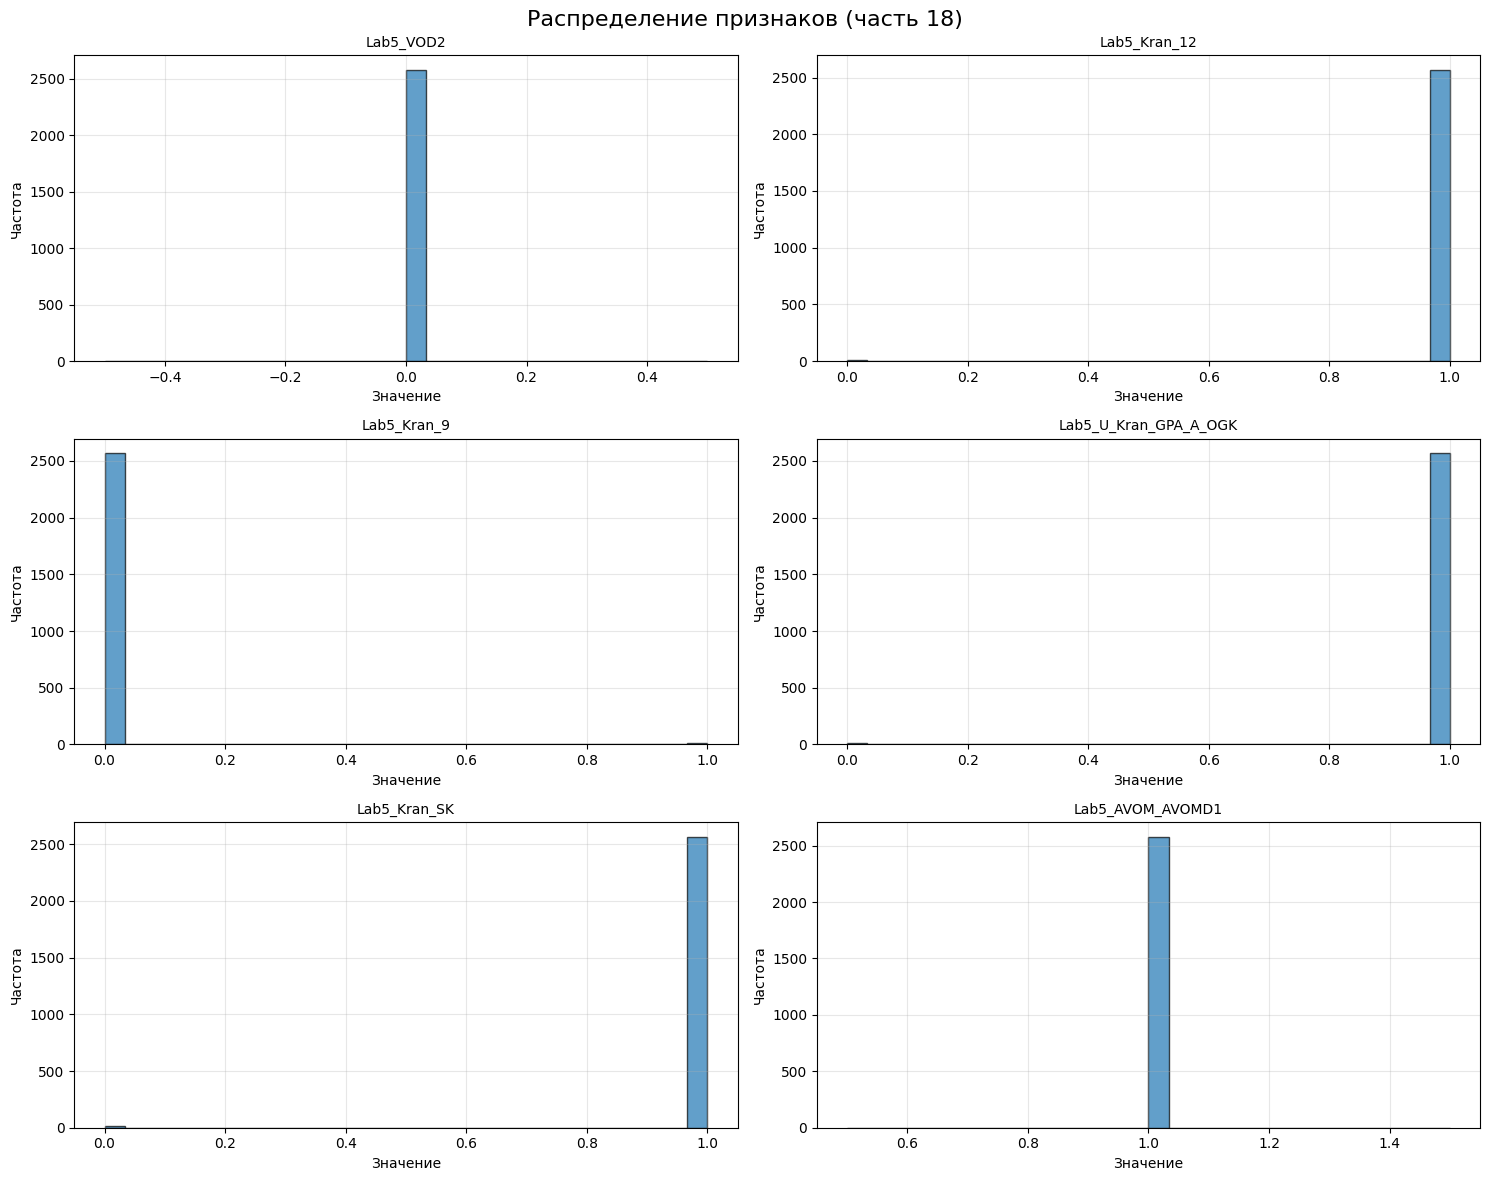

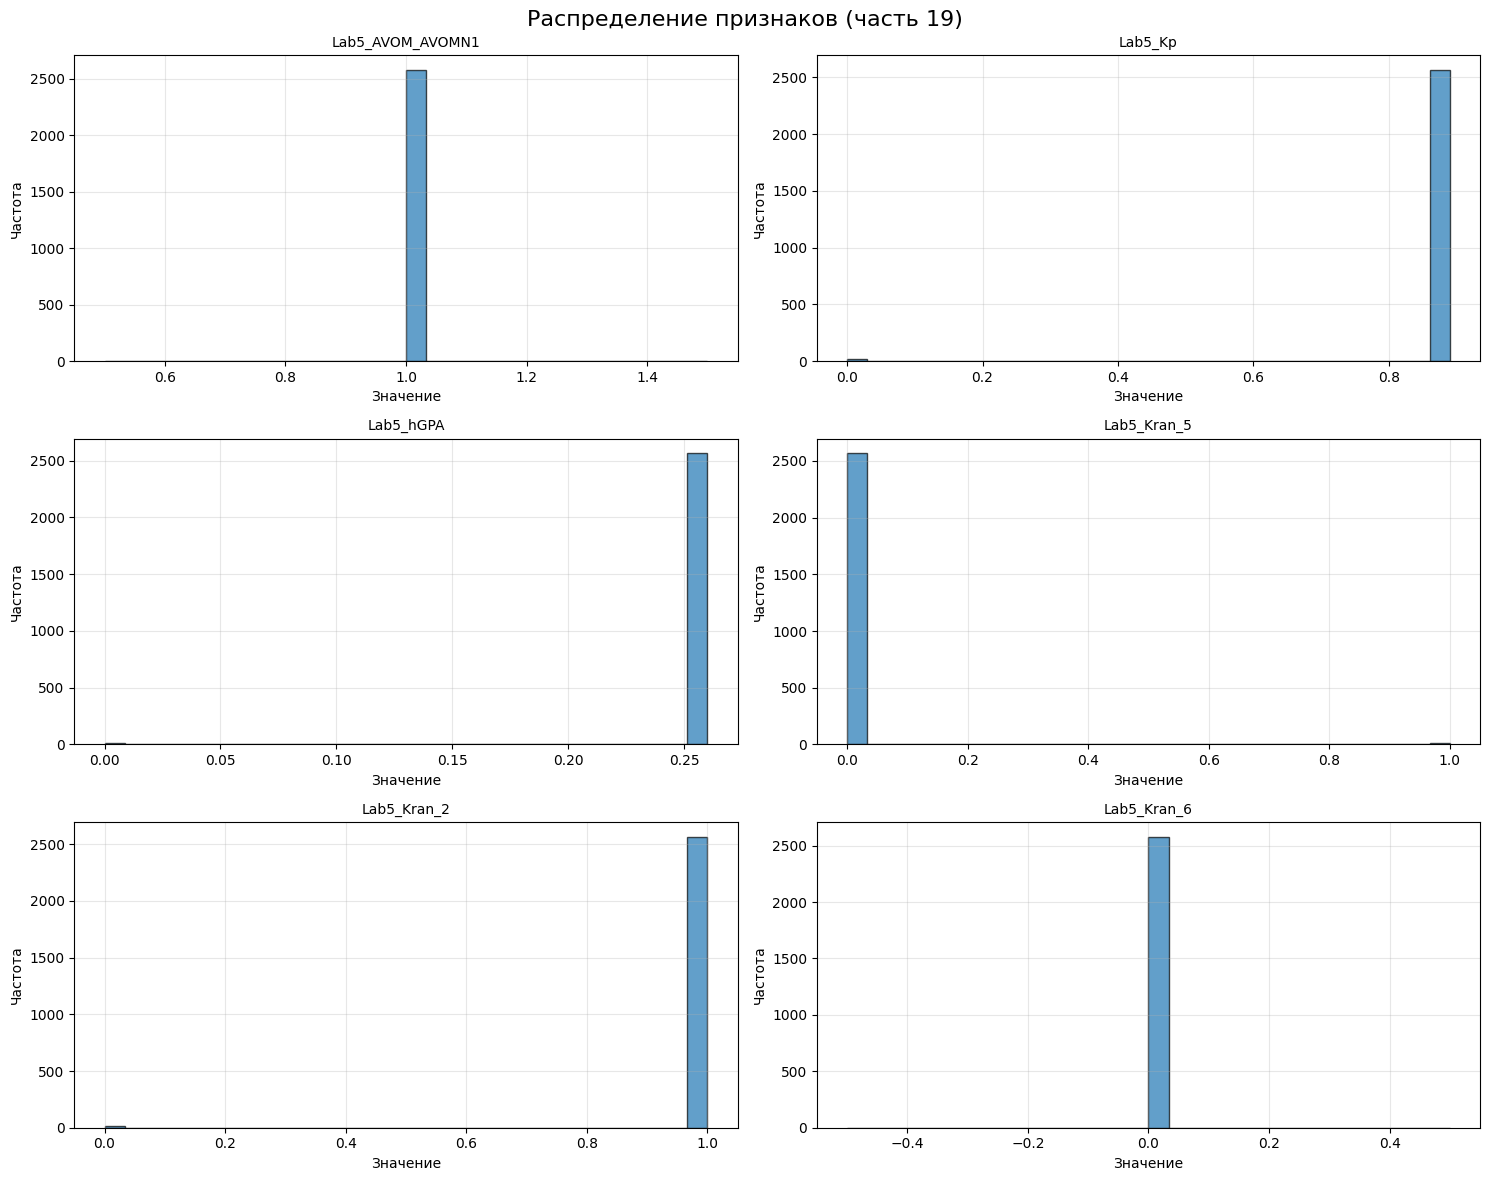

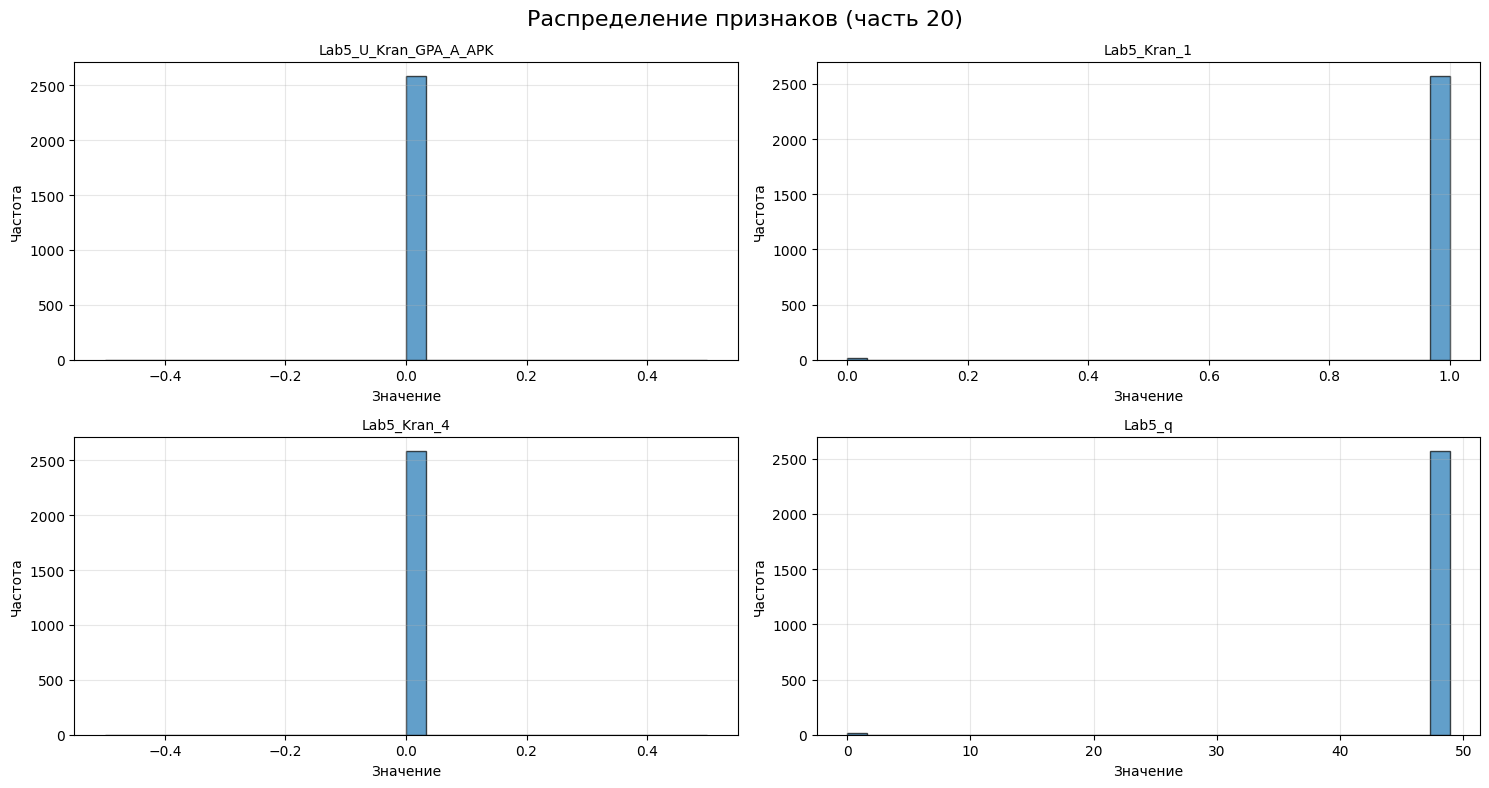

In [27]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(numeric_cols)

plots_per_figure = 6
n_figures = (n_cols + plots_per_figure - 1) // plots_per_figure  

for fig_num in range(n_figures):
    start_idx = fig_num * plots_per_figure
    end_idx = min(start_idx + plots_per_figure, n_cols)
    cols_in_figure = numeric_cols[start_idx:end_idx]
    
    # Создаем figure с субплотами
    n_plots = len(cols_in_figure)
    n_rows = (n_plots + 1) // 2  # 2 колонки, 3 строки для 6 графиков
    n_cols_grid = 2
    
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(15, 4*n_rows))
    fig.suptitle(f'Распределение признаков (часть {fig_num+1})', fontsize=16)
    
    # Выравниваем оси в одномерный массив для удобства
    axes_flat = axes.flatten() if n_plots > 1 else [axes]
    
    for idx, col in enumerate(cols_in_figure):
        axes_flat[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes_flat[idx].set_title(f'{col}', fontsize=10)
        axes_flat[idx].set_xlabel('Значение')
        axes_flat[idx].set_ylabel('Частота')
        axes_flat[idx].grid(True, alpha=0.3)
    
    # Скрываем пустые субплоты
    for idx in range(len(cols_in_figure), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## Проверка на выделение главных компонент

In [34]:
df_cleaned.drop(columns=['row']).to_numpy().shape

(2580, 95)

In [41]:
cleaned_numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

In [42]:
from sklearn.decomposition import PCA

# X = df[numeric_cols].values
X = df_cleaned[cleaned_numeric_cols].values
pca = PCA(n_components='mle')
X_pca = pca.fit_transform(X)

In [43]:
X.shape

(2580, 95)

In [39]:
pca.n_components_

83

In [44]:
np.cumsum(pca.explained_variance_ratio_)

array([0.80797126, 0.9979853 , 0.9997528 , 0.99995033, 0.99997271,
       0.99998982, 0.99999474, 0.99999819, 0.99999885, 0.99999935,
       0.99999953, 0.99999966, 0.99999974, 0.99999981, 0.99999985,
       0.99999987, 0.99999989, 0.9999999 , 0.99999991, 0.99999992,
       0.99999993, 0.99999994, 0.99999995, 0.99999995, 0.99999995,
       0.99999996, 0.99999996, 0.99999997, 0.99999997, 0.99999997,
       0.99999997, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999999, 0.99999999,
       0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999,
       0.99999999, 0.99999999, 0.99999999, 0.99999999, 0.99999999,
       0.99999999, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [17]:
X_sub = X_pca[:, :4]

In [18]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import nolds # Библиотека для нелинейной динамики

def analyze_series(series):
    results = {}
    
    # 1. Стационарность (ADF)
    adf_res = adfuller(series.dropna())
    results['is_stationary'] = adf_res[1] < 0.05
    
    # 2. Персистентность (Hurst Exponent)
    # Используем nolds для вычисления
    results['hurst'] = nolds.hurst_rs(series.dropna())
    
    # 3. Хаотичность (Lyapunov Exponent)
    # Положительный результат указывает на хаос
    try:
        results['lyapunov'] = nolds.lyap_r(series.dropna(), emb_dim=3)
    except:
        results['lyapunov'] = None
        
    return results

# Пример для одного из 119 признаков
# feature_info = analyze_series(df['feature_1'])

In [19]:
def simple_analysis_and_plot(X_sub):
    for i in range(X_sub.shape[1]):
        print(analyze_series(pd.Series(X_sub[:, i])))
        plt.plot(np.arange(X_sub.shape[0]), X_sub[:, i])
        plt.show()

{'is_stationary': False, 'hurst': 0.7841570916230818, 'lyapunov': 0.005868834626936586}


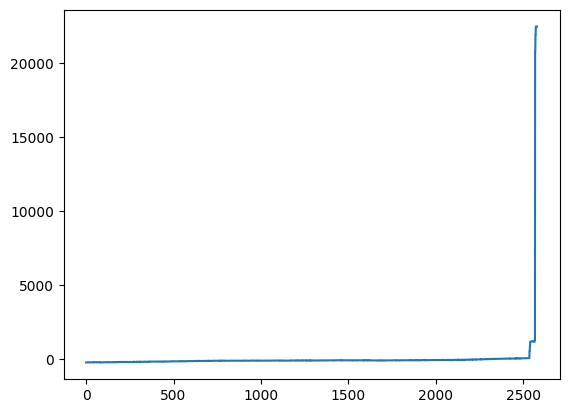

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\nolds\measures.py:263: RuntimeWarning: signal has very low mean frequency, setting min_tsep = 645
  warnings.warn(msg.format(min_tsep), RuntimeWarning)


{'is_stationary': False, 'hurst': 0.9346159092243304, 'lyapunov': 0.0002896087652982686}


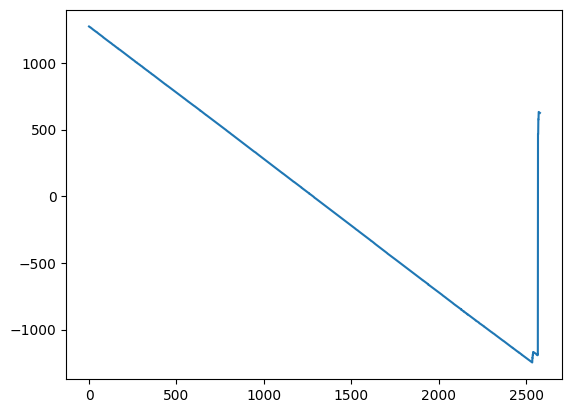

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


{'is_stationary': True, 'hurst': 0.65441270426173, 'lyapunov': 0.004972480319938835}


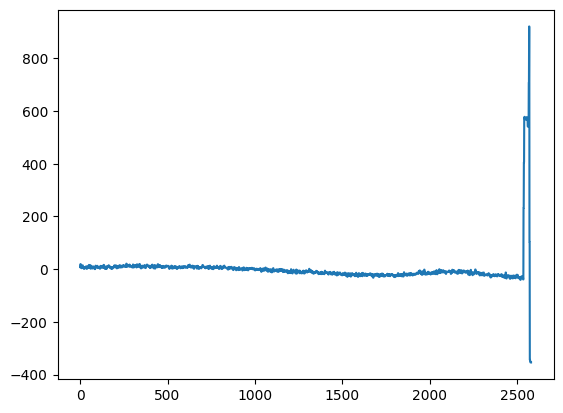

{'is_stationary': True, 'hurst': 0.6143079945951412, 'lyapunov': 0.0020774322897839396}


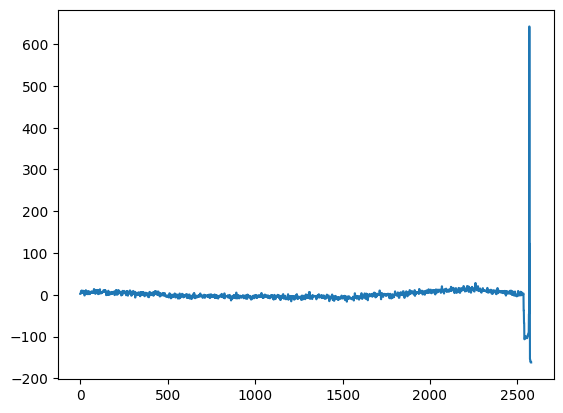

In [20]:
for i in range(X_sub.shape[1]):
    print(analyze_series(pd.Series(X_sub[:, i])))
    plt.plot(np.arange(X_sub.shape[0]), X_sub[:, i])
    plt.show()

In [21]:
sub_df = pd.DataFrame(X_sub, columns=[f"PC{i + 1}" for i in range(X_sub.shape[1])])
sub_df

,PC1,PC2,PC3,PC4
0,-248.883377,1273.024983,7.820365,2.365970
1,-248.798576,1272.028806,7.802016,2.363235
2,-246.517062,1270.990021,19.254397,2.822582
3,-246.432261,1269.993845,19.236048,2.819847
4,-249.130311,1268.980962,6.617840,8.574675
...,...,...,...,...
2575,22470.587521,629.161274,-349.588440,-158.167106
2576,22468.852762,627.952020,-354.027363,-161.776439
2577,22468.937563,626.955843,-354.045712,-161.779174
2578,22469.019880,625.959481,-354.045291,-161.740913


## Проверка на стационарность

In [22]:
def run_foreach(dfs: list[pd.DataFrame], func):
    return [func(df) for df in dfs]

In [23]:
cl_numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
df_cleaned_num = df_cleaned[cl_numeric_cols]

In [24]:
dfs = [df_cleaned_num, sub_df]

In [25]:
analysis = df_cleaned_num.apply(analyze_series)

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\nolds\measures.py:263: RuntimeWarning: signal has very low mean frequency, setting min_tsep = 645
  warnings.warn(msg.format(min_tsep), RuntimeWarning)
c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\nolds\measures.py:292: RuntimeWarning: autocorrelation declined too slowly to find suitable lag, setting lag to 625
  warnings.warn(msg.format(lag), RuntimeWarning)
c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\nolds\measures.py:263: RuntimeWarning: signal has very low mean frequency, setting min_tsep = 645
  warnings.warn(msg.format(min_tsep), RuntimeWarning)
c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\n

In [26]:
analysis_df = analysis.apply(pd.Series)
analysis_df

,is_stationary,hurst,lyapunov
row,True,0.937090,3.607687e-16
Lab5_G1_N1,False,0.722983,7.447369e-03
Lab5_G1_N2,False,0.813900,7.791327e-03
Lab5_G1_N3,False,0.501436,1.754287e-02
Lab5_G1_P2,False,0.610201,1.495443e-02
...,...,...,...
Lab5_hGPA,False,0.962129,-9.547873e-17
Lab5_Kran_5,False,0.590192,2.404574e-02
Lab5_Kran_2,False,0.590192,0.000000e+00
Lab5_Kran_1,False,0.590192,0.000000e+00


In [27]:
# full_anal = run_foreach(dfs, lambda df: df.apply(analyze_series).apply(pd.Series))
# for res in full_anal:
#     print(res)
#     print('-' * 20)

In [28]:
from statsmodels.tsa.stattools import adfuller, kpss
import nolds
import warnings

def analyze_series_full(series):
    results = {}
    
    # Очищаем данные
    clean_series = series.dropna()
    
    # 1. ADF тест (нулевая гипотеза: нестационарен)
    adf_res = adfuller(clean_series)
    results['adf_statistic'] = adf_res[0]
    results['adf_pvalue'] = adf_res[1]
    results['is_stationary_adf'] = adf_res[1] < 0.05  # Отвергаем нестационарность
    
    # 2. KPSS тест (нулевая гипотеза: стационарен)
    try:
        kpss_res = kpss(clean_series, regression='c', nlags='auto')
        results['kpss_statistic'] = kpss_res[0]
        results['kpss_pvalue'] = kpss_res[1]
        results['is_stationary_kpss'] = kpss_res[1] >= 0.05  # Не отвергаем стационарность
    except Exception as e:
        results['kpss_statistic'] = None
        results['kpss_pvalue'] = None
        results['is_stationary_kpss'] = None
        results['kpss_error'] = str(e)
    
    # 3. Совместный вывод о стационарности
    if results['is_stationary_adf'] and results['is_stationary_kpss']:
        results['stationarity_consensus'] = 'stationary'
    elif not results['is_stationary_adf'] and not results['is_stationary_kpss']:
        results['stationarity_consensus'] = 'non_stationary'
    elif results['is_stationary_adf'] and not results['is_stationary_kpss']:
        results['stationarity_consensus'] = 'trend_stationary'  # Стационарен вокруг тренда
    else:
        results['stationarity_consensus'] = 'inconclusive'
    
    # 4. Персистентность (Hurst Exponent)
    # H < 0.5: антиперсистентность (mean-reverting)
    # H = 0.5: случайное блуждание
    # H > 0.5: персистентность (трендоустойчивый)
    try:
        results['hurst'] = nolds.hurst_rs(clean_series)
    except:
        results['hurst'] = None
    
    # Интерпретация Hurst
    if results['hurst'] is not None:
        if results['hurst'] < 0.5:
            results['hurst_interpretation'] = 'mean_reverting'
        elif results['hurst'] > 0.5:
            results['hurst_interpretation'] = 'persistent_trending'
        else:
            results['hurst_interpretation'] = 'random_walk'
    else:
        results['hurst_interpretation'] = None
    
    # 5. Хаотичность (Lyapunov Exponent)
    # Положительный: хаотическая динамика
    # Ноль или отрицательный: детерминированная/периодическая
    try:
        results['lyapunov'] = nolds.lyap_r(clean_series, emb_dim=3)
        results['is_chaotic'] = results['lyapunov'] > 0 if results['lyapunov'] is not None else None
    except:
        results['lyapunov'] = None
        results['is_chaotic'] = None
    
    return results

In [29]:
# full_df = df_cleaned_num.apply(analyze_series_full).apply(pd.Series)
# full_df

In [30]:
def analyze_and_print_results(dfs, analyzer, stat_cols):
    full_anal = run_foreach(dfs, lambda df: df.apply(analyzer).apply(pd.Series))
    for res in full_anal:
        print(res)
        print('Non-stationary count: ', ', '.join([str((res[sc] == True).sum()) for sc in stat_cols]))
        print('-' * 20)

In [31]:
# full_anal = run_foreach(dfs, lambda df: df.apply(analyze_series_full).apply(pd.Series))
# for res in full_anal:
#     print(res)
#     print('-' * 20)

## Приведение ряда к стационарности

In [32]:
def make_stationary_df(df):
    new_df = pd.DataFrame(index=df.index)
    
    for col in df.columns:
        # Шаг 1: Убираем гетероскедастичность (логарифм)
        # Если есть отрицательные значения, делаем сдвиг
        shifted_series = df[col] - df[col].min() + 1
        log_series = np.log(shifted_series)
        
        # Шаг 2: Дифференцируем (убираем тренд)
        stationary_series = log_series.diff().dropna()
        
        new_df[f'{col}_stat'] = stationary_series
        
    return new_df

In [33]:
sub_dfs = [dfs[1]]

In [34]:
stat_dfs = run_foreach(sub_dfs, make_stationary_df)

In [35]:
analyze_and_print_results(sub_dfs, analyze_series, ['is_stationary'])

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\nolds\measures.py:263: RuntimeWarning: signal has very low mean frequency, setting min_tsep = 645
  warnings.warn(msg.format(min_tsep), RuntimeWarning)


     is_stationary     hurst  lyapunov
PC1          False  0.857645  0.005869
PC2          False  0.934616  0.000290
PC3           True  0.654413  0.004972
PC4           True  0.614308  0.000265
Non-stationary count:  2
--------------------


c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [36]:
analyze_and_print_results(stat_dfs, analyze_series, ['is_stationary'])

          is_stationary     hurst  lyapunov
PC1_stat           True  0.196784  0.003483
PC2_stat           True  0.315567  0.011984
PC3_stat           True  0.162721 -0.000881
PC4_stat           True  0.183078  0.003449
Non-stationary count:  4
--------------------


{'is_stationary': True, 'hurst': 0.19678415690215018, 'lyapunov': 0.0018557886753960177}


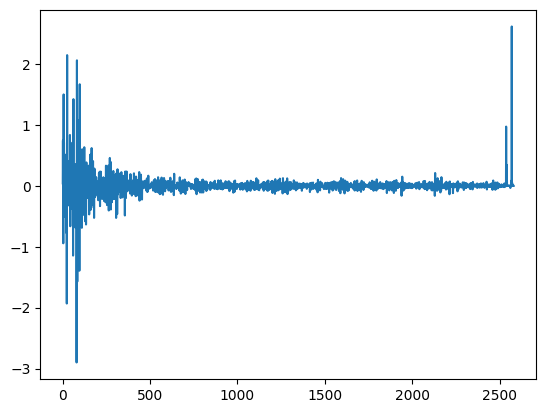

{'is_stationary': True, 'hurst': 0.32071740663044224, 'lyapunov': 0.012094422132611915}


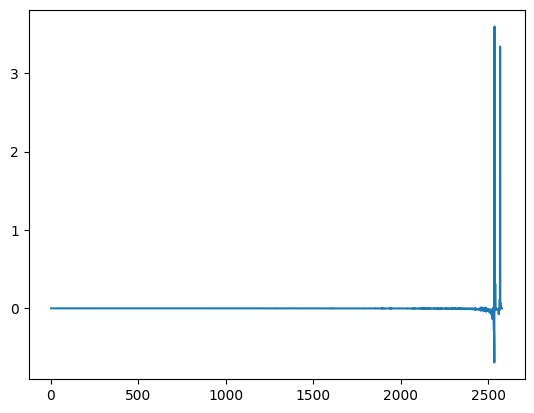

{'is_stationary': True, 'hurst': 0.1627206730267699, 'lyapunov': -0.000541801187885224}


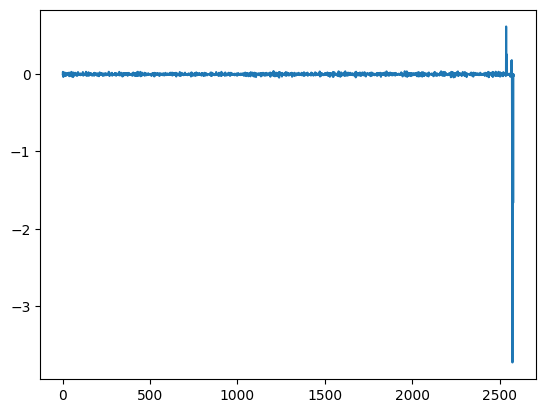

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


{'is_stationary': True, 'hurst': 0.18307769343176322, 'lyapunov': 0.0034494097755600165}


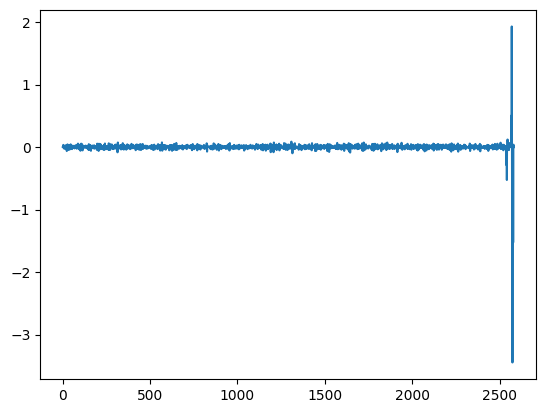

In [37]:
simple_analysis_and_plot(stat_dfs[0].to_numpy())

## Вложение временного ряда

In [4]:
from juliacall import Main as jl

jl.seval("""
using Pkg
""")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [5]:
from juliacall import Main as jl

jl.seval("""
using DynamicalSystems
using DelayEmbeddings
using ComplexityMeasures
using Statistics
""")

In [9]:
x_ = df["Lab5_G1_N1"].to_numpy(dtype=np.float64)

In [6]:
jl.x = df["Lab5_G1_N1"].to_numpy(dtype=np.float64)

In [15]:
x_flat = np.asarray(x_).flatten()

# Передаем в Julia
jl.x_flat = x_flat

In [ ]:
1+1

In [ ]:
jl.seval("""
function custom_delay_fnn(s::AbstractVector, τ::Int, ds = 2:6; rtol=10.0, atol=2.0)
    rtol2 = rtol^2
    Ra = std(s, corrected=false)
    nfnn = zeros(length(ds))
    @inbounds for (k, d) ∈ enumerate(ds)
        y = embed(s[1:end-τ],d,τ)
        tree = KDTree(y)
        _nind = bulkisearch(tree, y, NeighborNumber(1), Theiler(0))
        nind = (x[1] for x in _nind) # bulksearch always returns vectors of vectors
        # nind = (x = NearestNeighbors.knn(tree, y.data, 2)[1]; [ind[1] for ind in x])
        for (i,j) ∈ enumerate(nind)
            δ = norm(y[i]-y[j], 2)
            # If y[i] and y[j] are still identical, choose the next nearest neighbor
            # as in Cao's algorithm (not suggested by Kennel, but still advisable)
            if δ == 0.0
                j = Neighborhood.knn(tree, y[i], 2, Theiler(0)(i))[end]
                δ = norm(y[i]-y[j])
            end
            δ1 = _increase_distance(δ,s,i,j,d-1,τ,Euclidean())
            cond_1 = ((δ1/δ)^2 - 1 > rtol2) # equation (4) of Kennel
            cond_2 = (δ1/Ra > atol)         # equation (5) of Kennel
            if cond_1 | cond_2
                nfnn[k] += 1
            end
        end
        nfnn[k] /= length(nind)
    end
    return nfnn
end
""")

In [23]:
jl.x_raw = x_

result = jl.seval("""
# 1. vec(x_raw) вытягивает данные в одномерную структуру
# 2. Float64.(...) выполняет широковещательное копирование элементов в примитивный тип
# 3. collect(...) принудительно собирает это в стандартный, чистый Vector{Float64} в памяти Julia
x_native = collect(Float64.(vec(x_raw)))

optimal_separated_de(
    x_native,
    "fnn",
    "mi_min";
    τs = 1:100,
    dmax = 20
)
""")

JuliaError: BoundsError: attempt to access 2577-element Vector{SVector{1, Float64}} at index [[0.0, 0.0]]
Stacktrace:
  [1] throw_boundserror(A::Vector{SVector{1, Float64}}, I::Tuple{Vector{Float64}})
    @ Base .\essentials.jl:14
  [2] checkbounds
    @ .\abstractarray.jl:699 [inlined]
  [3] _getindex
    @ .\multidimensional.jl:914 [inlined]
  [4] getindex(A::Vector{SVector{1, Float64}}, I::Vector{Float64})
    @ Base .\abstractarray.jl:1312
  [5] getindex
    @ C:\Users\Максим\.julia\packages\StateSpaceSets\wnc9y\src\statespaceset.jl:0 [inlined]
  [6] delay_fnn(s::Vector{Float64}, τ::Int64, ds::UnitRange{Int64}; rtol::Float64, atol::Float64)
    @ DelayEmbeddings C:\Users\Максим\.julia\packages\DelayEmbeddings\AV1Ee\src\separated_de\estimate_dimension.jl:174
  [7] delay_fnn
    @ C:\Users\Максим\.julia\packages\DelayEmbeddings\AV1Ee\src\separated_de\estimate_dimension.jl:158 [inlined]
  [8] optimal_separated_de(s::Vector{Float64}, dimensionmethod::String, delaymethod::String; fnn_th

In [21]:
1 + 1

2

### Равномерное вложение

#### Задержка

##### Автокорреляция

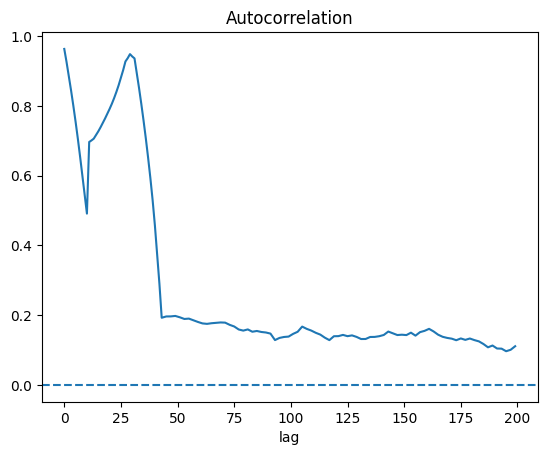

In [41]:
acf = jl.seval("""
using Statistics

function autocorr_delay(x, maxlag)
    ac = [cor(x[1:end-l], x[1+l:end]) for l in 1:maxlag]
    return ac
end

autocorr_delay(x, 200)
""")

acf = np.array(acf)

plt.plot(acf)
plt.axhline(0, linestyle="--")
plt.title("Autocorrelation")
plt.xlabel("lag")
plt.show()

In [42]:
print(acf)

[0.96394467 0.92656695 0.88660911 0.84487137 0.80101197 0.75481829
 0.7059434  0.65401278 0.59927568 0.5422733  0.49144775 0.69692983
 0.70137354 0.70640069 0.71652279 0.72723453 0.73896614 0.75140749
 0.76432638 0.77809598 0.79172953 0.80652056 0.82282038 0.84058183
 0.85985381 0.88105275 0.9032694  0.92798186 0.93743956 0.94904287
 0.94224409 0.93675233 0.89520765 0.851712   0.80612856 0.75793588
 0.7067653  0.65188868 0.5934753  0.52976784 0.45734003 0.37163084
 0.28956504 0.19269014 0.1945555  0.19642423 0.19650558 0.19658742
 0.1972505  0.19791526 0.1959704  0.19402079 0.1916242  0.18922192
 0.18972899 0.19023714 0.18778077 0.18531921 0.18296894 0.18061468
 0.17853765 0.17645655 0.17581434 0.17517116 0.17608094 0.17699278
 0.17749989 0.17800819 0.17861493 0.17922294 0.17895268 0.17868229
 0.17553816 0.17238922 0.17002518 0.16765661 0.16333813 0.15901031
 0.15741768 0.15582228 0.15753016 0.15924143 0.15592465 0.15260427
 0.15368265 0.15476203 0.15332181 0.15187979 0.15114148 0.1504

In [43]:
# tau_acf = np.where(acf < 0)[0][0] + 1
tau_acf = 10 + 1
print("tau (ACF) =", tau_acf)

tau (ACF) = 11


##### Взаимная информация

In [44]:
from juliacall import Main as jl

jl.seval("""
using Pkg

# Pkg.add("Associations")
# Pkg.add("ComplexityMeasures")
""")

In [45]:
jl.seval("""
using Associations
using ComplexityMeasures
""")

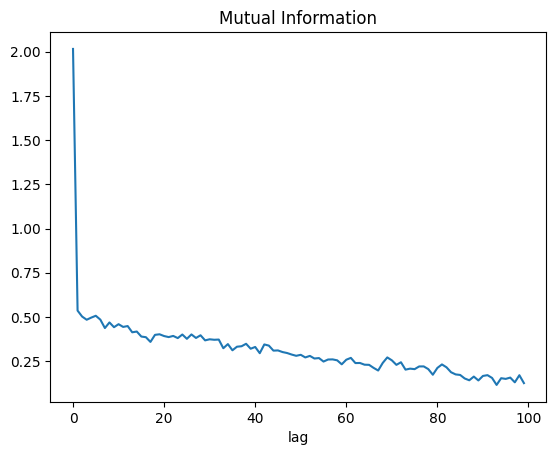

In [46]:
# mi = jl.seval("""
# using ComplexityMeasures

# function mi_curve(x, maxlag)
#     vals = Float64[]

#     for ttau in 1:maxlag
#         x1 = x[1:end-ttau]
#         x2 = x[1+ttau:end]

#         mi = association(
#             KraskovStögbauerGrassberger1(k=20),
#             x1,
#             x2
#         )

#         push!(vals, mi)
#     end

#     vals
# end

# mi_curve(x, 100)
# """)

mi = jl.seval("""
using ComplexityMeasures

function mi_curve_ksg(x, maxlag; k_neighbors=10)
    # 1. Нормализуем данные (важно для методов ближайших соседей)
    x_norm = (x .- sum(x)/length(x)) ./ (sum((x .- sum(x)/length(x)).^2)/length(x))^0.5
    
    vals = Float64[]
    # Определяем метод KSG с нужным числом соседей
    method = KraskovStögbauerGrassberger1(k = k_neighbors)

    for ttau in 1:maxlag
        # Формируем сдвинутые ряды
        x1 = x_norm[1:end-ttau]
        x2 = x_norm[1+ttau:end]

        # Вычисляем MI напрямую как ассоциацию
        val = association(method, x1, x2)
        push!(vals, val)
    end

    return vals
end

# Вызов функции
mi_curve_ksg(x, 100, k_neighbors=20)
""")

mi = np.array(mi)

plt.plot(mi)
plt.title("Mutual Information")
plt.xlabel("lag")
plt.show()

In [47]:
from scipy.signal import argrelextrema

mins = argrelextrema(mi, np.less)[0]

tau_mi = mins[0] + 1

print("tau (MI minimum) =", tau_mi)

tau (MI minimum) = 4


In [48]:
tau_mi = jl.seval("""
estimate_delay(x, "mi_min", 1:100)
""")

print(tau_mi)

3


In [49]:
tau_ac = jl.seval("""
estimate_delay(x, "ac_min", 1:100)
""")

print(tau_ac)

44


In [50]:
tau_zero = jl.seval("""
estimate_delay(x, "ac_zero", 1:100)
""")

print(tau_zero)

┌ Warning: Did not cross 0 value, returning last `τ`.
└ @ DelayEmbeddings C:\Users\Максим\.julia\packages\DelayEmbeddings\AV1Ee\src\separated_de\estimate_delay.jl:41


100


#### Размерность вложения

In [51]:
jl.tau = int(tau_mi)

In [8]:
jl.seval("""
using DelayEmbeddings
using DynamicalSystems
using ComplexityMeasures
""")

In [53]:
# fnn = jl.seval("""
# using DelayEmbeddings

# dims = 1:10

# vals = [
#     DelayEmbeddings.garcia_almeida_embedding_estimate(
#         x;
#         τ=tau,
#         D=d
#     )[2]
#     for d in dims
# ]

# vals
# """)
fnn = jl.seval("""
using DelayEmbeddings
# τ — ваш лаг
# ks — диапазон m (например, 1:10)
taumi = 4
ks = 1:10
E = cao_method(x, ks, taumi)
""")

fnn = np.array(fnn)
dims = np.arange(1, len(fnn)+1)

plt.plot(dims, fnn, marker="o")
plt.xlabel("Embedding dimension")
plt.ylabel("False nearest neighbors")
plt.title("FNN")
plt.show()

JuliaError: UndefVarError: `cao_method` not defined in `Main`
Stacktrace:
 [1] top-level scope
   @ none:6
 [2] eval
   @ .\boot.jl:430 [inlined]
 [3] eval
   @ .\Base.jl:130 [inlined]
 [4] pyjlmodule_seval(self::Module, expr::Py)
   @ PythonCall.JlWrap C:\Users\Максим\.julia\packages\PythonCall\83z4q\src\JlWrap\module.jl:13
 [5] _pyjl_callmethod(f::Any, self_::Ptr{PythonCall.C.PyObject}, args_::Ptr{PythonCall.C.PyObject}, nargs::Int64)
   @ PythonCall.JlWrap C:\Users\Максим\.julia\packages\PythonCall\83z4q\src\JlWrap\base.jl:65
 [6] _pyjl_callmethod(o::Ptr{PythonCall.C.PyObject}, args::Ptr{PythonCall.C.PyObject})
   @ PythonCall.JlWrap.Cjl C:\Users\Максим\.julia\packages\PythonCall\83z4q\src\JlWrap\C.jl:63

In [ ]:
jl.seval("""
using DelayEmbeddings
using DynamicalSystems
using ComplexityMeasures
""")

In [ ]:
jl.tau = int(tau_mi)
E1 = jl.seval("""
delay_afnn(x, tau, 2:12)
""")
E1 = np.array(E1)

dims = np.arange(2, 13)

plt.plot(dims, E1, marker='o')

plt.xlabel("Embedding dimension")
plt.ylabel("E1 statistic")
plt.title("Cao AFNN")

plt.grid(True)
plt.show()

JuliaError: InexactError: Int64(1.4142135623730951)
Stacktrace:
  [1] Int64
    @ .\float.jl:994 [inlined]
  [2] convert
    @ .\number.jl:7 [inlined]
  [3] setindex!
    @ .\array.jl:987 [inlined]
  [4] macro expansion
    @ C:\Users\Максим\.julia\packages\NearestNeighbors\8wgyo\src\kd_tree.jl:169 [inlined]
  [5] macro expansion
    @ .\simdloop.jl:77 [inlined]
  [6] _knn(tree::KDTree{SVector{2, Int64}, Euclidean, Int64, SVector{2, Int64}}, point::SVector{2, Int64}, best_idxs::Vector{Int64}, best_dists::Vector{Float64}, best_dists_final::Vector{Int64}, skip::Neighborhood.var"#34#37"{Neighborhood.Theiler{Nothing}, Int64}, self_idx::Int64)
    @ NearestNeighbors C:\Users\Максим\.julia\packages\NearestNeighbors\8wgyo\src\kd_tree.jl:168
  [7] _knn_point!(tree::KDTree{SVector{2, Int64}, Euclidean, Int64, SVector{2, Int64}}, point::SVector{2, Int64}, sortres::Bool, dist_final::Vector{Int64}, idx::Vector{Int64}, skip::Neighborhood.var"#34#37"{Neighborhood.Theiler{Nothing}, Int64}, self_idx::

In [ ]:
E1

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [ ]:
dE = np.abs(np.diff(E1))

m = dims[np.where(dE < 0.01)[0][0]]

print("embedding dimension =", m)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
m = dims[np.where(fnn < 0.05)[0][0]]

print("embedding dimension =", m)

In [ ]:
jl_x = jl.seval("""
x
""")
jl_x = np.array(jl_x)

In [ ]:
result = jl.seval("""
optimal_separated_de(
    Vector{Float64}(x),
    "fnn",
    "mi_min";
    τs = 1:100,
    dmax = 20
)
""")

JuliaError: BoundsError: attempt to access 2577-element Vector{SVector{1, Float64}} at index [[0.0, 0.0]]
Stacktrace:
  [1] throw_boundserror(A::Vector{SVector{1, Float64}}, I::Tuple{Vector{Float64}})
    @ Base .\essentials.jl:14
  [2] checkbounds
    @ .\abstractarray.jl:699 [inlined]
  [3] _getindex
    @ .\multidimensional.jl:914 [inlined]
  [4] getindex(A::Vector{SVector{1, Float64}}, I::Vector{Float64})
    @ Base .\abstractarray.jl:1312
  [5] getindex
    @ C:\Users\Максим\.julia\packages\StateSpaceSets\wnc9y\src\statespaceset.jl:0 [inlined]
  [6] delay_fnn(s::Vector{Float64}, τ::Int64, ds::UnitRange{Int64}; rtol::Float64, atol::Float64)
    @ DelayEmbeddings C:\Users\Максим\.julia\packages\DelayEmbeddings\AV1Ee\src\separated_de\estimate_dimension.jl:174
  [7] delay_fnn
    @ C:\Users\Максим\.julia\packages\DelayEmbeddings\AV1Ee\src\separated_de\estimate_dimension.jl:158 [inlined]
  [8] optimal_separated_de(s::Vector{Float64}, dimensionmethod::String, delaymethod::String; fnn_th

In [55]:
result

(Julia:
 9-dimensional StateSpaceSet{Float64} with 2556 points
  9258.0  9256.0  9252.0  9250.0  9248.0  9254.0  9250.0  9257.0  9256.0
  9258.0  9256.0  9252.0  9255.0  9248.0  9250.0  9250.0  9251.0  9256.0
  9256.0  9256.0  9250.0  9255.0  9254.0  9250.0  9257.0  9251.0  9256.0
  9256.0  9252.0  9250.0  9248.0  9254.0  9250.0  9257.0  9256.0  9256.0
  9256.0  9252.0  9255.0  9248.0  9250.0  9250.0  9251.0  9256.0  9253.0
  9256.0  9250.0  9255.0  9254.0  9250.0  9257.0  9251.0  9256.0  9253.0
  9252.0  9250.0  9248.0  9254.0  9250.0  9257.0  9256.0  9256.0  9248.0
  9252.0  9255.0  9248.0  9250.0  9250.0  9251.0  9256.0  9253.0  9248.0
  9250.0  9255.0  9254.0  9250.0  9257.0  9251.0  9256.0  9253.0  9253.0
  9250.0  9248.0  9254.0  9250.0  9257.0  9256.0  9256.0  9248.0  9253.0
     ⋮                                       ⋮                    
  8634.0  8632.0  8634.0  8629.0  8622.0  8651.0  8647.0     0.0     0.0
  8635.0  8632.0  8629.0  8629.0  8651.0  8651.0  8537.0     0.0   

In [56]:
Y, tau_opt, E = result
Y = np.array(jl.Matrix(Y))
m = Y.shape[1]
print("tau =", tau_opt)
print("embedding dimension =", m)

tau = 3
embedding dimension = 9


In [ ]:
print(tau_opt)

3


In [ ]:
Y_np = np.array(jl.Matrix(Y))
Y_np.shape

(2556, 9)

#### Реконструкция

In [57]:
jl.m = int(m)

embedded = jl.seval("""
using DelayEmbeddings

Y = embed(x, m, tau)

Matrix(Y)
""")

embedded = np.array(embedded)

embedded.shape

(2556, 9)

##### 2D

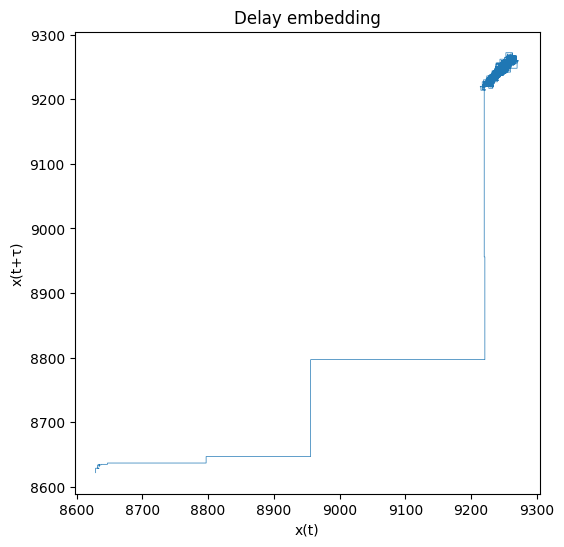

In [58]:
plt.figure(figsize=(6,6))
plt.plot(embedded[:,0], embedded[:,1], lw=0.5)
plt.xlabel("x(t)")
plt.ylabel("x(t+τ)")
plt.title("Delay embedding")
plt.show()

##### 3D

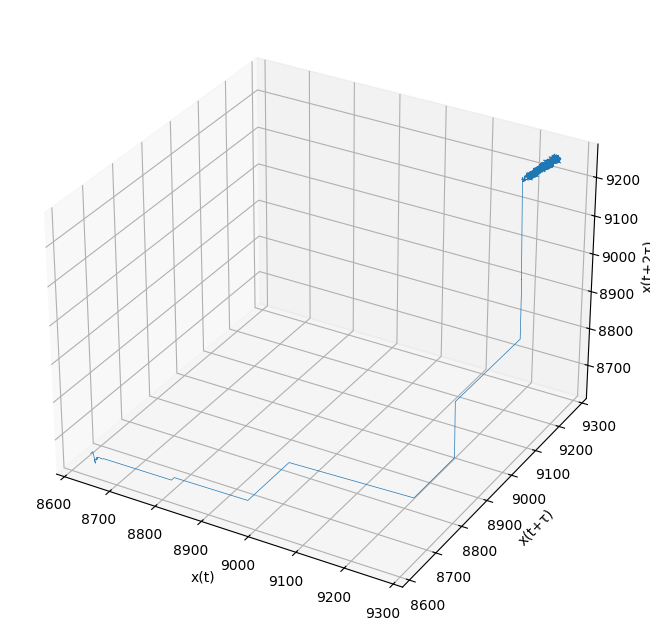

In [59]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    embedded[:,0],
    embedded[:,1],
    embedded[:,2],
    lw=0.5
)

ax.set_xlabel("x(t)")
ax.set_ylabel("x(t+τ)")
ax.set_zlabel("x(t+2τ)")

plt.show()

### Неравномерное вложение

In [7]:
jl.seval("""
using Pkg

# Pkg.add("DelayEmbeddings")
# Pkg.add("DynamicalSystems")
# Pkg.add("CairoMakie")
""")

In [8]:
jl.seval("""
using DelayEmbeddings
using DynamicalSystems
using Statistics
""")

In [46]:
from juliacall import convert as jlconvert

x = df["Lab5_G1_T1"].to_numpy(dtype=np.float64)

In [47]:
x.shape

(1290,)

In [48]:
eps = 1e-10 * np.std(x)
x_jitter = x + eps * np.random.randn(len(x))
jl.x = jlconvert(jl.Vector, x_jitter)

In [53]:
w_estimated = jl.estimate_delay(x_jitter, "mi_min")

In [55]:
print(w_estimated)
jl.w_est = w_estimated

3


In [59]:
result = jl.seval("""
Y, τ_vals, ts_vals, Ls, eps = pecuzal_embedding(
    x;
    τs = 0:150,
    w = w_est,
    econ = false,
    verbose = true,
    samplesize=1.0
)

(
    Y,
    τ_vals,
    ts_vals,
    Ls
)
""")

Initializing PECUZAL algorithm for univariate input...
Starting 1-th embedding cycle...
Algorithm stopped due to increasing L-values in the first embedding cycle. Valid embedding NOT achieved ⨉.


In [50]:
embedded, tau_vals, ts_vals, Ls = result

In [51]:
print(tau_vals)
print(ts_vals)
print(Ls)

[0]
[1]
Float64[]


In [100]:
type(np.array(tau_vals)[0])

numpy.int64

In [12]:
embedded

2580-element Vector{Float64}:
 -3.7000000000247364
 -3.6999999998827784
 -3.500000000009244
 -3.500000000066117
 -3.6999999999480906
 -3.69999999997773
 -3.499999999906092
 -3.499999999985855
 -3.899999999952671
 -3.9000000001157424
  ⋮
 -2.3999999999776973
 -1.999999999997907
 -2.0000000000152656
 -1.3000000000965524
 -1.3000000000628715
 -0.9000000000682435
 -0.8999999999554074
 -0.8999999999562084
 -0.89999999999174

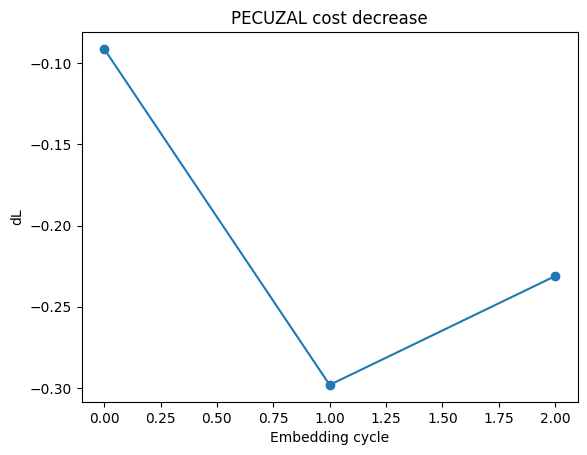

In [65]:
plt.plot(Ls, marker='o')
plt.xlabel("Embedding cycle")
plt.ylabel("dL")
plt.title("PECUZAL cost decrease")
plt.show()

#### Реконструкция

##### 2D

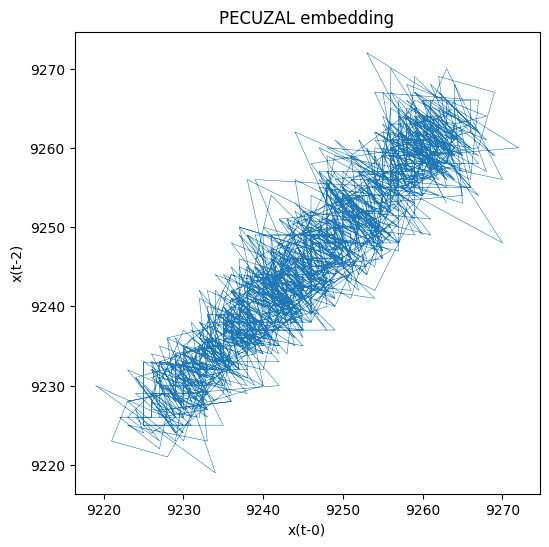

In [66]:
embedded = np.array(embedded)

plt.figure(figsize=(6,6))

plt.plot(
    embedded[:,0],
    embedded[:,1],
    lw=0.4
)

plt.xlabel(f"x(t-{tau_vals[0]})")
plt.ylabel(f"x(t-{tau_vals[1]})")

plt.title("PECUZAL embedding")
plt.show()

##### 3D

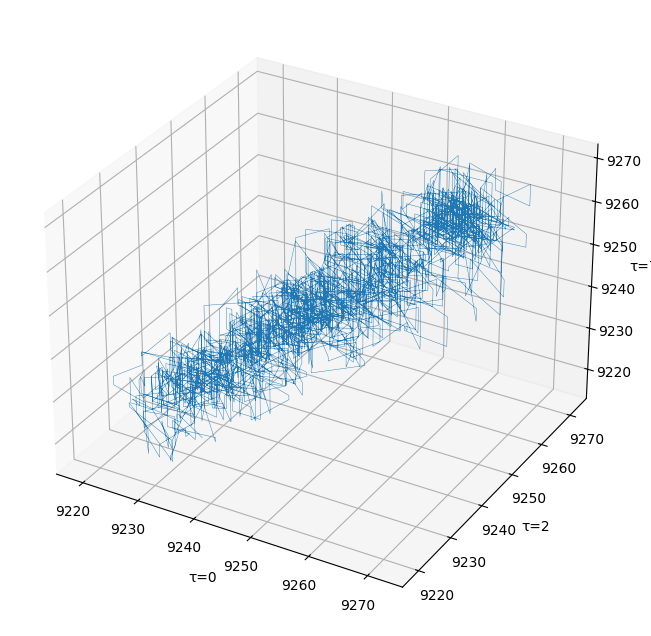

In [67]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    embedded[:,0],
    embedded[:,1],
    embedded[:,2],
    lw=0.3
)

ax.set_xlabel(f"τ={tau_vals[0]}")
ax.set_ylabel(f"τ={tau_vals[1]}")
ax.set_zlabel(f"τ={tau_vals[2]}")

plt.show()

#### Многомерное вложение через PECUZAL

In [39]:
X_ = df.drop(columns=["row", "TS"]).to_numpy(dtype=np.float64)

In [40]:
X_.shape

(2580, 117)

In [34]:
df["Lab5_G1_T1"].values.reshape(-1, 1).shape

(2580, 1)

In [17]:
df_cleaned.head(10)

,row,TS,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,...,Lab5_Kran_12,Lab5_Kran_9,Lab5_U_Kran_GPA_A_OGK,Lab5_Kran_SK,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_1,Lab5_q
0,1,2021-01-04 17:00:00+00:00,9258,11923,4948,15.43,706.0,-3.7,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
1,2,2021-01-04 17:00:00+00:00,9258,11923,4948,15.43,706.0,-3.7,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
2,3,2021-01-04 17:00:59.999999+00:00,9256,11927,4943,15.41,706.6,-3.5,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
3,4,2021-01-04 17:00:59.999999+00:00,9256,11927,4943,15.41,706.6,-3.5,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
4,5,2021-01-04 17:01:59.999999+00:00,9256,11924,4960,15.45,706.1,-3.7,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
5,6,2021-01-04 17:01:59.999999+00:00,9256,11924,4960,15.45,706.1,-3.7,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
6,7,2021-01-04 17:02:59.999999+00:00,9252,11923,4956,15.42,706.3,-3.5,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
7,8,2021-01-04 17:02:59.999999+00:00,9252,11923,4956,15.42,706.3,-3.5,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
8,9,2021-01-04 17:03:59.999999+00:00,9250,11916,4951,15.41,705.2,-3.9,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9
9,10,2021-01-04 17:03:59.999999+00:00,9250,11916,4951,15.41,705.2,-3.9,41.0,79.44,...,1,0,1,1,0.89,0.26,0,1,1,48.9


In [20]:
pd.DataFrame(X_).tail(10)

,0,1,2,3,4,5,6,7,8,9,...,84,85,86,87,88,89,90,91,92,93
2570,0.0,551.0,0.0,0.14,231.8,-2.4,41.2,83.81,66.9,91.64,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2571,0.0,551.0,0.0,0.14,231.8,-2.4,41.2,83.81,66.9,91.64,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2572,0.0,0.0,0.0,0.14,245.8,-2.0,40.9,83.49,72.3,89.03,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2573,0.0,0.0,0.0,0.14,245.8,-2.0,40.9,83.49,72.3,89.03,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2574,0.0,0.0,0.0,0.14,280.7,-1.3,40.7,81.20,70.6,89.03,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2575,0.0,0.0,0.0,0.14,280.7,-1.3,40.7,81.20,70.6,89.03,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2576,0.0,0.0,0.0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2577,0.0,0.0,0.0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2578,0.0,0.0,0.0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2579,0.0,0.0,0.0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [10]:
std_devs = np.std(X_, axis=0)
std_devs.shape

(94,)

In [14]:
std_devs = np.std(X_, axis=0)
noise_level = 1e-8
noise = np.random.normal(loc=0.0, scale=std_devs * noise_level, size=X_.shape)
X = X_ + noise

In [21]:
X = (X - X.mean(axis=0)) / X.std(axis=0)
jl.X = X
jl.seval("""
data = StateSpaceSet(X)
""")

NameError: name 'X' is not defined

In [16]:
dim_result = jl.seval("""
Y, τ_vals, ts_vals, Ls, eps =
    pecuzal_embedding(
        data;
        τs = 0:30,
        w = 30,
        econ = true,
        verbose = false
    )

(
    Matrix(Y),
    τ_vals,
    ts_vals,
    Ls
)
""")

In [17]:
embedded, tau_vals, ts_vals, Ls = dim_result
embedded = np.array(embedded)
print("embedded shape:", embedded.shape)

print("selected delays:")
print(tau_vals)

print("selected channels:")
print(ts_vals)

embedded shape: (2550, 50)
selected delays:
[0, 13, 0, 1, 13, 13, 29, 4, 0, 26, 6, 2, 8, 12, 6, 15, 28, 8, 9, 1, 0, 1, 30, 11, 7, 0, 20, 26, 2, 3, 27, 21, 28, 17, 0, 2, 10, 0, 17, 19, 0, 4, 1, 6, 22, 24, 25, 3, 5, 3]
selected channels:
[49, 48, 53, 45, 6, 73, 65, 8, 8, 27, 65, 8, 65, 65, 8, 82, 27, 8, 8, 65, 6, 76, 53, 8, 11, 8, 65, 65, 6, 8, 65, 70, 73, 65, 70, 8, 65, 65, 73, 65, 8, 8, 8, 8, 65, 65, 65, 65, 8, 8]


In [21]:
pd.DataFrame(embedded).to_csv("pecuzal_nopca_embed.csv")
pd.DataFrame(np.array(tau_vals)).to_csv("pecuzal_nopca_tau.csv")
pd.DataFrame(np.array(ts_vals)).to_csv("pecuzal_nopca_ts.csv")
pd.DataFrame(np.array(Ls)).to_csv("pecuzal_nopca_L.csv")

### Реконструкция

##### 2D

In [22]:
def reconstructed_2d(embedded, title):
    embedded = np.array(embedded)
    plt.figure(figsize=(6,6))
    plt.plot(
        embedded[:,0],
        embedded[:,1],
        lw=0.4
    )
    plt.xlabel(f"x(t-{tau_vals[0]})")
    plt.ylabel(f"x(t-{tau_vals[1]})")
    plt.title(title)
    plt.show()

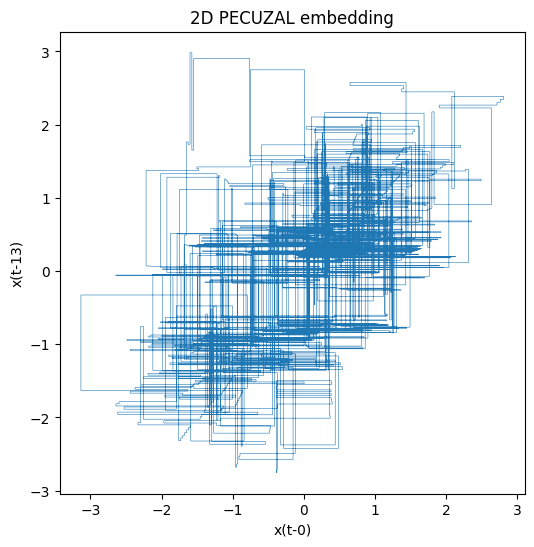

In [23]:
reconstructed_2d(embedded, '2D PECUZAL embedding')

##### 3D

In [24]:
from mpl_toolkits.mplot3d import Axes3D

def reconstructed_3d(embedded, title):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(
        embedded[:,0],
        embedded[:,1],
        embedded[:,2],
        lw=0.3
    )
    ax.set_xlabel(f"τ={tau_vals[0]}")
    ax.set_ylabel(f"τ={tau_vals[1]}")
    ax.set_zlabel(f"τ={tau_vals[2]}")
    plt.show()

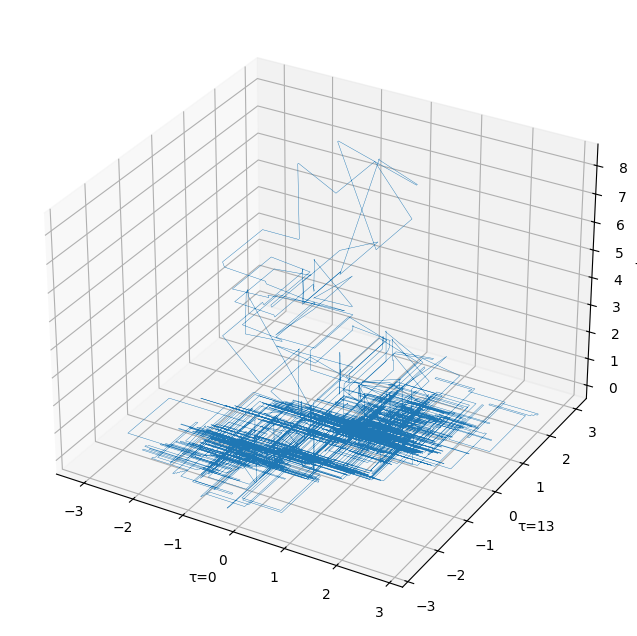

In [25]:
reconstructed_3d(embedded, '3D PECUZAL embedding')

### Топологический анализ данных

In [5]:
embedded = pd.read_csv("./pecuzal_nopca_embed.csv", index_col=0)
embedded

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.036666,-0.065617,-0.313515,-0.01164,-0.030382,-0.020285,-2.048568,0.237337,0.237337,-0.496846,...,0.237337,0.237337,0.237337,0.237337,-2.048568,-2.048568,-2.048568,-2.048568,0.237337,0.237337
1,-0.036666,-0.065617,-0.313515,-0.01164,0.137110,-0.020285,-2.048568,0.237337,0.237337,-0.496846,...,0.237337,0.237337,0.237337,0.237337,-2.048568,-2.048568,-2.048568,-2.377093,0.237337,0.237337
2,-0.036666,-0.065617,-0.313515,-0.01164,0.137110,-0.020285,-2.048568,0.237337,0.237337,-0.488962,...,0.237337,0.237337,0.237337,0.237337,-2.048568,-2.048568,-2.048568,-2.377093,0.237337,0.237337
3,-0.036666,-0.065617,-0.313515,-0.01164,-0.030382,-0.020285,-2.048568,0.237337,0.237337,-0.488962,...,0.237337,0.237337,0.237337,0.237337,-2.048568,-2.048568,-2.048568,-2.377093,0.237337,0.237337
4,-0.036666,-0.065617,-0.313515,-0.01164,-0.030382,-0.020285,-2.048568,0.237337,0.237337,-0.499474,...,0.237337,0.237337,0.237337,0.237337,-2.048568,-2.048568,-2.048568,-2.377093,0.237337,0.237337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545,-0.036666,-0.065617,-0.313515,-0.01164,-0.197874,-1.474059,-4.676766,-8.029714,-7.043735,-1.475755,...,-7.043735,-8.029714,-7.631530,-8.408937,-0.734469,-0.405944,-1.062994,-2.377093,-8.408937,-8.029714
2546,-0.036666,-0.065617,-0.313515,-0.01164,-0.197874,-1.474059,-4.676766,-8.408937,-7.631530,-1.466557,...,-7.631530,-8.408937,-7.631530,-8.807120,-0.405944,-1.062994,-1.062994,-2.377093,-8.408937,-8.029714
2547,-0.036666,-0.065617,-0.313515,-0.01164,-0.365366,-1.352911,-7.304963,-8.408937,-7.631530,-1.466557,...,-7.631530,-8.408937,-8.029714,-8.807120,-0.405944,-1.062994,-3.034142,-2.705617,-8.807120,-8.408937
2548,-0.036666,-0.065617,-0.313515,-0.01164,-0.365366,-1.352911,-7.304963,-8.807120,-8.029714,-1.499407,...,-8.029714,-8.807120,-8.029714,-8.996731,-1.062994,-3.034142,-3.034142,-2.705617,-8.807120,-8.408937


### Построение комплекса (Вьеторис-Рипс, PECUZAL)


In [6]:
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram

def VR_diagrams(embedded):
    VR = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=[0, 1, 2],
        collapse_edges=True,   # ускорение для больших облаков
        max_edge_length=np.inf
    )

    X_tda = embedded[np.newaxis, :, :]   # (1, 2580, 12)
    diagrams = VR.fit_transform(X_tda)  # shape (1, n_bars, 3): birth, death, dim
    return diagrams

In [7]:
diagrams = VR_diagrams(np.array(embedded))

### Диаграмма персистентности (PECUZAL)

In [8]:
fig = plot_diagram(diagrams[0])
fig.show()

### Векторизация (PECUZAL, многомерный ряд)


#### Ландшафты персистентности


In [14]:
from gtda.diagrams import PersistenceLandscape

def persistence_landscape_show(diagrams):
    PL = PersistenceLandscape(n_layers=5, n_bins=100)
    landscapes = PL.fit_transform(diagrams)  # shape (1, n_layers*n_dims, n_bins)
    fig = PL.plot(landscapes, sample=0)
    fig.show()

In [15]:
persistence_landscape_show(diagrams)

#### Образы

In [16]:
from gtda.diagrams import PersistenceImage

def persistence_image_show(diagrams):
    PI = PersistenceImage(sigma=0.05, n_bins=20)
    images = PI.fit_transform(diagrams)  # shape (1, n_dims, n_bins, n_bins)
    for i in range(3):
        fig = PI.plot(images, sample=0, homology_dimension_idx=i)
        fig.show()

In [17]:
persistence_image_show(diagrams)

#### Кривые Бетти


In [18]:
from gtda.diagrams import BettiCurve

def betti_curve_show(diagrams):
    BC = BettiCurve(n_bins=100)
    betti = BC.fit_transform(diagrams)
    fig = BC.plot(betti, sample=0, )
    fig.show()

In [19]:
betti_curve_show(diagrams)

### Вложение многомерного ряда с PCA

In [10]:
def build_hankel(X, L):
    T, D = X.shape
    rows = []
    for t in range(L, T):
        row = []
        for l in range(L + 1):
            row.append(X[t - l])
        rows.append(np.concatenate(row))
    return np.array(rows)

In [48]:
X_ = df_cleaned[cleaned_numeric_cols].values
X_

array([[1.0000e+00, 9.2580e+03, 1.1923e+04, ..., 1.0000e+00, 1.0000e+00,
        4.8900e+01],
       [2.0000e+00, 9.2580e+03, 1.1923e+04, ..., 1.0000e+00, 1.0000e+00,
        4.8900e+01],
       [3.0000e+00, 9.2560e+03, 1.1927e+04, ..., 1.0000e+00, 1.0000e+00,
        4.8900e+01],
       ...,
       [2.5780e+03, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [2.5790e+03, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [2.5800e+03, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]])

In [50]:
X_hankel = build_hankel(X_, 10)

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9999)
X_reduced = pca.fit_transform(X_hankel)

In [59]:
np.cumsum(pca.explained_variance_ratio_)

array([0.61217731, 0.89660485, 0.94989089, 0.96868353, 0.97740389,
       0.98284811, 0.9866201 , 0.98952653, 0.99188247, 0.99402476,
       0.99609872, 0.99814873, 0.99980473, 0.99987852, 0.99991981])

In [60]:
std_devs = np.std(X_reduced, axis=0)
noise_level = 1e-10
noise = np.random.normal(loc=0.0, scale=std_devs * noise_level, size=X_reduced.shape)
X = X_reduced + noise

In [61]:
X = (X - X.mean(axis=0)) / X.std(axis=0)
jl.X = X
jl.seval("""
data = StateSpaceSet(X)
""")

15-dimensional StateSpaceSet{Float64} with 2570 points
 -0.283481  1.71213     0.0728653  …   0.101916   -0.349182    1.41961
 -0.282763  1.71095     0.0701816      0.0930598  -0.395931    1.45215
 -0.281372  1.70989     0.0691777      0.0957618  -0.329625    1.50836
 -0.280174  1.70881     0.0675977      0.0915023  -0.129346    1.54205
 -0.279779  1.70756     0.0626932      0.0938684   0.0795049   1.59477
 -0.279377  1.70628     0.057383   …   0.107974    0.119103    1.61332
 -0.278593  1.70508     0.0547925      0.0991737   0.045275    1.60628
 -0.278086  1.70382     0.0541546      0.0937398   0.0339478   1.57529
 -0.277842  1.70251     0.0533319      0.085048    0.014027    1.506
 -0.277783  1.70115     0.0540843      0.0860479  -0.093455    1.4297
  ⋮                                ⋱                          
  9.79354   0.464177   20.236         -1.32796    -0.885324   -0.142103
 11.8067    0.984857   19.5508         0.826427   -0.943791   -0.118048
 13.6538    1.47851    15.9355 

In [62]:
dim_result = jl.seval("""
Y, τ_vals, ts_vals, Ls, eps =
    pecuzal_embedding(
        data;
        τs = 0:30,
        w = 30,
        econ = true,
        verbose = false
    )

(
    Matrix(Y),
    τ_vals,
    ts_vals,
    Ls
)
""")

In [63]:
embedded, tau_vals, ts_vals, Ls = dim_result
embedded = np.array(embedded)
print("embedded shape:", embedded.shape)

print("selected delays:")
print(tau_vals)

print("selected channels:")
print(ts_vals)

embedded shape: (2542, 12)
selected delays:
[0, 1, 0, 0, 14, 9, 11, 28, 25, 25, 0, 2]
selected channels:
[2, 12, 9, 12, 9, 10, 5, 9, 11, 10, 10, 8]


#### Реконструкция

##### 2D

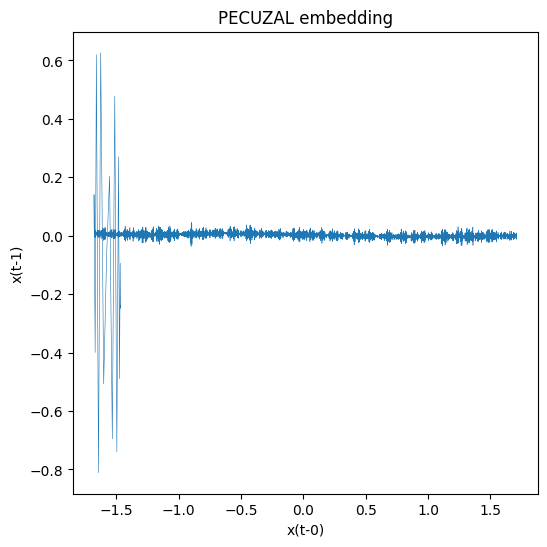

In [64]:
embedded = np.array(embedded)

plt.figure(figsize=(6,6))

plt.plot(
    embedded[:,0],
    embedded[:,1],
    lw=0.4
)

plt.xlabel(f"x(t-{tau_vals[0]})")
plt.ylabel(f"x(t-{tau_vals[1]})")

plt.title("PECUZAL embedding")
plt.show()

##### 3D

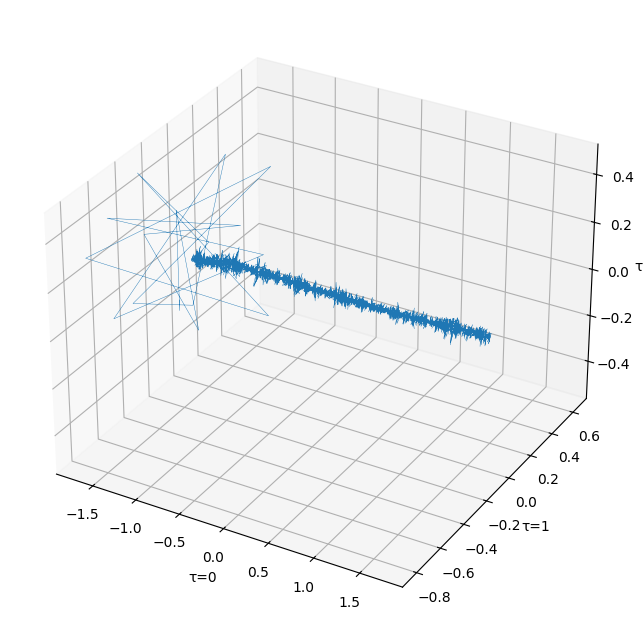

In [65]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    embedded[:,0],
    embedded[:,1],
    embedded[:,2],
    lw=0.3
)

ax.set_xlabel(f"τ={tau_vals[0]}")
ax.set_ylabel(f"τ={tau_vals[1]}")
ax.set_zlabel(f"τ={tau_vals[2]}")

plt.show()

## Топологический анализ данных

In [66]:
embedded.shape

(2542, 12)

### Построение комплекса (Вьеторис-Рипс, PECUZAL)

In [67]:
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram

VR = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=[0, 1, 2],
    collapse_edges=True,   # ускорение для больших облаков
    max_edge_length=np.inf
)

X_tda = embedded[np.newaxis, :, :]   # (1, 2580, 12)
diagrams = VR.fit_transform(X_tda)  # shape (1, n_bars, 3): birth, death, dim

### Диаграмма персистентности (PECUZAL)

In [68]:
fig = plot_diagram(diagrams[0])
fig.show()

### Векторизация (PECUZAL, многомерный ряд)

#### Ландшафты персистентности

In [69]:
from gtda.diagrams import PersistenceLandscape

PL = PersistenceLandscape(n_layers=5, n_bins=100)
landscapes = PL.fit_transform(diagrams)  # shape (1, n_layers*n_dims, n_bins)

In [73]:
PL.plot(landscapes, sample=0)

#### Образы

In [74]:
from gtda.diagrams import PersistenceImage

PI = PersistenceImage(sigma=0.05, n_bins=20)
images = PI.fit_transform(diagrams)  # shape (1, n_dims, n_bins, n_bins)

In [79]:
for i in range(3):
    fig = PI.plot(images, sample=0, homology_dimension_idx=i)
    fig.show()

#### Кривые Бетти

In [80]:
from gtda.diagrams import BettiCurve

BC = BettiCurve(n_bins=100)
betti = BC.fit_transform(diagrams)  # shape (1, n_dims, n_bins)

In [83]:
BC.plot(betti, sample=0, )

#### Кривые Эйлера

In [84]:
from gtda.diagrams import EulerCharacteristic

EC = EulerCharacteristic(n_bins=100)
euler = EC.fit_transform(diagrams)  # shape (1, n_dims, n_bins)

ImportError: cannot import name 'EulerCharacteristic' from 'gtda.diagrams' (c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\gtda\diagrams\__init__.py)

In [ ]:
EC.plot(euler, sample=0)

#### Скалярные характеристики

In [85]:
from gtda.diagrams import Amplitude, PersistenceEntropy

# Амплитуды (нормы ландшафтов, образов и т.д.)
amp = Amplitude(metric='wasserstein')
amplitudes = amp.fit_transform(diagrams)

# Энтропия персистентности
PE = PersistenceEntropy()
entropy = PE.fit_transform(diagrams)

### Кластеризация

In [ ]:
from gtda.time_series import SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve
from sklearn.pipeline import make_pipeline
import numpy as np

window_size = 50
stride = 10

SW = SlidingWindow(size=window_size, stride=stride)
X_windows = SW.fit_transform(embedded) 

VR = VietorisRipsPersistence(homology_dimensions=[0,1], collapse_edges=True)
diagrams_windows = VR.fit_transform(X_windows)

PE = PersistenceEntropy(normalize=True)
BC = BettiCurve(n_bins=50)

features_entropy = PE.fit_transform(diagrams_windows)
features_betti   = BC.fit_transform(diagrams_windows).reshape(len(X_windows), -1)

features = np.hstack([features_entropy, features_betti])

#### KMeans

In [92]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA as skPCA

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

from sklearn.metrics import silhouette_score

for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

km = KMeans(n_clusters=4, random_state=42)
cluster_labels = km.fit_predict(features_scaled)

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



k=2, silhouette=0.978
k=3, silhouette=0.904


c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



k=4, silhouette=0.830


c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



...

k=17, silhouette=0.351


c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



k=18, silhouette=0.372


c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



k=19, silhouette=0.384


## Полный цикл для одномерных вложений

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import entropy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

# import umap
# import hdbscan
import nolds
# import antropy as ant

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape
from gtda.diagrams import PersistenceImage
from gtda.diagrams import BettiCurve
from gtda.diagrams import PairwiseDistance

from juliacall import Main as jl
from swpy import Timer
from teaspoon.parameter_selection.FNN_n import FNN_n
from teaspoon.parameter_selection.MI_delay import MI_for_delay

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
def init_julia():
    jl.seval("using DelayEmbeddings")
    jl.seval("using DynamicalSystems")

jl.seval("using DelayEmbeddings")
jl.seval("using DynamicalSystems")

### Препроцессинг

In [3]:
def clean_series(x):
    x = np.asarray(x).astype(float)
    mask = np.isfinite(x)
    return x[mask]

def is_constant_series(x, eps=1e-8):
    return np.max(x) - np.min(x) < eps

def is_nearly_constant_series(x, eps=1e-2):
    cv = np.std(x) / (np.abs(np.mean(x)) + 1e-12)
    return cv < eps, cv

def dominant_bin_ratio(x, bins=30):
    hist, _ = np.histogram(x, bins=bins)
    return hist.max() / hist.sum()

def series_summary_stats(x):
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "dominant_bin_ratio": dominant_bin_ratio(x)
    }

### Визуализация

In [4]:
def plot_series(x, title):
    print("In plot")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x)
    ax.set_title(title)
    plt.show()

def plot_binplot(x, title, bins=30):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(x, bins=bins)
    ax.set_title(title)
    plt.show()

def plot_embedding_2d(emb, labels=None, title="embedding"):
    reducer = PCA(n_components=2)
    z = reducer.fit_transform(emb)
    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(z[:, 0], z[:, 1], c=labels, s=5)
    ax.set_title(title)
    plt.show()

def plot_embedding_3d(emb, labels=None, title="embedding"):
    reducer = PCA(n_components=3)
    z = reducer.fit_transform(emb)
    fig = px.scatter_3d(
        x=z[:, 0],
        y=z[:, 1],
        z=z[:, 2],
        color=labels.astype(str) if labels is not None else None,
        title=title
    )
    fig.show()

def plot_persistence_diagram(diagram):
    from gtda.plotting import plot_diagram
    fig = plot_diagram(diagram)
    fig.show()

def plot_betti_curves(curves):
    fig, ax = plt.subplots(figsize=(10, 5))
    for i in range(curves.shape[1]):
        ax.plot(curves[:, i])
    plt.show()

### Стационарность

In [5]:
def adf_test(x):
    stat, pvalue, *_ = adfuller(x)
    return {
        "adf_stat": stat,
        "adf_pvalue": pvalue
    }

def kpss_test(x):
    stat, pvalue, *_ = kpss(x, nlags="auto")
    return {
        "kpss_stat": stat,
        "kpss_pvalue": pvalue
    }

def hurst_exponent(x):
    return nolds.hurst_rs(x)

def lyapunov_exponent(x):
    try:
        return nolds.lyap_r(x)
    except:
        return np.nan

def infer_process_type(
    lyapunov,
    hurst,
    adf_p,
    kpss_p,
    const_flag
):
    if const_flag:
        return "constant"

    if adf_p < 0.05 and kpss_p > 0.05:
        if lyapunov > 0:
            return "chaotic_stationary"
        if hurst > 0.5:
            return "persistent_stationary"
        return "stationary"

    if adf_p > 0.05 and kpss_p < 0.05:
        return "nonstationary"

    if adf_p < 0.05 and kpss_p < 0.05:
        return "trend_stationary"

    return "inconclusive"

def analyze_stationarity(x):
    adf_res = adf_test(x)
    kpss_res = kpss_test(x)

    hurst = hurst_exponent(x)
    lyap = lyapunov_exponent(x)

    process_type = infer_process_type(
        lyap,
        hurst,
        adf_res["adf_pvalue"],
        kpss_res["kpss_pvalue"],
        is_constant_series(x)
    )

    return {
        **adf_res,
        **kpss_res,
        "hurst": hurst,
        "lyapunov": lyap,
        "process_type": process_type
    }

### Вложение

In [101]:
from juliacall import convert as jlconvert


def estimate_delay_julia(x, max_tau=100):
    jl.x = x
    jl.max_tau = max_tau
    tau = jl.seval("""
    using DelayEmbeddings
    estimate_delay(x, "mi_min", 1:max_tau)
    """)
    return int(tau)

def estimate_dimension_julia(x, tau, max_dim=10):
    jl.x = x
    jl.tau = tau
    jl.max_dim = max_dim

    dims = jl.seval("""
    using DelayEmbeddings
    estimate_dimension(x, tau, 1:max_dim, "fnn")
    """)

    dims = np.asarray(dims)

    idx = np.argmin(dims)
    return int(idx + 1), dims

def estimate_embedding_params(
    x,
    max_tau=100,
    max_dim=10,
    method="basic"
):
    x = np.asarray(x).astype(float)
    tau = MI_for_delay(
        x,
        plotting=False,
        method=method,
        h_method="sturge",
        k=2,
        ranking=True
    )
    print(f"Tau before: {tau}")
    tau = int(tau)
    fnn_curve, dim = FNN_n(
        x,
        tau=tau,
        maxDim=max_dim,
        plotting=False
    )
    fnn_curve = np.asarray(fnn_curve)
    emb = takens_embedding(
        x,
        tau,
        dim
    )
    return {
        "tau": tau,
        "dimension": int(dim),
        "fnn_curve": fnn_curve,
        "embedding": emb,
    }

def estimate_embedding_params_julia(
    x,
    max_tau=100,
    max_dim=10,
    fnn_threshold=0.05,
    slope_threshold=0.05
):
    jl.x = np.asarray(x, dtype=float)
    jl.max_tau = int(max_tau)
    jl.max_dim = int(max_dim)
    jl.fnn_threshold = float(fnn_threshold)
    jl.slope_threshold = float(slope_threshold)

    result = jl.seval("""
    using DelayEmbeddings

    Y, tau, E = DelayEmbeddings.optimal_separated_de(
        x,
        "fnn",
        "mi_min"
        # τs = 1:max_tau,
        # dmax = max_dim,
        # fnn_thres = fnn_threshold,
        # slope_thres = slope_threshold
    )

    (
        Matrix(Y),
        tau,
        E,
        size(Y, 2)
    )
    """)
    embedding = np.asarray(result[0])
    tau = int(result[1])
    fnn_curve = np.asarray(result[2])
    dimension = int(result[3])
    return {
        "embedding": embedding,
        "tau": tau,
        "dimension": dimension,
        "fnn_curve": fnn_curve
    }

def takens_embedding(x, tau, dim):
    x = np.asarray(x)
    n = len(x) - (dim - 1) * tau
    emb = np.empty((n, dim))
    for i in range(dim):
        emb[:, i] = x[i * tau:i * tau + n]
    return emb

def uniform_embedding_julia(x, tau, dim):
    jl.x = x
    jl.tau = tau
    jl.dim = dim

    emb = jl.seval("""
    using DelayEmbeddings
    Matrix(embed(x, dim, tau))
    """)

    return np.asarray(emb)

def pecuzal_embedding_julia(x, max_tau=150):
    x_jitter = x + 1e-5 * np.std(x) * np.random.randn(len(x))
    jl.x = jlconvert(jl.Vector, x_jitter)
    jl.max_tau = max_tau
    w_estimated = jl.estimate_delay(x_jitter, "mi_min")
    jl.w_est = w_estimated

    result = jl.seval("""
    using DelayEmbeddings
    # data = StateSpaceSet(x)
    Y, tau_vals, ts_vals, Ls, epss =
    pecuzal_embedding(
        x;
        τs = 0:max_tau,
        w = w_est,
        econ = false,
        verbose = true,
        samplesize=1.0
    )

    (
        Y,
        tau_vals,
        ts_vals,
        Ls
    )
    """)

    # emb = np.asarray(result[0])
    taus = np.asarray(result[1])

    return {
        # "embedding": emb,
        "taus": taus,
        "ts_vals": result[2],
        "Ls": result[3],
        # "epss": result[4],
    }

def build_embedding_index_map(n_points, dim, tau):
    mapping = {}

    for i in range(n_points):
        mapping[i] = [
            i + k * tau
            for k in range(dim)
        ]

    return mapping

### Топологический анализ данных

In [7]:
def compute_persistence(
    emb,
    homology_dimensions=(0, 1, 2),
    max_edge_length=np.inf
):
    vr = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=homology_dimensions,
        max_edge_length=max_edge_length,
        n_jobs=-1
    )

    diagrams = vr.fit_transform([emb])

    return diagrams[0]

def persistence_landscape_features(diagrams):
    pl = PersistenceLandscape(n_layers=5, n_bins=100)
    return pl.fit_transform([diagrams])[0]

def persistence_image_features(diagrams):
    pi = PersistenceImage(
        sigma=0.1,
        n_bins=50
    )

    return pi.fit_transform([diagrams])[0]

def betti_curve_features(diagrams):
    bc = BettiCurve(n_bins=100)
    return bc.fit_transform([diagrams])[0]

def euler_curve_from_betti(betti):
    euler = np.zeros(betti.shape[0])

    for k in range(betti.shape[1]):
        euler += ((-1) ** k) * betti[:, k]

    return euler

def persistence_point_cloud(diagrams):
    births = diagrams[:, 0]
    deaths = diagrams[:, 1]

    persistence = deaths - births

    return np.column_stack([
        births,
        persistence
    ])

### Кластеризация 

In [8]:
from sklearn.cluster import HDBSCAN

def cluster_persistence_points(points):
    model = HDBSCAN(
        min_cluster_size=10
    )
    labels = model.fit_predict(points)
    return labels

def wasserstein_distance_matrix(diagrams_list):
    pwd = PairwiseDistance(metric="wasserstein")
    return pwd.fit_transform(diagrams_list)

def bottleneck_distance_matrix(diagrams_list):
    pwd = PairwiseDistance(metric="bottleneck")
    return pwd.fit_transform(diagrams_list)

def cluster_diagrams(distance_matrix, n_clusters=3):
    model = AgglomerativeClustering(
        metric="precomputed",
        linkage="average",
        n_clusters=n_clusters
    )

    return model.fit_predict(distance_matrix)

### Обратное отображение вложений в точки

In [9]:
def map_clusters_to_time_indices(
    embedding_map,
    embedded_labels
):
    temporal_labels = {}

    for emb_idx, cluster in enumerate(embedded_labels):

        if cluster == -1:
            continue

        indices = embedding_map[emb_idx]

        for idx in indices:

            if idx not in temporal_labels:
                temporal_labels[idx] = set()

            temporal_labels[idx].add(cluster)

    return temporal_labels

def encode_cluster_sets(temporal_labels):
    unique_sets = sorted(
        list(set(
            frozenset(v)
            for v in temporal_labels.values()
        )),
        key=lambda x: tuple(sorted(x))
    )

    color_map = {
        s: i
        for i, s in enumerate(unique_sets)
    }

    encoded = {}

    for idx, s in temporal_labels.items():
        encoded[idx] = color_map[frozenset(s)]

    return encoded, color_map

def temporal_color_vector(n, encoded_labels):
    colors = np.full(n, -1)

    for idx, label in encoded_labels.items():
        colors[idx] = label

    return colors

### Сбор результатов

In [10]:
def series_result_row(
    name,
    summary,
    stationarity,
    tau,
    dim,
    n_clusters
):
    return {
        "series": name,
        **summary,
        **stationarity,
        "tau": tau,
        "dimension": dim,
        "n_clusters": n_clusters
    }

def persistence_table(diagram, labels, series_name):
    persistence = diagram[:, 1] - diagram[:, 0]

    df = pd.DataFrame({
        "series": series_name,
        "birth": diagram[:, 0],
        "death": diagram[:, 1],
        "persistence": persistence,
        "homology_dim": diagram[:, 2],
        "cluster": labels
    })

    return df

### Общий pipeline

In [11]:
def analyze_single_series(
    x,
    name,
    eps=1e-8
):
    x = clean_series(x)
    t = Timer('Inner analysis')
    t.start()
    plot_series(x, f"{name} series")
    plot_binplot(x, f"{name} histogram")
    t.lap('Построены диаграммы')
    summary = series_summary_stats(x)

    const_flag = is_constant_series(x, eps)

    stationarity = analyze_stationarity(x)
    t.lap('Закончен анализ стационарности')

    # tau = estimate_delay_julia(x)
    # dim, fnn_curve = estimate_dimension_julia(
    #     x,
    #     tau
    # )
    result = estimate_embedding_params(x)
    tau = result["tau"]
    dim = result["dimension"]
    fnn_curve = result["fnn_curve"]
    emb_uniform = result["embedding"]
    # t.lap('Оценена задержка и размерность вложения')
    # t.lap('Оценена размерность вложения')
    # emb_uniform = uniform_embedding_julia(
    #     x,
    #     tau,
    #     dim
    # )
    # t.lap('Выполнено равномерное вложение')
    t.lap('Оценена задержка и размерность вложения, выполнено вложение')
    emb_pecuzal = pecuzal_embedding_julia(x)
    t.lap('Выполнено неравномерное вложение')
    plot_embedding_2d(
        emb_uniform,
        title=f"{name} uniform embedding"
    )
    
    plot_embedding_2d(
        emb_pecuzal["embedding"],
        title=f"{name} pecuzal embedding"
    )
    t.lap('Визуализация в 2D')
    diagrams = compute_persistence(
        emb_uniform
    )
    t.lap('Посчитаны диаграммы')
    plot_persistence_diagram(diagrams)

    landscape = persistence_landscape_features(
        diagrams
    )
    t.lap('Посчитаны ландшафты')
    persistence_image = persistence_image_features(
        diagrams
    )
    t.lap('Посчитаны образы')
    betti = betti_curve_features(
        diagrams
    )
    t.lap('Посчитаны кривые Бетти')
    euler = euler_curve_from_betti(
        betti
    )
    t.lap('Посчитаны кривые Эйлера')
    persistence_points = persistence_point_cloud(
        diagrams
    )
    t.lap('Посчитаны облака точек')
    persistence_labels = cluster_persistence_points(
        persistence_points
    )
    t.lap('Получены метки')
    embedding_map = build_embedding_index_map(
        emb_uniform.shape[0],
        dim,
        tau
    )
    t.lap('Получены соответствия вложений')
    temporal_sets = map_clusters_to_time_indices(
        embedding_map,
        persistence_labels
    )

    encoded_labels, color_map = encode_cluster_sets(
        temporal_sets
    )

    temporal_colors = temporal_color_vector(
        len(x),
        encoded_labels
    )

    plot_series(
        temporal_colors,
        f"{name} temporal clusters"
    )
    t.lap('Раскрашены точки')
    result_row = series_result_row(
        name,
        summary,
        stationarity,
        tau,
        dim,
        len(np.unique(persistence_labels))
    )

    persistence_df = persistence_table(
        diagrams,
        persistence_labels,
        name
    )
    t.stop('Посчитаны данные персистентности')

    return {
        "summary": result_row,
        "persistence_table": persistence_df,
        "diagram": diagrams,
        "embedding": emb_uniform,
        "cluster_labels": persistence_labels
    }

In [12]:
def analyze_dataframe(df):
    init_julia()

    all_summary = []
    all_persistence = []
    all_diagrams = []

    for col in df.columns:
        t = Timer('Analyze')
        t.start()
        result = analyze_single_series(
            df[col].to_numpy(dtype=np.float64),
            col
        )

        all_summary.append(
            result["summary"]
        )

        all_persistence.append(
            result["persistence_table"]
        )

        all_diagrams.append(
            result["diagram"]
        )
        t.stop('Finished analysis')

    summary_df = pd.DataFrame(all_summary)

    persistence_df = pd.concat(
        all_persistence,
        ignore_index=True
    )
    t = Timer('Dgm clustering')
    t.start()
    wasserstein_matrix = wasserstein_distance_matrix(
        all_diagrams
    )
    t.lap('Посчитана метрика Вассерштейна')
    bottleneck_matrix = bottleneck_distance_matrix(
        all_diagrams
    )
    t.lap('Посчитана метрика узкого места')
    diagram_clusters_w = cluster_diagrams(
        wasserstein_matrix
    )
    t.lap('Кластеризация по Вассерштейну')
    diagram_clusters_b = cluster_diagrams(
        bottleneck_matrix
    )
    t.stop('Кластеризация по метрике узкого места')
    summary_df["wasserstein_cluster"] = diagram_clusters_w
    summary_df["bottleneck_cluster"] = diagram_clusters_b

    summary_df = summary_df.sort_values(
        "dominant_bin_ratio",
        ascending=False
    )

    return {
        "summary_df": summary_df,
        "persistence_df": persistence_df,
        "wasserstein_matrix": wasserstein_matrix,
        "bottleneck_matrix": bottleneck_matrix
    }

In [43]:
df = pd.read_parquet('./Lab5_Разрушение подшипника КНД КС-5 ГПА 14.parquet').drop(columns=["row", "TS"]).iloc[::2].reset_index(drop=True)
df_rowTS = pd.read_parquet('./Lab5_Разрушение подшипника КНД КС-5 ГПА 14.parquet')

In [14]:
# results = analyze_dataframe(df[["Lab5_G1_T1"]])

In [15]:
1 / 0

ZeroDivisionError: division by zero

In [ ]:
for col in df.drop(columns=["row", "TS"]).columns:
    print(f"=== {col} ===")
    series = df[col].to_numpy(dtype=np.float64)
    # eps = 1e-10 * np.std(series)
    # series_jitter = series + eps * np.random.randn(len(series))
    # jl.x = jlconvert(jl.Vector, series_jitter)
    res = pecuzal_embedding_julia(series)
    print("taus", res["taus"])
    print("ts_vals", res["ts_vals"])
    print("Ls", res["Ls"])
    print("--------------------------")

=== Lab5_G1_N1 ===
Initializing PECUZAL algorithm for univariate input...
Starting 1-th embedding cycle...
Starting 2-th embedding cycle...
Starting 3-th embedding cycle...
Starting 4-th embedding cycle...
Starting 5-th embedding cycle...
Starting 6-th embedding cycle...
taus [ 0  3 42  5 40  1]
ts_vals [1, 1, 1, 1, 1, 1]
Ls [-0.04563866905527636, -0.171514762712055, -0.4587418766654512, -8.020695219101981e-12, -1.9833024111903796e-12]
--------------------------
=== Lab5_G1_N2 ===
Algorithm stopped due to increasing L-values. VALID embedding achieved ✓.
Initializing PECUZAL algorithm for univariate input...
Starting 1-th embedding cycle...
Starting 2-th embedding cycle...
Starting 3-th embedding cycle...
Starting 4-th embedding cycle...
Starting 5-th embedding cycle...
Starting 6-th embedding cycle...
Starting 7-th embedding cycle...
Starting 8-th embedding cycle...
Algorithm stopped due to increasing L-values. VALID embedding achieved ✓.
taus [ 0  5 33 16 10 13 11 14]
ts_vals [1, 1, 1

JuliaError: ArgumentError: Tree cannot be constructed from data containing NaN values
Stacktrace:
  [1] check_for_nan
    @ C:\Users\Максим\.julia\packages\NearestNeighbors\8wgyo\src\utilities.jl:99 [inlined]
  [2] KDTree(data::Vector{SVector{1, Float64}}, metric::Euclidean; leafsize::Int64, storedata::Bool, reorder::Bool, reorderbuffer::Vector{SVector{1, Float64}}, parallel::Bool)
    @ NearestNeighbors C:\Users\Максим\.julia\packages\NearestNeighbors\8wgyo\src\kd_tree.jl:40
  [3] KDTree
    @ C:\Users\Максим\.julia\packages\NearestNeighbors\8wgyo\src\kd_tree.jl:30 [inlined]
  [4] pecora(s::Vector{Float64}, τs::Tuple{Int64}, js::Tuple{Int64}; delays::UnitRange{Int64}, J::Int64, samplesize::Int64, K::Int64, w::Int64, db::Int64, undersampling::Bool, metric::Euclidean, α::Float64, p::Float64)
    @ DelayEmbeddings C:\Users\Максим\.julia\packages\DelayEmbeddings\AV1Ee\src\unified_de\pecora.jl:217
  [5] pecuzal_embedding_cycle!(Y_act::StateSpaceSet{1, Float64, SVector{1, Float64}, Nothing}

Starting 1-th embedding cycle...


In [19]:
nearly_constant = []
all_cvs = []
for col in df.columns:
    is_nearly_constant, cv = is_nearly_constant_series(df[col].to_numpy(dtype=np.float64))
    if is_nearly_constant:
        nearly_constant.append((col, cv))
    all_cvs.append((col, cv))

In [20]:
for col, cv in nearly_constant:
    print(col, cv)
len(nearly_constant)

Lab5_G1_T607 0.003602154681914212
Lab5_G1_T600 0.006649384600913545
Lab5_G1_T1002 0.008865609190184429
Lab5_G1_T1003 0.006375820742716753
Lab5_G2_Fнш 0.0
Lab5_G2_Fма 0.0
Lab5_G2_Fмн 0.0
Lab5_G2_Fств 0.0
Lab5_G3_Коксование 0.0
Lab5_G3_Маслосистема 0.0
Lab5_TC_T607 0.0036197454925357394
Lab5_Lmp_Txt_AO 0.0
Lab5_Lmp_Txt_BEAO 0.0
Lab5_Lmp_Txt_BK1 0.0
Lab5_Lmp_Txt_BK2 0.0
Lab5_TC_VKPGV 0.0
Lab5_TC_VPOS 0.0
Lab5_Tpg 1.325639432388197e-16
Lab5_Kran_11 0.0
Lab5_Kran_10 0.0
Lab5_Kran_PZS 0.0
Lab5_VOD1 0.0
Lab5_VOD2 0.0
Lab5_AVOM_AVOMD1 0.0
Lab5_AVOM_AVOMN1 0.0
Lab5_Kran_6 0.0
Lab5_U_Kran_GPA_A_APK 0.0
Lab5_Kran_4 0.0


28

In [25]:
cvs_df = pd.DataFrame(all_cvs, columns=['col', 'cv']).sort_values(by='cv')
cvs_df.tail(20)

,col,cv
43,Lab5_G3_dPf1,2.600308
46,Lab5_G3_V1,2.790240
56,Lab5_G3_КВД,3.189640
57,Lab5_G3_Турбина_ГГ,3.265355
55,Lab5_G3_КНД,3.265355
59,Lab5_G3_ЗО_СТ,3.265355
58,Lab5_G3_ПО_СТ,3.265355
45,Lab5_G3_T638,3.354814
54,Lab5_G3_T1003,4.080760
53,Lab5_G3_T1002,6.999845


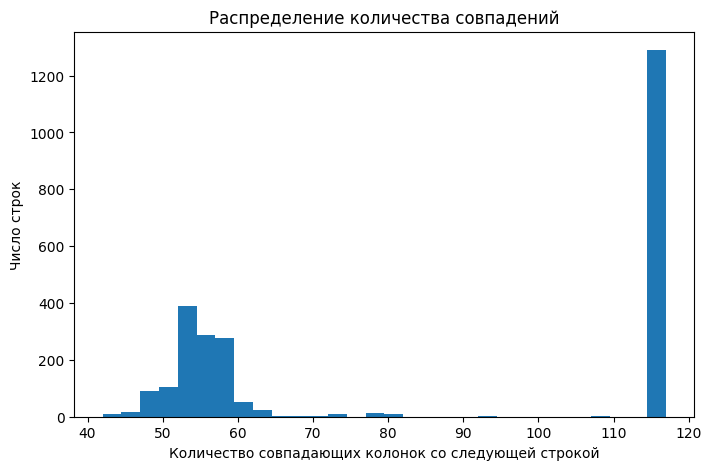

In [28]:
# Проверка на повторяющиеся значения
# Для каждой строки считаем количество совпадающих значений
# со следующей строкой
matches_per_row = df.eq(df.shift(-1)).sum(axis=1)

# Если последняя строка не нужна (у неё нет "следующей")
matches_per_row = matches_per_row.iloc[:-1]

# Гистограмма распределения
plt.figure(figsize=(8, 5))
plt.hist(matches_per_row, bins=30)
plt.xlabel('Количество совпадающих колонок со следующей строкой')
plt.ylabel('Число строк')
plt.title('Распределение количества совпадений')
plt.show()

In [29]:
matches_per_row.value_counts().sort_index()

42        1
43        1
44        6
45       10
46        7
47       20
48       32
49       37
50       45
51       60
52       94
53      136
54      160
55      150
56      136
57      122
58       84
59       70
60       35
61       18
62       10
63        8
64        6
65        1
66        1
67        1
68        2
69        1
70        2
73        3
74        5
77        1
78        6
79        7
80        3
81        6
92        1
108       1
117    1290
Name: count, dtype: int64

In [32]:
df_rowTS['TS'].tail(20)

2560   2021-01-05 14:19:59.999999+00:00
2561   2021-01-05 14:19:59.999999+00:00
2562   2021-01-05 14:20:59.999999+00:00
2563   2021-01-05 14:20:59.999999+00:00
2564   2021-01-05 14:21:59.999999+00:00
2565   2021-01-05 14:21:59.999999+00:00
2566   2021-01-05 14:22:59.999999+00:00
2567   2021-01-05 14:22:59.999999+00:00
2568   2021-01-05 14:23:59.999999+00:00
2569   2021-01-05 14:23:59.999999+00:00
2570          2021-01-05 14:25:00+00:00
2571          2021-01-05 14:25:00+00:00
2572   2021-01-05 14:25:59.999999+00:00
2573   2021-01-05 14:25:59.999999+00:00
2574   2021-01-05 14:26:59.999999+00:00
2575   2021-01-05 14:26:59.999999+00:00
2576          2021-01-05 14:28:00+00:00
2577          2021-01-05 14:28:00+00:00
2578          2021-01-05 14:28:01+00:00
2579          2021-01-05 14:28:01+00:00
Name: TS, dtype: datetime64[us, UTC]

In [36]:
ts = pd.to_datetime(df_rowTS['TS']).dt.round('min')

pair_start = np.arange(0, len(ts) - 1, 2)

# одинаковые времена внутри пары
same_pair = (
    ts.iloc[pair_start].to_numpy()
    == ts.iloc[pair_start + 1].to_numpy()
)

pair_times = ts.iloc[pair_start].reset_index(drop=True)

# шаг между парами ровно 1 минута
correct_step = (
    pair_times.diff().iloc[1:]
    == pd.Timedelta(minutes=1)
)

bad_rows = set()
pair_diff = set()
pair_step = set()

# разные значения внутри пары
for i in pair_start[~same_pair]:
    pair_diff.update([i, i + 1])
    bad_rows.update([i, i + 1])

# неправильный шаг между парами
for i in pair_start[1:][~correct_step]:
    pair_step.update([i - 2, i - 1, i, i + 1])
    bad_rows.update([i - 2, i - 1, i, i + 1])

bad_rows = sorted(bad_rows)
pair_diff = sorted(pair_diff)
pair_step = sorted(pair_step)

df.iloc[bad_rows]

,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,Lab5_G1_T638,Lab5_G1_T606,...,Lab5_AVOM_AVOMN1,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_6,Lab5_U_Kran_GPA_A_APK,Lab5_Kran_1,Lab5_Kran_4,Lab5_q
2576,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0
2577,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0
2578,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0
2579,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0


In [37]:
df.iloc[pair_diff]

,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,Lab5_G1_T638,Lab5_G1_T606,...,Lab5_AVOM_AVOMN1,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_6,Lab5_U_Kran_GPA_A_APK,Lab5_Kran_1,Lab5_Kran_4,Lab5_q


In [38]:
df.iloc[pair_step]

,Lab5_G1_N1,Lab5_G1_N2,Lab5_G1_N3,Lab5_G1_P2,Lab5_G1_T4ср,Lab5_G1_T1,Lab5_G1_T607,Lab5_G1_T600,Lab5_G1_T638,Lab5_G1_T606,...,Lab5_AVOM_AVOMN1,Lab5_Kp,Lab5_hGPA,Lab5_Kran_5,Lab5_Kran_2,Lab5_Kran_6,Lab5_U_Kran_GPA_A_APK,Lab5_Kran_1,Lab5_Kran_4,Lab5_q
2576,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0
2577,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0
2578,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0
2579,0,0,0,0.13,310.9,-0.9,40.5,79.64,69.1,86.94,...,1,0.0,0.0,1,0,0,0,0,0,0.0


In [41]:
diff_count = (df.loc[2578] != df.loc[2579]).sum()
print(diff_count)

0


In [42]:
is_ok = df.iloc[1::2].reset_index(drop=True).equals(
    df.iloc[0::2].reset_index(drop=True)
)

print(is_ok)

True


In [79]:
x = df["Lab5_G1_T1"].to_numpy(dtype=np.float64)
eps = 1e-2 * np.std(x)
x_jitter = x + eps * np.random.randn(len(x))
len(np.unique(df["Lab5_G1_T1"].to_numpy(dtype=np.float64)))

30

In [89]:
x_delta = np.min(np.diff(np.unique(x)))

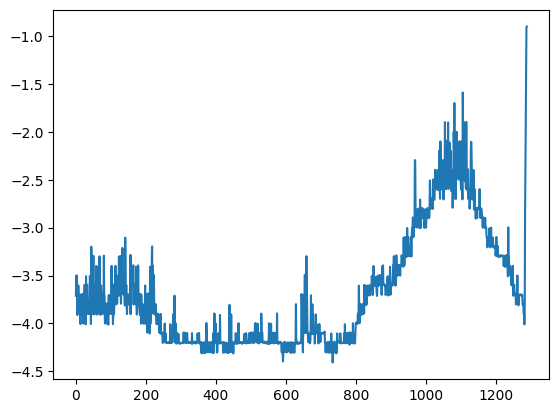

In [70]:
plt.plot(np.arange(len(x_jitter)), x_jitter)

In [66]:
np.max(x) - np.min(x)

3.5000000000000004

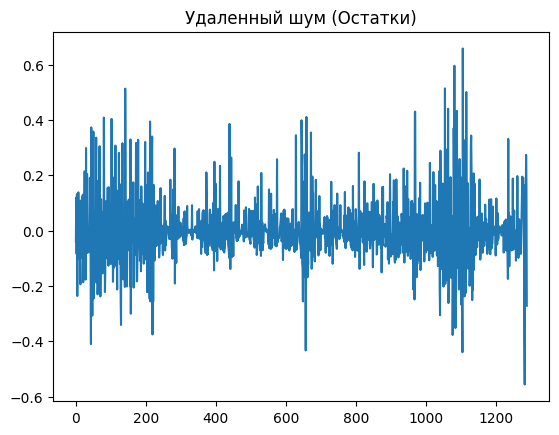

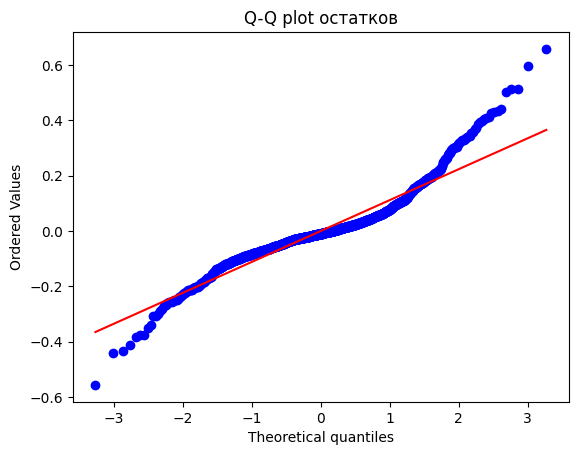

In [83]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Подбираем параметры
smooth_ts = savgol_filter(x_jitter, window_length=35, polyorder=6)
noise = x_jitter - smooth_ts

# Строим график остатков
plt.plot(noise)
plt.title("Удаленный шум (Остатки)")
plt.show()

from scipy.stats import probplot
probplot(noise, dist="norm", plot=plt)
plt.title("Q-Q plot остатков")
plt.show()

In [90]:
from juliacall import convert as jlconvert

# jl.x = jlconvert(jl.Vector, smooth_ts)
uni_smooth = x + np.random.uniform(-x_delta / 2, x_delta / 2, len(x))
jl.x = jlconvert(jl.Vector, smooth_ts)
w_estimated = jl.estimate_delay(x_jitter, "mi_min")
jl.w_est = w_estimated

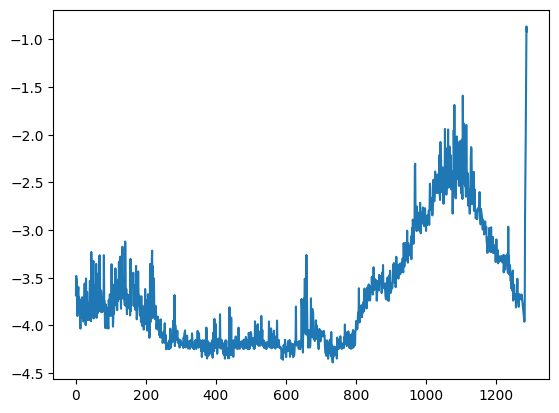

In [92]:
plt.plot(np.arange(len(uni_smooth)), uni_smooth)

In [91]:
result = jl.seval("""
Y, τ_vals, ts_vals, Ls, eps = pecuzal_embedding(
    x;
    τs = 0:150,
    w = w_est,
    econ = false,
    verbose = true,
    samplesize=1.0
)

(
    Y,
    τ_vals,
    ts_vals,
    Ls
)
""")

Initializing PECUZAL algorithm for univariate input...
Starting 1-th embedding cycle...
Starting 2-th embedding cycle...
Starting 3-th embedding cycle...
Starting 4-th embedding cycle...
Starting 5-th embedding cycle...
Starting 6-th embedding cycle...
Starting 7-th embedding cycle...
Algorithm stopped due to increasing L-values. VALID embedding achieved ✓.
